### 임포트 하기

In [2]:
import pandas as pd
import re

### 데이터 가져오기

In [3]:
# 1. CSV 파일 불러오기 (경로: ./output/multiagent-rag.csv)
file_path = "./multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
df = pd.read_excel(file_path)

### ratio


--- Li ratio 분포 확인 (숫자 데이터만) ---
Li ratio
0.000      5
0.950      1
0.970      2
0.980      5
0.985      1
0.990      2
1.000    391
1.010      2
1.020     12
1.030     21
1.040      3
1.050     16
1.060      3
1.080      1
1.140      9
1.150      7
1.200     11
1.250      1
1.330      8
1.400      2
Name: count, dtype: int64
총 20종류의 유효한 숫자 데이터가 존재합니다.

--- Ni ratio 분포 확인 (숫자 데이터만) ---
Ni ratio
0.0000     8
0.1300     8
0.1500     8
0.2000     2
0.2236     8
0.2500     1
0.2680     8
0.3300    87
0.3400     1
0.4000    17
0.4100     1
0.5000    55
0.5500     1
0.5700     1
0.6000    91
0.6100     1
0.6500     3
0.6700     1
0.7000    10
0.7200     1
0.7280     1
0.7300     3
0.7600     9
0.7800     5
0.8000    84
0.8040     2
0.8080     1
0.8100     2
0.8300    28
0.8400     4
0.8500    16
0.8780     1
0.8800     9
0.8810     1
0.8845     1
0.8880     1
0.9000    11
0.9100     6
0.9200     2
0.9400     1
0.9600     2
Name: count, dtype: int64
총 41종류의 유효한 숫자 데이터가 존재합니다.

--- Co ratio 분

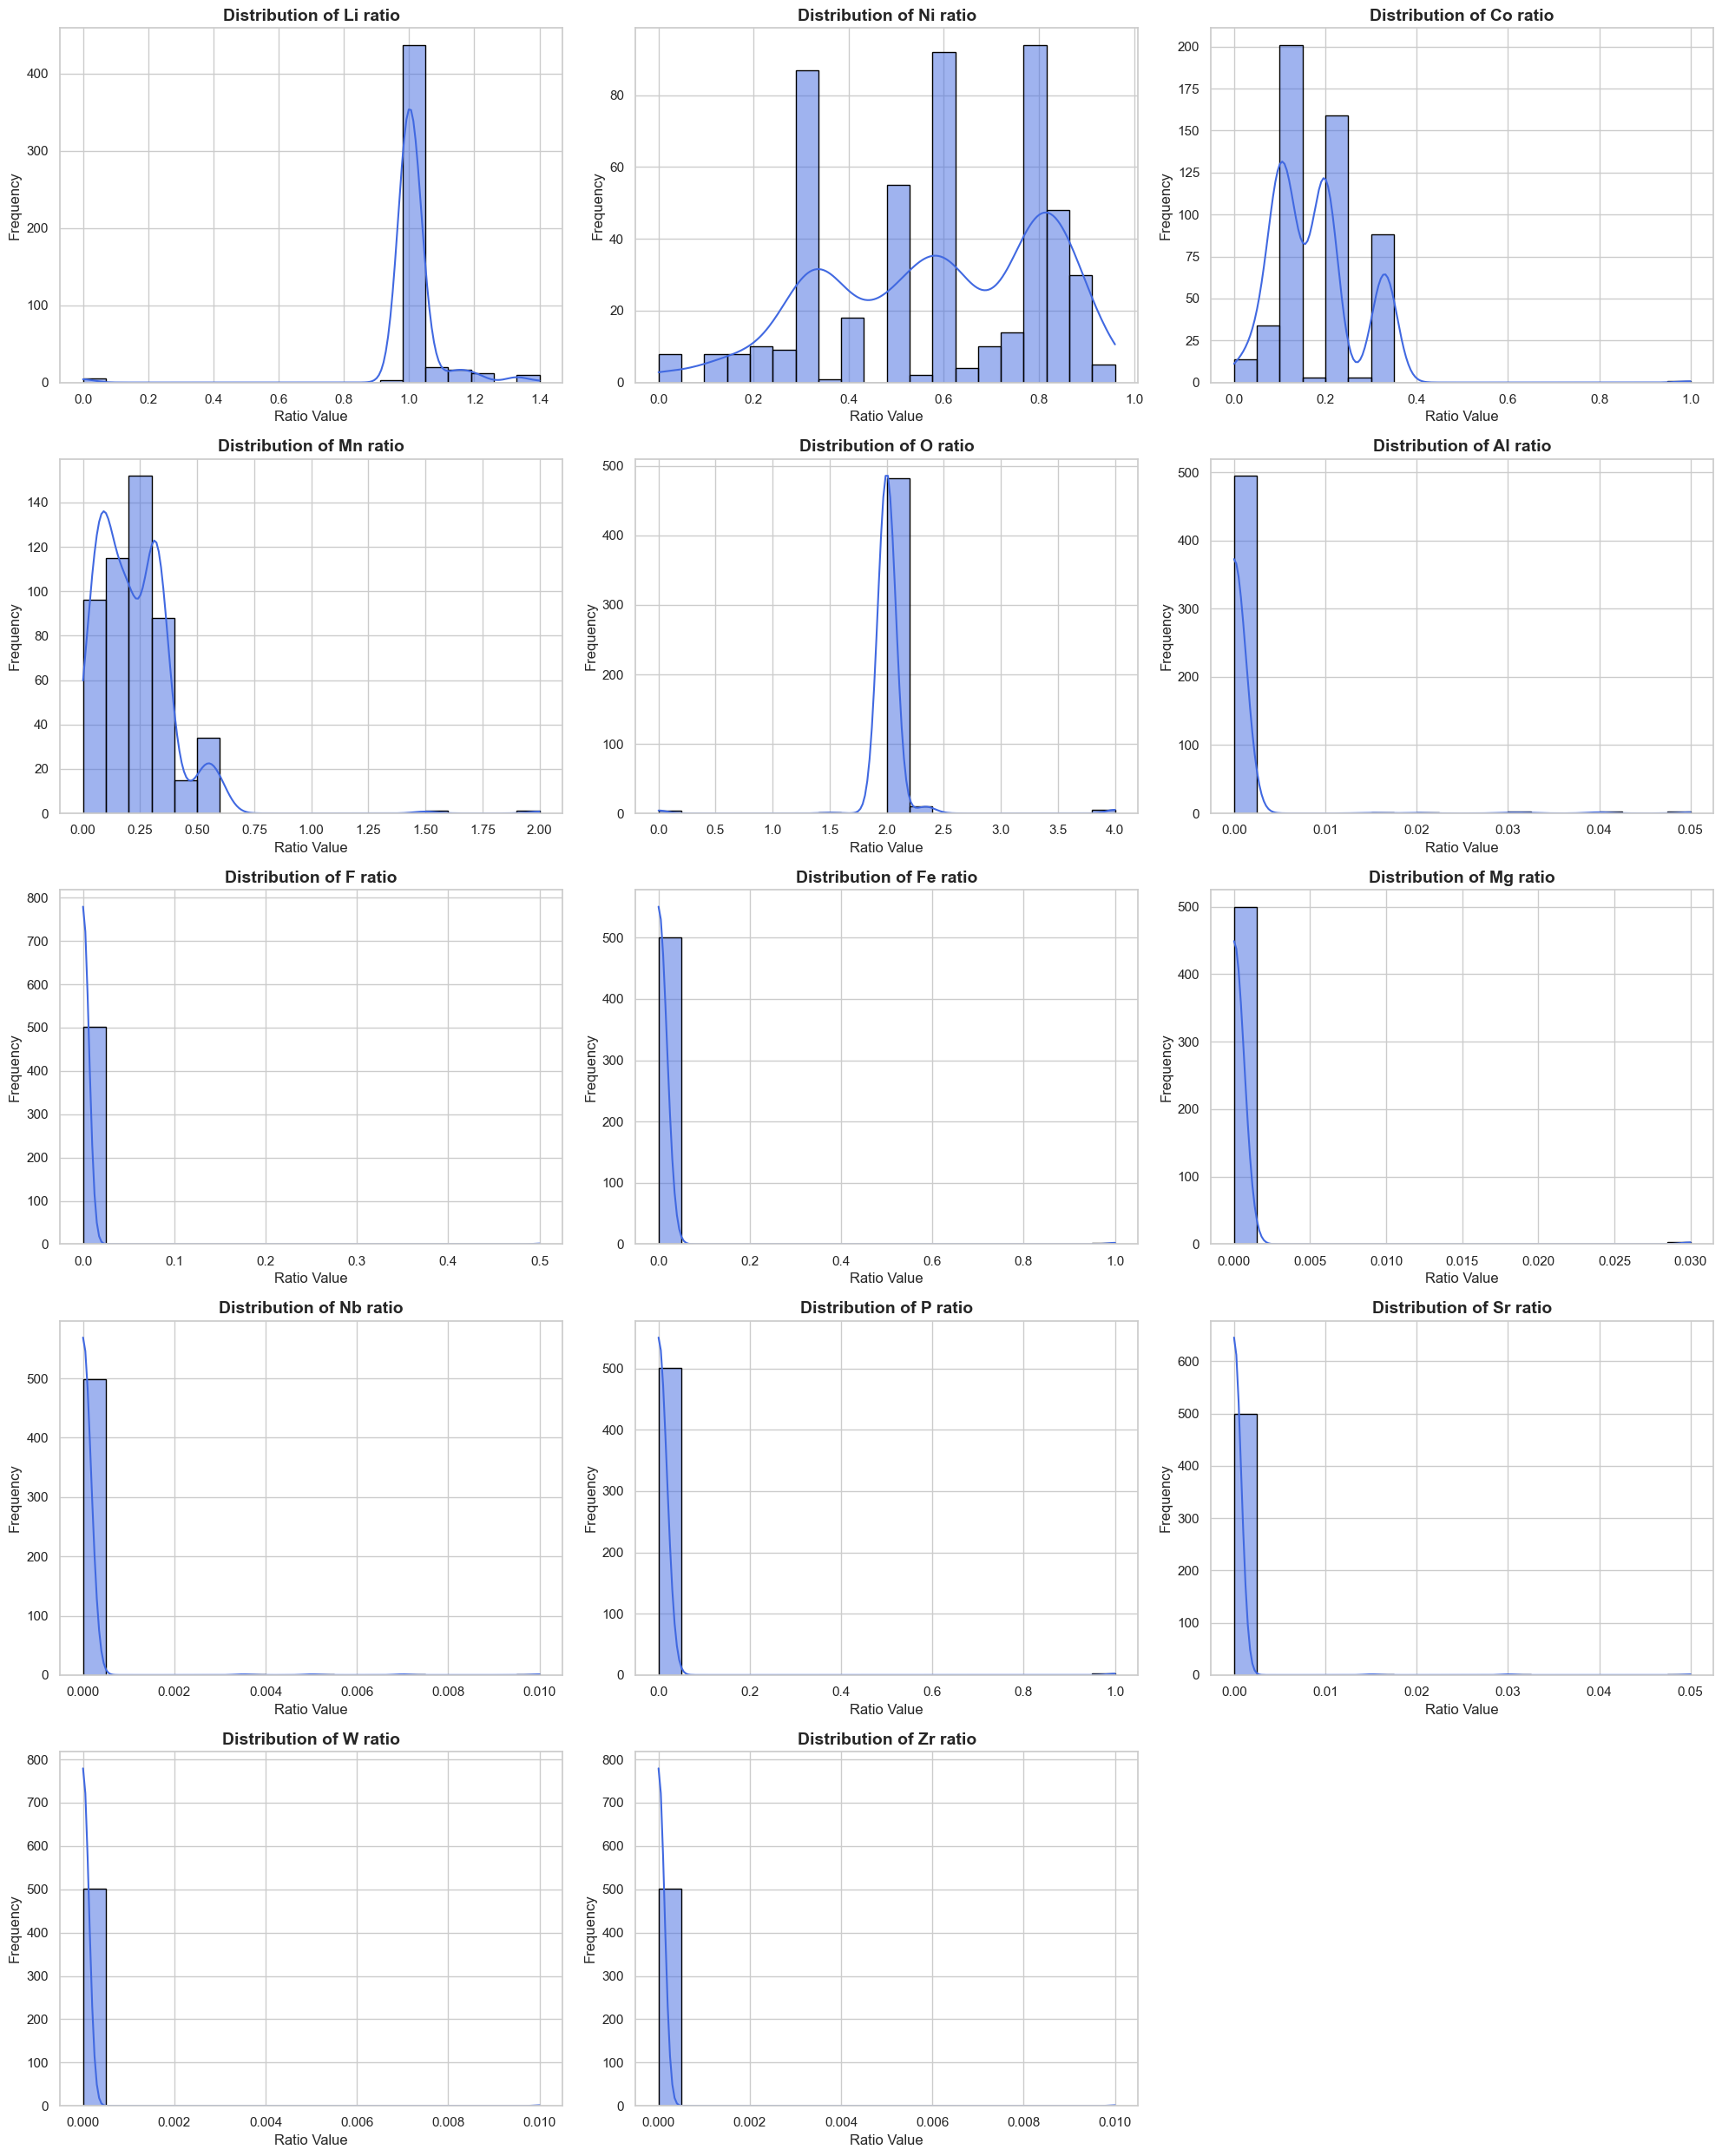

In [4]:
# 2. 확인할 컬럼 리스트
ratio_cols = ['Li ratio', 'Ni ratio', 'Co ratio', 'Mn ratio', 'O ratio', 'Al ratio', 'F ratio', 'Fe ratio', 'Mg ratio', 'Nb ratio', 'P ratio', 'Sr ratio', 'W ratio', 'Zr ratio' ]
    
# 2. 확인할 컬럼 리스트 (총 14개)
ratio_cols = [
    'Li ratio', 'Ni ratio', 'Co ratio', 'Mn ratio', 'O ratio', 
    'Al ratio', 'F ratio', 'Fe ratio', 'Mg ratio', 'Nb ratio', 
    'P ratio', 'Sr ratio', 'W ratio', 'Zr ratio'
]

# --- [수정] 텍스트 출력 부분 ---
for col in ratio_cols:
    if col in df.columns:
        print(f"\n--- {col} 분포 확인 (숫자 데이터만) ---")
        numeric_col = pd.to_numeric(df[col], errors='coerce')
        counts = numeric_col.dropna().value_counts().sort_index()
        print(counts)
        print(f"총 {len(counts)}종류의 유효한 숫자 데이터가 존재합니다.")

# --- [수정] 그래프 설정 부분 ---
# 14개의 그래프를 그리기 위해 5행 3열(최대 15칸) 구조로 변경
rows = 5
cols = 3

plt.figure(figsize=(20, 25)) # 전체 그래프 크기 키움
sns.set_theme(style="whitegrid")

for i, col in enumerate(ratio_cols, 1):
    if col in df.columns:
        plt.subplot(rows, cols, i)
        
        # 숫자 데이터로 변환 (문자열 제외)
        data = pd.to_numeric(df[col], errors='coerce').dropna()
        
        # 히스토그램 + KDE (값이 1종류뿐이면 KDE는 자동으로 꺼짐)
        sns.histplot(data, kde=True, bins=20, color='royalblue', edgecolor='black')
        
        plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        plt.xlabel('Ratio Value')
        plt.ylabel('Frequency')

# 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

### Commercial NCM used

--- Commercial NCM used 분포 확인 ---
Commercial NCM used
no     292
yes    176
NaN     36
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\870502787.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


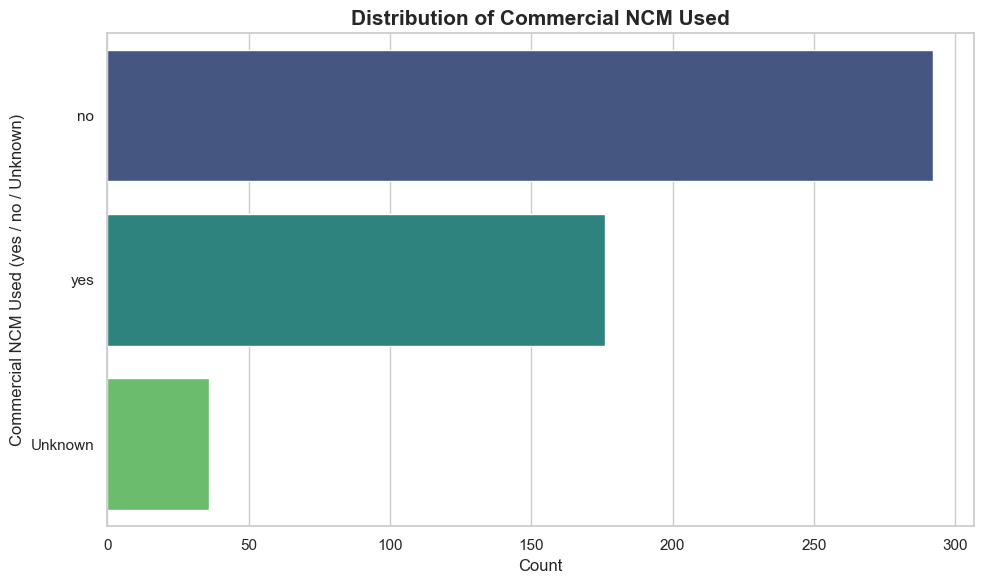

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 확인 (dropna=False를 사용하여 NaN까지 포함)
ncm_distribution = df['Commercial NCM used'].value_counts(dropna=False)

print("--- Commercial NCM used 분포 확인 ---")
print(ncm_distribution)

# ==========================================
# 2. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# NaN은 'Unknown'으로 표시하여 시각화 (기존 데이터에 맞게 임시 변환)
plot_data = df['Commercial NCM used'].fillna('Unknown')

# 가로 막대(y=), 빈도순 정렬(order=), viridis 팔레트 적용
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Commercial NCM Used', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Commercial NCM Used (yes / no / Unknown)')

plt.tight_layout()
plt.show()

### Lithium source

--- Lithium source 분포 확인 ---
Lithium source
NaN                223
LiOH               154
Li2CO3              55
LiNO3               41
CH3COOLi             9
LiOMe                6
Li(CH3COO)2          5
Li(CH3COO)           4
Lithium acetate      3
LiAc                 2
Li2CO3, LiF          1
LiCH3COO             1
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1853597760.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Lithium source'].fillna('NaN'),


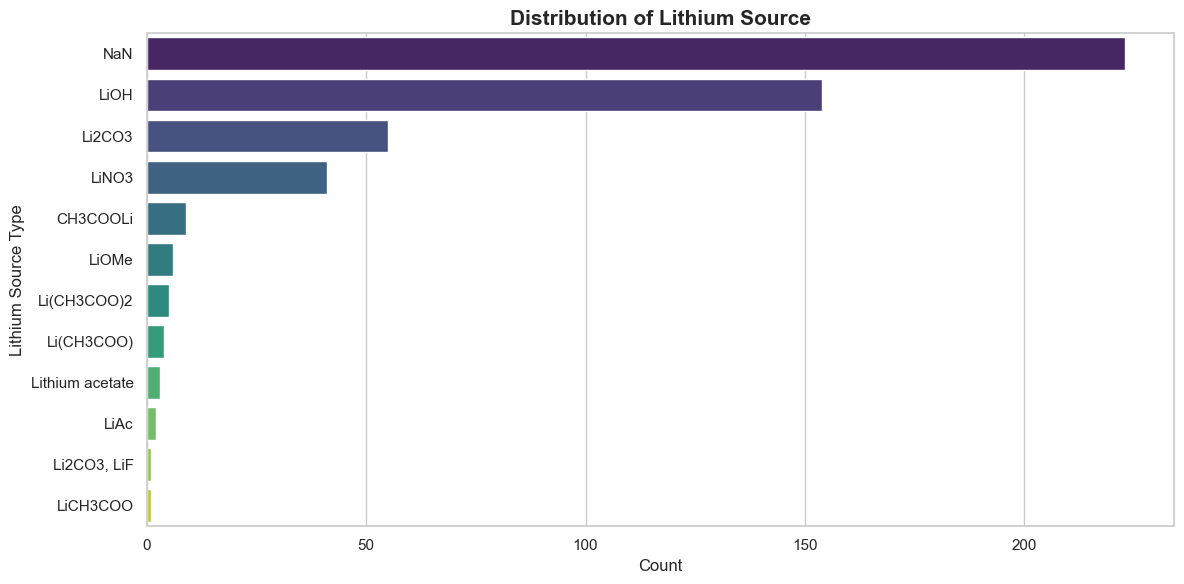

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 확인 (결측치 포함)
li_source_dist = df['Lithium source'].value_counts(dropna=False)

print("--- Lithium source 분포 확인 ---")
print(li_source_dist)

# 2. 시각화
plt.figure(figsize=(12, 6)) # 텍스트가 길 수 있으므로 가로 길이를 조금 늘림
sns.set_theme(style="whitegrid")

# NaN은 'Unknown' 또는 'NaN'으로 표시하여 시각화
sns.countplot(y=df['Lithium source'].fillna('NaN'), 
              order=df['Lithium source'].fillna('NaN').value_counts().index,
              palette='viridis')

plt.title('Distribution of Lithium Source', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Lithium Source Type')

plt.tight_layout()
plt.show()

--- 전처리 후 Lithium source 고유값 분포 ---
Lithium source
NaN        223
LiOH       154
Li2CO3      56
LiNO3       41
Acetate     24
LiOMe        6
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\3872570682.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Lithium source'].fillna('NaN'),


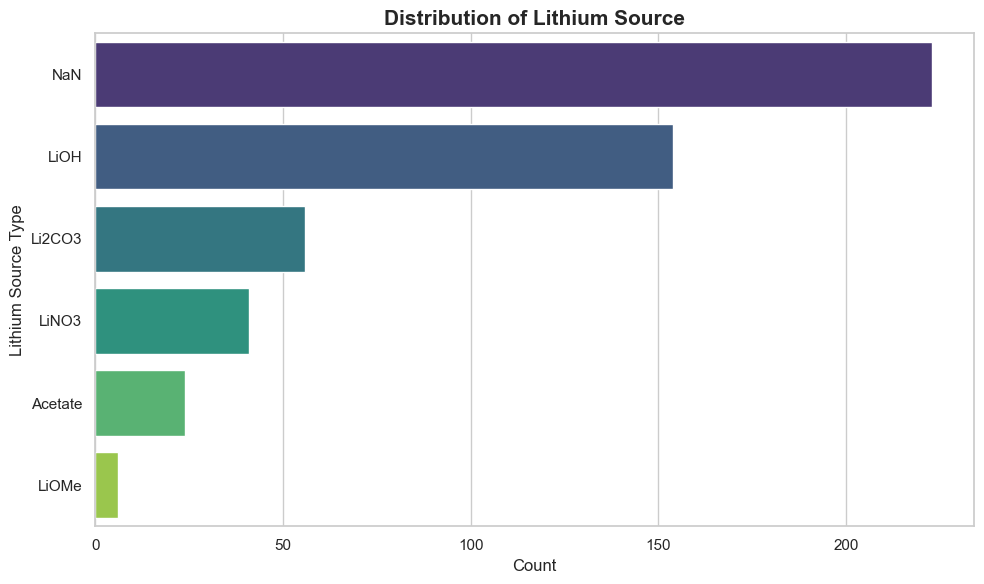

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lithium source 카테고리 매핑 정의
lithium_mapping = {
    # 1. Hydroxide 계열
    'LiOH': 'LiOH',
    
    # 2. Carbonate 계열
    'Li2CO3': 'Li2CO3',
    'Li2CO3, LiF': 'Li2CO3',
    
    # 3. Nitrate 계열
    'LiNO3': 'LiNO3',
    
    # 4. Acetate 계열
    'CH3COOLi': 'Acetate',
    'Li(CH3COO)2': 'Acetate', 
    'Li(CH3COO)': 'Acetate',
    'Lithium acetate': 'Acetate',
    'LiAc': 'Acetate',
    'LiCH3COO': 'Acetate',
    
    # 5. Methoxide 계열
    'LiOMe': 'LiOMe'
}

# 모든 열이 다 보이도록 설정 변경
pd.set_option('display.max_columns', None)

# 2. 매핑 적용 
df['Lithium source'] = df['Lithium source'].replace(lithium_mapping)

# [확인용] 결과 출력 (빈칸 포함 개수 확인)
print("--- 전처리 후 Lithium source 고유값 분포 ---")
print(df['Lithium source'].value_counts(dropna=False))

# ==========================================
# 3. 시각화 (요청하신 디자인 양식 완벽 적용)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# NaN은 'Unknown' 또는 'NaN'으로 표시하여 시각화
sns.countplot(y=df['Lithium source'].fillna('NaN'), 
              order=df['Lithium source'].fillna('NaN').value_counts().index,
              palette='viridis')

plt.title('Distribution of Lithium Source', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Lithium Source Type')

plt.tight_layout()
plt.show()

### Synthesis method

--- Synthesis method 분포 확인 ---
Synthesis method
NaN                                         192
co-precipitation                             95
sol-gel                                      55
coprecipitation                              38
solid-state reaction                         18
solid-state                                  18
solution combustion                          13
hydrothermal                                  8
inverse microemulsion                         6
polyol method                                 5
solid state reaction                          5
ball milling                                  4
solid-state method                            4
precipitation                                 4
template method                               3
hydrolysis-hydrothermal                       3
high temperature solid phase sintering        3
two-step method                               3
wet chemical coating                          3
chemical vaporization-assisted synthesis

C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1614631697.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


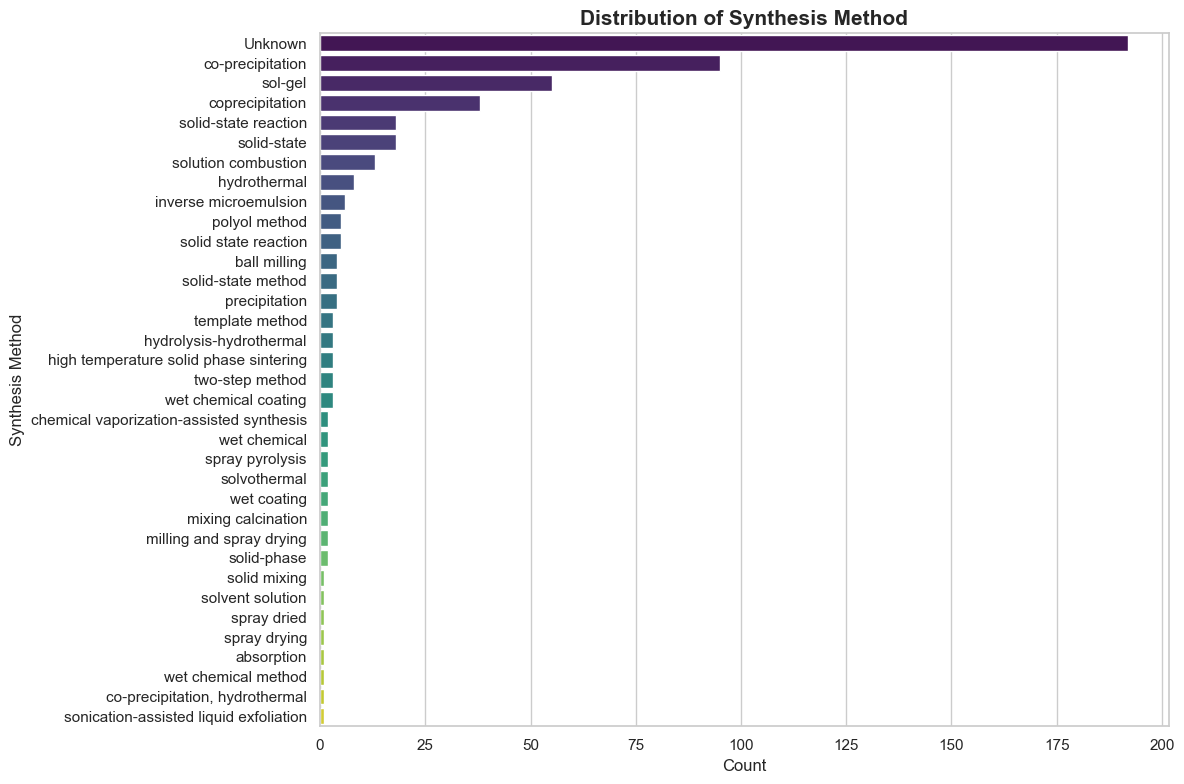

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 확인 (결측치 포함)
synthesis_dist = df['Synthesis method'].value_counts(dropna=False)

print("--- Synthesis method 분포 확인 ---")
print(synthesis_dist)

# 2. 시각화 (요청하신 완벽한 디자인 양식 적용)
plt.figure(figsize=(12, 8)) # 텍스트가 길 수 있어 세로 길이를 살짝 늘렸습니다
sns.set_theme(style="whitegrid")

# NaN은 'Unknown'으로 표시하여 시각화
plot_data = df['Synthesis method'].fillna('Unknown')

sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Synthesis Method', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Synthesis Method')

plt.tight_layout()
plt.show()

--- 전처리 후 Synthesis method 고유값 분포 ---
Synthesis method
NaN                   192
Co-precipitation      138
Sol-Gel                55
Solid-State            53
Wet-Chemical           21
Combustion / Spray     19
Others                 13
Hydro/Solvothermal     13
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\2761194672.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


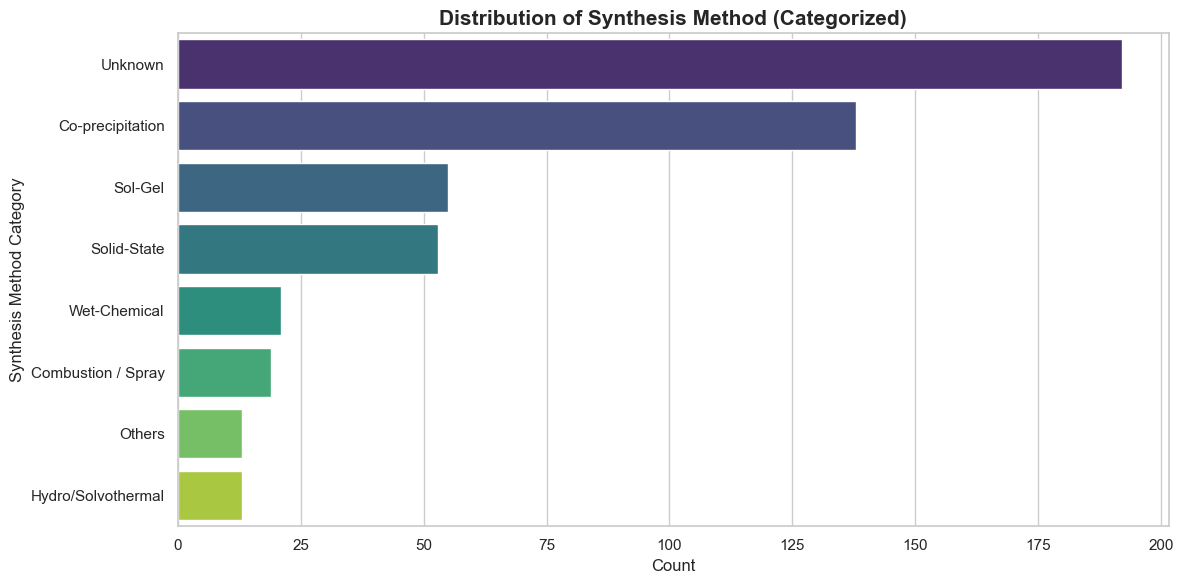

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Synthesis method 카테고리 매핑 정의
synthesis_mapping = {
    # 1. Co-precipitation (공침법)
    'co-precipitation': 'Co-precipitation',
    'coprecipitation': 'Co-precipitation',
    'precipitation': 'Co-precipitation',
    'co-precipitation, hydrothermal': 'Co-precipitation', # 주 공정 기준
    
    # 2. Sol-Gel (졸겔법)
    'sol-gel': 'Sol-Gel',
    
    # 3. Solid-State (고상법)
    'solid-state reaction': 'Solid-State',
    'solid-state': 'Solid-State',
    'solid state reaction': 'Solid-State',
    'solid-state method': 'Solid-State',
    'high temperature solid phase sintering': 'Solid-State',
    'solid-phase': 'Solid-State',
    'solid mixing': 'Solid-State',
    'mixing calcination': 'Solid-State',
    
    # 4. Hydro/Solvothermal (수열/용매열 합성법)
    'hydrothermal': 'Hydro/Solvothermal',
    'hydrolysis-hydrothermal': 'Hydro/Solvothermal',
    'solvothermal': 'Hydro/Solvothermal',
    
    # 5. Combustion / Spray (연소 및 분무법)
    'solution combustion': 'Combustion / Spray',
    'spray pyrolysis': 'Combustion / Spray',
    'spray drying': 'Combustion / Spray',
    'spray dried': 'Combustion / Spray',
    'milling and spray drying': 'Combustion / Spray',
    
    # 6. Wet-Chemical / Solution (습식/용액법)
    'inverse microemulsion': 'Wet-Chemical',
    'polyol method': 'Wet-Chemical',
    'wet chemical coating': 'Wet-Chemical',
    'wet chemical': 'Wet-Chemical',
    'wet chemical method': 'Wet-Chemical',
    'wet coating': 'Wet-Chemical',
    'solvent solution': 'Wet-Chemical',
    'absorption': 'Wet-Chemical',
    
    # 7. Others (기타)
    'ball milling': 'Others',
    'template method': 'Others',
    'two-step method': 'Others',
    'chemical vaporization-assisted synthesis': 'Others',
    'sonication-assisted liquid exfoliation': 'Others'
}

# 2. 매핑 적용
df['Synthesis method'] = df['Synthesis method'].replace(synthesis_mapping)

# [확인용] 결과 출력
print("--- 전처리 후 Synthesis method 고유값 분포 ---")
print(df['Synthesis method'].value_counts(dropna=False))

# ==========================================
# 3. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# NaN은 'Unknown'으로 표시하여 시각화
plot_data = df['Synthesis method'].fillna('Unknown')

# 개수가 많은 순서대로 가로 막대 그래프 그리기
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Synthesis Method (Categorized)', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Synthesis Method Category')

plt.tight_layout()
plt.show()

### Crystallization method

--- Crystallization method 분포 확인 ---
Crystallization method
calcination                   196
NaN                           191
sintering                      43
heating                        17
annealing                      13
autoclave                      12
heat treatment                  7
high-temperature sintering      7
solvothermal                    4
vacuum drying                   4
thermal gas treatment           3
sintered                        2
calcinated                      1
reductive reaction              1
solid-phase sintering           1
sol-gel                         1
solvothermal synthesis          1
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\181347853.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


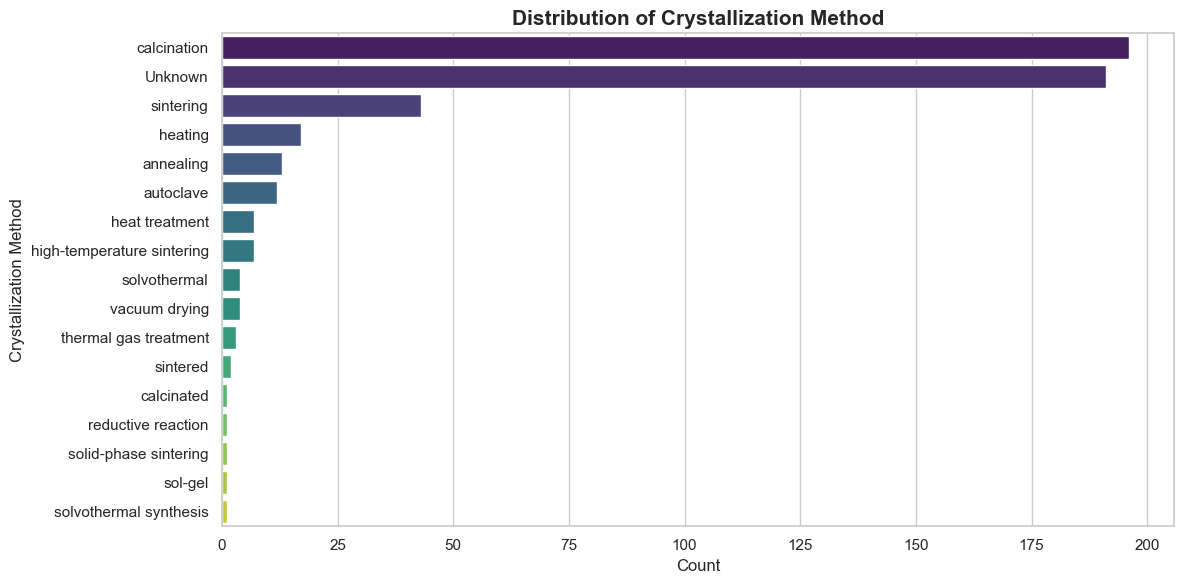

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 확인 (결측치 포함)
crystallization_dist = df['Crystallization method'].value_counts(dropna=False)

print("--- Crystallization method 분포 확인 ---")
print(crystallization_dist)

# 2. 시각화 (요청하신 완벽한 디자인 양식 적용)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# NaN은 'Unknown'으로 표시하여 시각화
plot_data = df['Crystallization method'].fillna('Unknown')

# 개수가 많은 순서대로 가로 막대 그래프 그리기
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Crystallization Method', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Crystallization Method')

plt.tight_layout()
plt.show()

--- 전처리 후 Crystallization method 고유값 분포 ---
Crystallization method
Calcination                 197
NaN                         191
Sintering                    53
Heating / Heat Treatment     27
Autoclave / Solvothermal     17
Annealing                    13
Others                        6
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1754999712.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


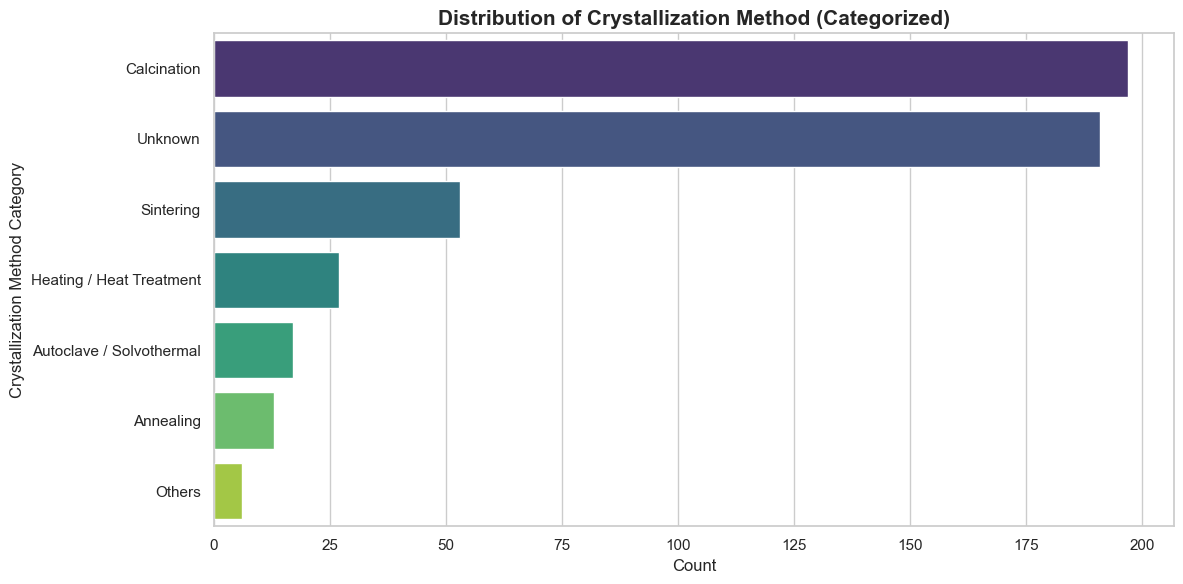

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Crystallization method 카테고리 매핑 정의
crystallization_mapping = {
    # 1. Calcination (하소)
    'calcination': 'Calcination',
    'calcinated': 'Calcination',
    
    # 2. Sintering (소결)
    'sintering': 'Sintering',
    'sintered': 'Sintering',
    'high-temperature sintering': 'Sintering',
    'solid-phase sintering': 'Sintering',
    
    # 3. Heating / Heat Treatment (일반 열처리)
    'heating': 'Heating / Heat Treatment',
    'heat treatment': 'Heating / Heat Treatment',
    'thermal gas treatment': 'Heating / Heat Treatment',
    
    # 4. Annealing (어닐링)
    'annealing': 'Annealing',
    
    # 5. Autoclave / Solvothermal (가압/용매열 반응)
    'autoclave': 'Autoclave / Solvothermal',
    'solvothermal': 'Autoclave / Solvothermal',
    'solvothermal synthesis': 'Autoclave / Solvothermal',
    
    # 6. Others (건조 및 기타)
    'vacuum drying': 'Others',
    'reductive reaction': 'Others',
    'sol-gel': 'Others'
}

# 2. 매핑 적용
df['Crystallization method'] = df['Crystallization method'].replace(crystallization_mapping)

# [확인용] 결과 출력
print("--- 전처리 후 Crystallization method 고유값 분포 ---")
print(df['Crystallization method'].value_counts(dropna=False))

# ==========================================
# 3. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# NaN은 'Unknown'으로 표시하여 시각화
plot_data = df['Crystallization method'].fillna('Unknown')

# 개수가 많은 순서대로 가로 막대 그래프 그리기
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Crystallization Method (Categorized)', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Crystallization Method Category')

plt.tight_layout()
plt.show()

#### calcination, sintering, heating 모두 통일

--- [최종] 통합 전처리 후 고유값 분포 ---
Crystallization method_Grouped
Thermal Treatment           277
Unknown                     191
Autoclave / Solvothermal     17
Annealing                    13
Others                        6
Name: count, dtype: int64


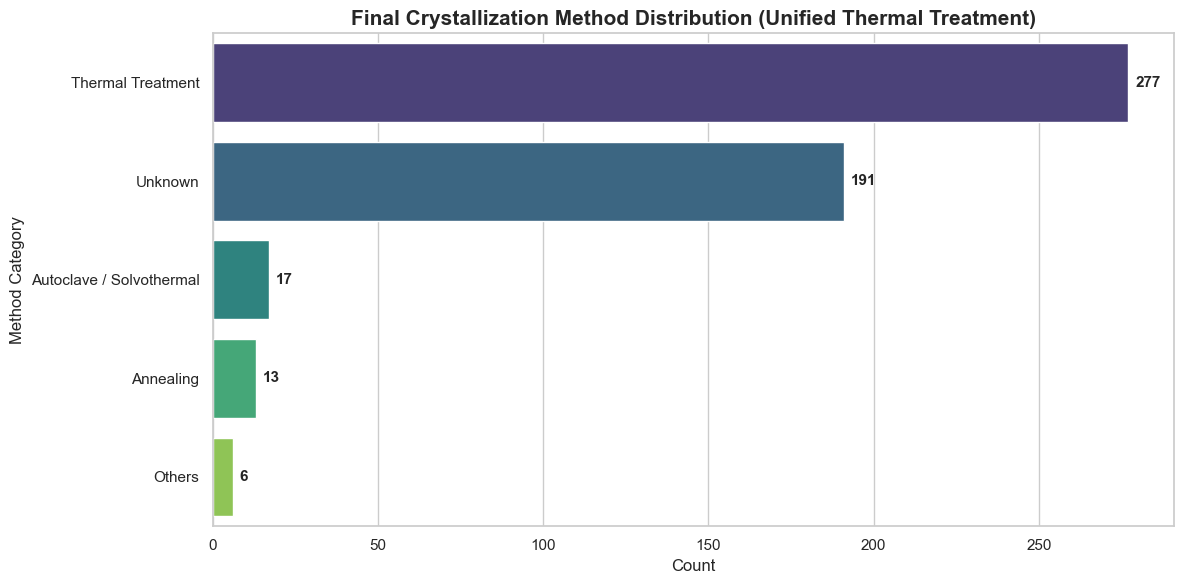

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 대소문자 무시하고 통합하는 강력한 매핑
# ==========================================
# 모든 키값을 소문자로 통일해서 다시 정의합니다.
thermal_list = ['calcination', 'calcinated', 'sintering', 'sintered', 
                'high-temperature sintering', 'solid-phase sintering', 
                'heating', 'heat treatment', 'thermal gas treatment']

def aggregate_methods(val):
    if pd.isna(val):
        return 'Unknown'
    
    # 소문자로 변환해서 비교 (대소문자 문제 해결!)
    v = str(val).lower().strip()
    
    # 1. Thermal Treatment로 통합
    if any(target in v for target in thermal_list):
        return 'Thermal Treatment'
    
    # 2. Annealing
    if 'annealing' in v:
        return 'Annealing'
    
    # 3. Autoclave / Solvothermal
    if 'autoclave' in v or 'solvothermal' in v:
        return 'Autoclave / Solvothermal'
    
    # 4. Others
    return 'Others'

# 함수 적용
df['Crystallization method_Grouped'] = df['Crystallization method'].apply(aggregate_methods)

# [확인용] 결과 출력 - 이제 Thermal Treatment가 압도적으로 커질 거예요!
print("--- [최종] 통합 전처리 후 고유값 분포 ---")
print(df['Crystallization method_Grouped'].value_counts())

# ==========================================
# 2. 시각화 (업그레이드 버전)
# ==========================================
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

plot_data = df['Crystallization method_Grouped']

ax = sns.countplot(y=plot_data, 
                   hue=plot_data,
                   legend=False,
                   order=plot_data.value_counts().index, 
                   palette='viridis')

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=11, fontweight='bold')

plt.title('Final Crystallization Method Distribution (Unified Thermal Treatment)', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Method Category', fontsize=12)

plt.tight_layout()
plt.show()

### Doping

--- Doping 분포 확인 ---
Doping
NaN            437
Al              16
yes             10
Ti               6
Zr, Y            5
Zr               4
Zr4+             4
Nb               4
V                3
Sr2+             3
Mg               2
F                2
Mg2+             2
W6+              1
Nb5+             1
Ti3+             1
unspecified      1
Mg, Zr           1
Al, Nb           1
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\3931034306.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


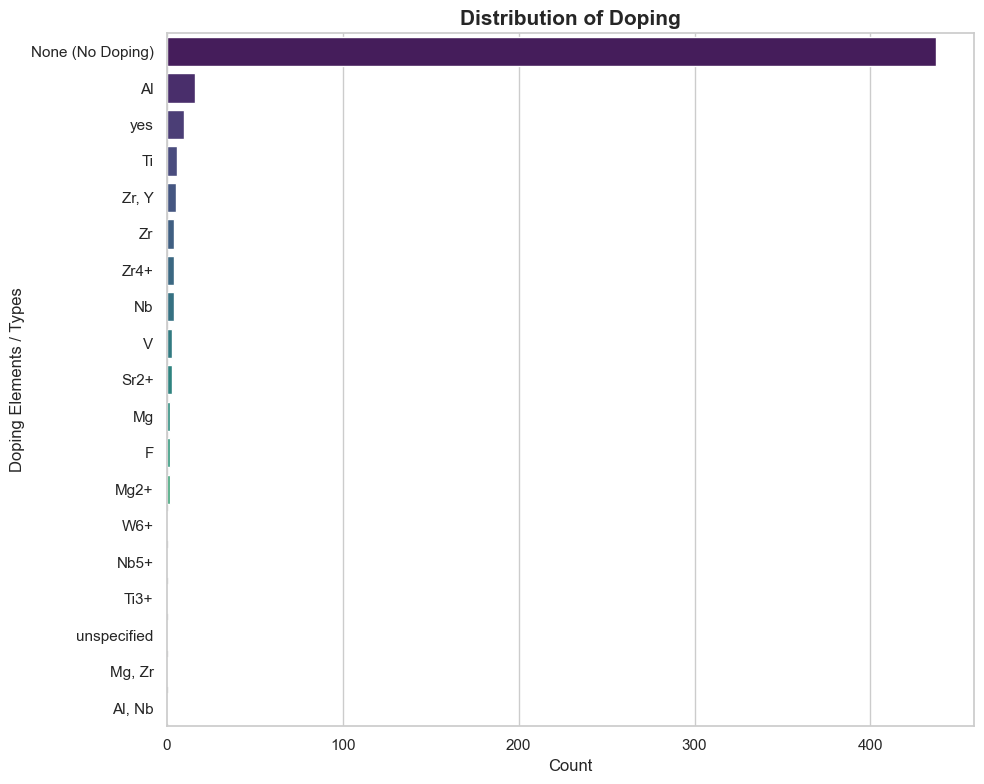

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 확인 (dropna=False를 사용하여 NaN까지 포함)
doping_dist = df['Doping'].value_counts(dropna=False)

print("--- Doping 분포 확인 ---")
print(doping_dist)

# ==========================================
# 2. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
# 도핑 종류가 많을 수 있으므로 세로 길이를 넉넉하게(8) 설정했습니다.
plt.figure(figsize=(10, 8)) 
sns.set_theme(style="whitegrid")

# Doping 열에서 NaN은 도핑을 하지 않았다는 의미이므로 'None (No Doping)'으로 직관적으로 표시
plot_data = df['Doping'].fillna('None (No Doping)')

# 가로 막대(y=), 빈도순 정렬(order=), viridis 팔레트 적용
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Doping', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Doping Elements / Types')

plt.tight_layout()
plt.show()

--- 전처리 후 Doping 고유값 분포 ---
Doping
NaN            437
Others          18
Al              16
Unspecified     11
Zr               8
Ti               7
Multiple         7
Name: count, dtype: int64


C:\Users\LECS\AppData\Local\Temp\ipykernel_2060\3701603718.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=plot_data,


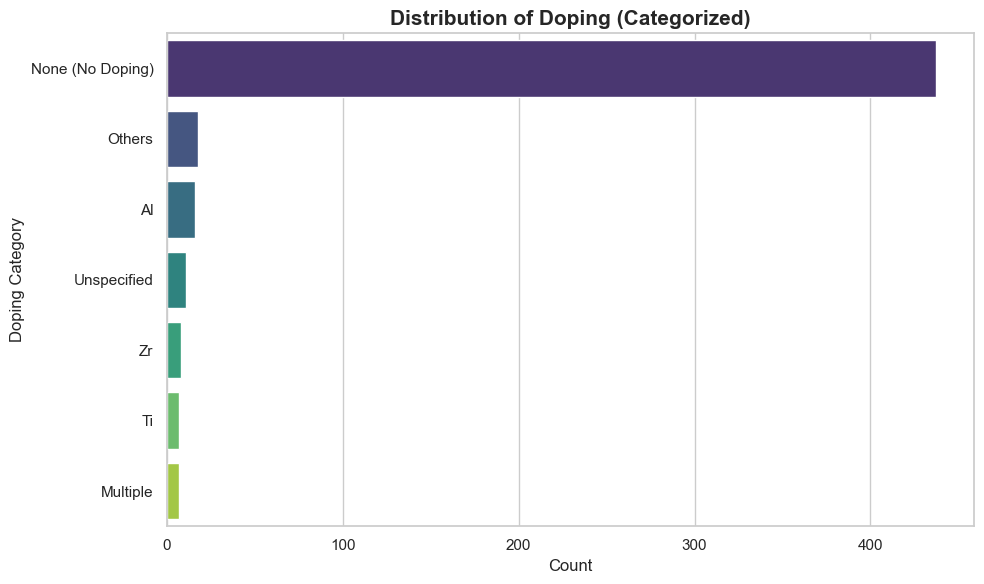

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Doping 카테고리 매핑 정의
doping_mapping = {
    # 1. Al
    'Al': 'Al',
    
    # 2. Zr (전하량 표시 포함)
    'Zr': 'Zr',
    'Zr4+': 'Zr',
    
    # 3. Ti (전하량 표시 포함)
    'Ti': 'Ti',
    'Ti3+': 'Ti',
    
    # 4. Multiple (다중 도핑)
    'Zr, Y': 'Multiple',
    'Mg, Zr': 'Multiple',
    'Al, Nb': 'Multiple',
    
    # 5. Unspecified (종류 미상)
    'yes': 'Unspecified',
    'unspecified': 'Unspecified',
    
    # 6. Others (기타 단일 도핑)
    'Nb': 'Others',
    'Nb5+': 'Others',
    'V': 'Others',
    'Sr2+': 'Others',
    'Mg': 'Others',
    'Mg2+': 'Others',
    'F': 'Others',
    'W6+': 'Others'
}

# 2. 매핑 적용 (NaN은 자동으로 그대로 유지됨)
df['Doping'] = df['Doping'].replace(doping_mapping)

# [확인용] 결과 출력
print("--- 전처리 후 Doping 고유값 분포 ---")
print(df['Doping'].value_counts(dropna=False))

# ==========================================
# 3. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# NaN은 'None (No Doping)'으로 표시하여 시각화
plot_data = df['Doping'].fillna('None (No Doping)')

# 개수가 많은 순서대로 가로 막대 그래프 그리기
sns.countplot(y=plot_data, 
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Doping (Categorized)', fontsize=15, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Doping Category')

plt.tight_layout()
plt.show()

### Coating

--- Coating 분포 확인 (전체 목록 출력) ---
Coating
NaN                             290
Al2O3                            30
LiNbO3                           14
Li3PO4                           13
yes                              10
carbon                           10
ZrO2                              9
LiAlO2                            8
TiO2                              7
Ge-132                            6
MnPO4                             6
LiF                               5
RGO                               4
Li3VO4                            4
Li2ZrO3                           4
EPS                               4
AlF3                              4
LATP                              3
Al                                3
PPy                               3
Co3O4                             3
LATP, CNT                         3
Ag                                3
g-C3N4                            3
SiO2                              3
Co oxide                          3
lithium tungsten oxide 

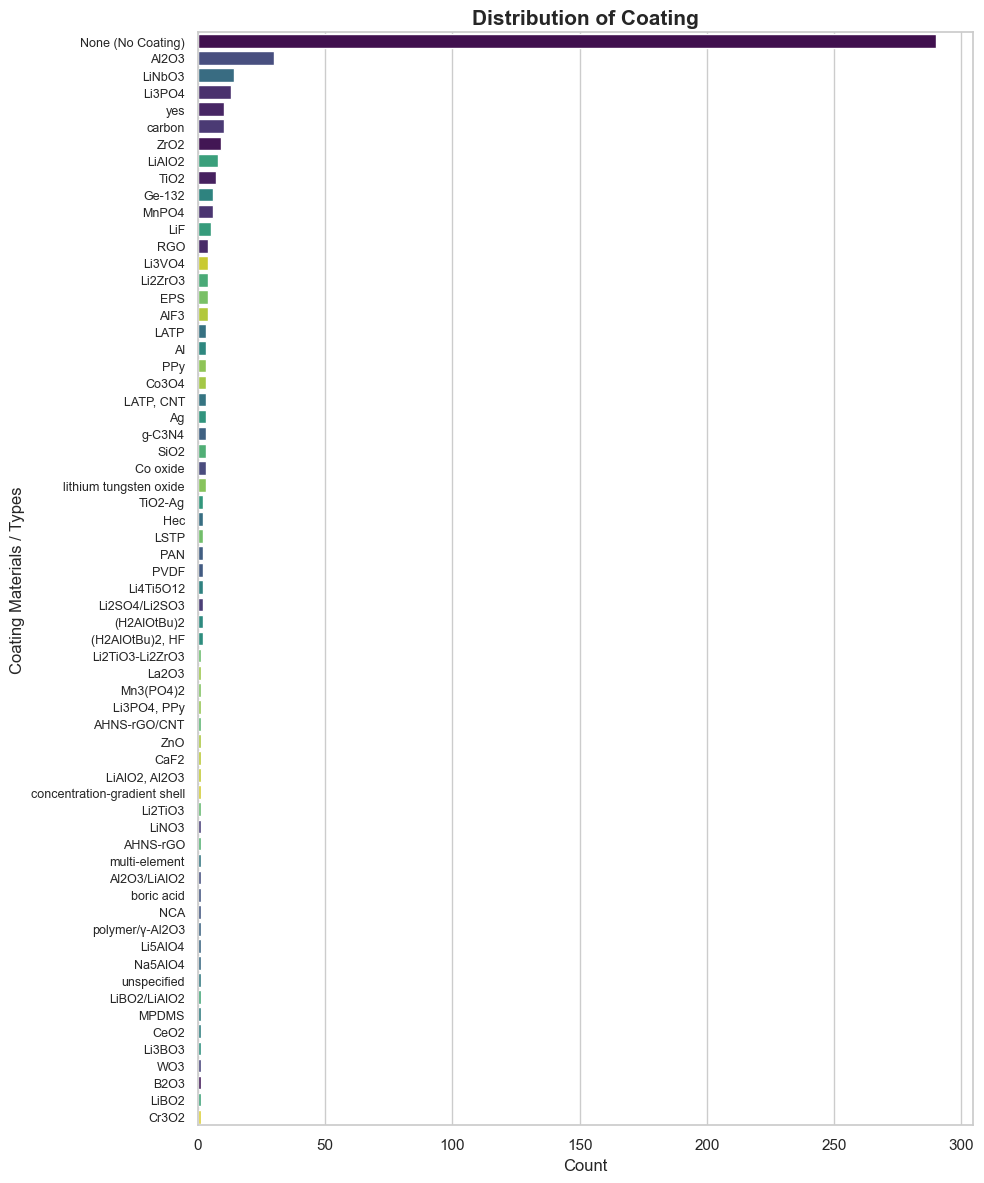

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 분포 확인 (dropna=False를 사용하여 NaN까지 포함)
coating_dist = df['Coating'].value_counts(dropna=False)

print("--- Coating 분포 확인 (전체 목록 출력) ---")
# .to_string()을 사용하면 중간 생략 없이 64개 데이터가 모두 출력됩니다!
print(coating_dist.to_string())

# ==========================================
# 2. 시각화 (경고 메시지 해결 및 완벽한 디자인 양식 적용)
# ==========================================
# 코팅 물질 종류가 많으므로 세로 길이를 12로 넉넉하게 설정
plt.figure(figsize=(10, 12)) 
sns.set_theme(style="whitegrid")

plot_data = df['Coating'].fillna('None (No Coating)')

# 경고(FutureWarning) 해결을 위해 hue와 legend 옵션 추가
sns.countplot(y=plot_data, 
              hue=plot_data,       # <--- 경고 해결을 위해 추가
              legend=False,        # <--- 경고 해결을 위해 추가
              order=plot_data.value_counts().index, 
              palette='viridis')

# y축 글자 크기를 약간 줄여서 겹치지 않게 함
plt.yticks(fontsize=9) 

plt.title('Distribution of Coating', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Coating Materials / Types', fontsize=12)

plt.tight_layout()
plt.show()

#### 집전체에 슬러리를 coating 하는 것도 coating 으로 잘못 정보를 추출한 것 같음. PVDF, PAN, EPS 는 바인더 같고, Al, Ag 도 foil이 아닌지 의심스러움

--- 전처리 후 Coating 고유값 분포 ---
Coating
NaN                       290
Metal Oxides               61
Li-based Compounds         50
Phosphates & Fluorides     33
Others / Unspecified       28
Carbon-based               19
Polymers & Organics        16
Hybrids / Composites        7
Name: count, dtype: int64


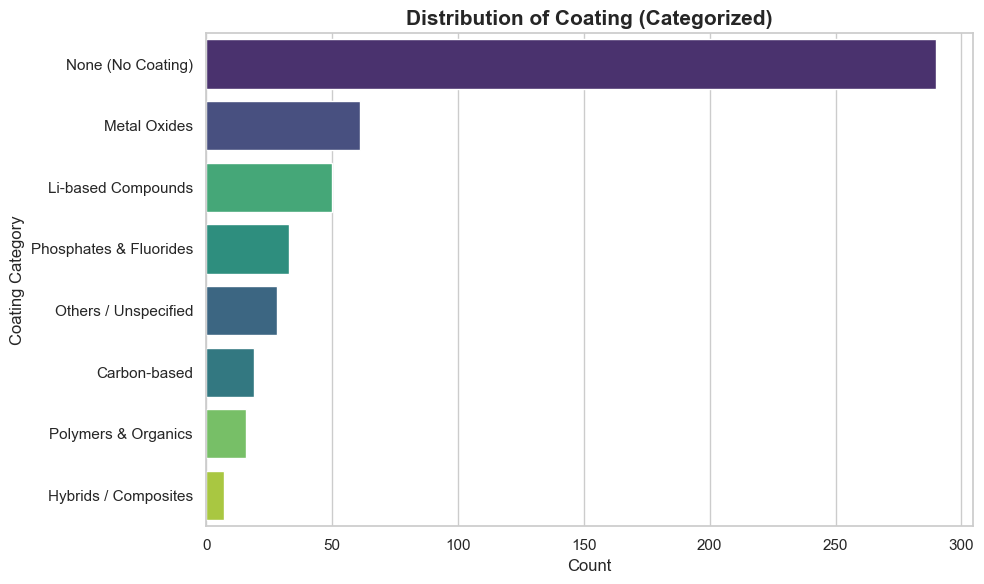

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Coating 카테고리 매핑 정의
coating_mapping = {
    # 1. Metal Oxides (금속 산화물)
    'Al2O3': 'Metal Oxides', 'ZrO2': 'Metal Oxides', 'TiO2': 'Metal Oxides', 
    'Co3O4': 'Metal Oxides', 'SiO2': 'Metal Oxides', 'Co oxide': 'Metal Oxides', 
    'WO3': 'Metal Oxides', 'B2O3': 'Metal Oxides', 'Cr3O2': 'Metal Oxides', 
    'CeO2': 'Metal Oxides', 'ZnO': 'Metal Oxides', 'La2O3': 'Metal Oxides',
    
    # 2. Li-based Compounds (리튬 화합물 및 고체전해질)
    'LiNbO3': 'Li-based Compounds', 'LiAlO2': 'Li-based Compounds', 
    'Li3VO4': 'Li-based Compounds', 'Li2ZrO3': 'Li-based Compounds', 
    'LSTP': 'Li-based Compounds', 'Li4Ti5O12': 'Li-based Compounds', 
    'Li2SO4/Li2SO3': 'Li-based Compounds', 'lithium tungsten oxide': 'Li-based Compounds', 
    'Li2TiO3-Li2ZrO3': 'Li-based Compounds', 'LiAlO2, Al2O3': 'Li-based Compounds', 
    'Li2TiO3': 'Li-based Compounds', 'LiNO3': 'Li-based Compounds', 
    'Al2O3/LiAlO2': 'Li-based Compounds', 'Li5AlO4': 'Li-based Compounds', 
    'Na5AlO4': 'Li-based Compounds', 'LiBO2/LiAlO2': 'Li-based Compounds', 
    'Li3BO3': 'Li-based Compounds', 'LiBO2': 'Li-based Compounds', 'NCA': 'Li-based Compounds',
    
    # 3. Phosphates & Fluorides (인산염 및 불화물)
    'Li3PO4': 'Phosphates & Fluorides', 'MnPO4': 'Phosphates & Fluorides', 
    'LiF': 'Phosphates & Fluorides', 'AlF3': 'Phosphates & Fluorides', 
    'CaF2': 'Phosphates & Fluorides', 'Mn3(PO4)2': 'Phosphates & Fluorides',
    'LATP': 'Phosphates & Fluorides', # LATP는 인산염 기반 고체전해질
    
    # 4. Carbon-based (탄소계)
    'carbon': 'Carbon-based', 'RGO': 'Carbon-based', 'g-C3N4': 'Carbon-based', 
    'AHNS-rGO': 'Carbon-based', 'AHNS-rGO/CNT': 'Carbon-based',
    
    # 5. Polymers & Organics (고분자 및 유기물)
    'EPS': 'Polymers & Organics', 'PPy': 'Polymers & Organics', 'PAN': 'Polymers & Organics', 
    'PVDF': 'Polymers & Organics', 'MPDMS': 'Polymers & Organics', 
    '(H2AlOtBu)2': 'Polymers & Organics', '(H2AlOtBu)2, HF': 'Polymers & Organics',
    
    # 6. Hybrids / Composites (복합 코팅)
    'TiO2-Ag': 'Hybrids / Composites', 'LATP, CNT': 'Hybrids / Composites', 
    'Li3PO4, PPy': 'Hybrids / Composites', 'polymer/γ-Al2O3': 'Hybrids / Composites',
    
    # 7. Others / Unspecified (기타 및 미상)
    'yes': 'Others / Unspecified', 'unspecified': 'Others / Unspecified', 
    'Al': 'Others / Unspecified', 'Ag': 'Others / Unspecified', 
    'Ge-132': 'Others / Unspecified', 'Hec': 'Others / Unspecified', 
    'concentration-gradient shell': 'Others / Unspecified', 
    'multi-element': 'Others / Unspecified', 'boric acid': 'Others / Unspecified'
}

# 2. 매핑 적용 (NaN은 자동으로 그대로 유지됨)
df['Coating'] = df['Coating'].replace(coating_mapping)

# [확인용] 결과 출력
print("--- 전처리 후 Coating 고유값 분포 ---")
print(df['Coating'].value_counts(dropna=False))

# ==========================================
# 3. 시각화 (요청하신 완벽한 디자인 양식 적용)
# ==========================================
plt.figure(figsize=(10, 6)) # 카테고리가 7개로 줄었으므로 세로 크기를 다시 6으로 원복
sns.set_theme(style="whitegrid")

# NaN은 'None (No Coating)'으로 표시하여 시각화
plot_data = df['Coating'].fillna('None (No Coating)')

# 가로 막대(y=), 빈도순 정렬(order=), viridis 팔레트 적용, 경고 메시지 방지(hue, legend)
sns.countplot(y=plot_data, 
              hue=plot_data,
              legend=False,
              order=plot_data.value_counts().index, 
              palette='viridis')

plt.title('Distribution of Coating (Categorized)', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Coating Category', fontsize=12)

plt.tight_layout()
plt.show()

### Active material to Conductive additive to Binder ratio 열 전처리 => 3개로 분리

[전처리 완료: 정규화된 비율 데이터 분포 확인]

--- Active material ratio ---
Active material ratio
80.0    173
NaN      80
90.0     79
85.0     46
96.0     23
Name: count, dtype: int64
------------------------------
--- Conductive additive ratio ---
Conductive additive ratio
10.0    164
NaN      80
5.0      75
4.0      53
15.0     38
Name: count, dtype: int64
------------------------------
--- Binder ratio ---
Binder ratio
10.0    160
5.0     126
NaN      80
3.0      34
2.0      26
Name: count, dtype: int64
------------------------------


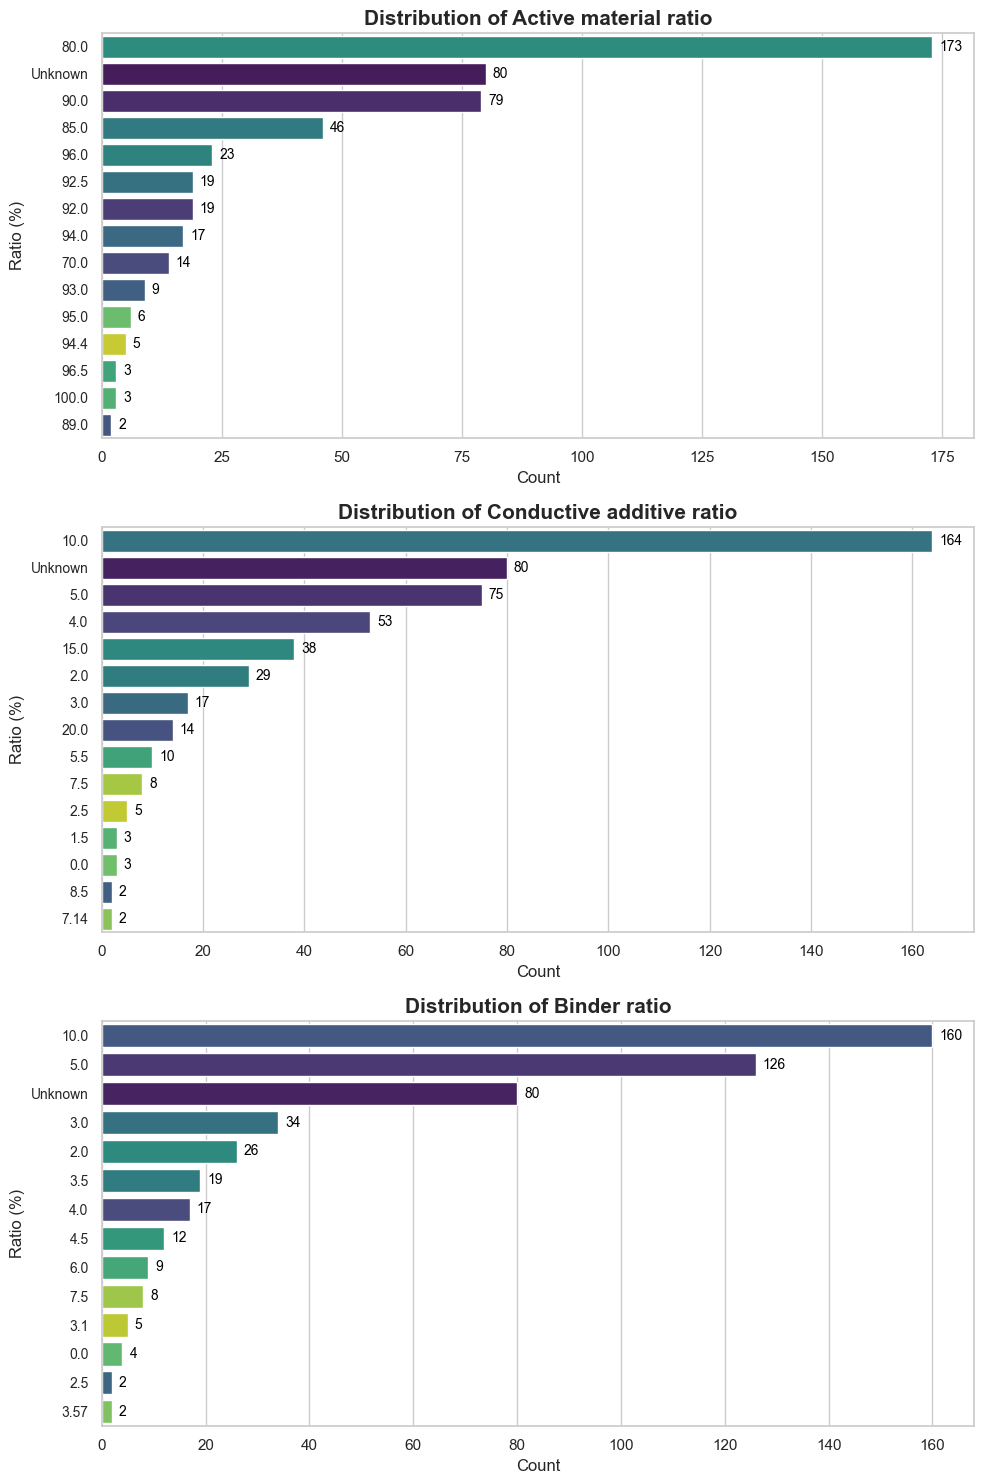

In [1]:
import pandas as pd
import re
from openpyxl import load_workbook
from datetime import time, timedelta
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 파일 불러오기
# ==========================================
file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
df = pd.read_excel(file_path)

# ==========================================
# 2. Excel 시간 변환 오류 강제 복원 및 100% 정규화
# ==========================================
target_col = "Active material to Conductive additive to Binder ratio"

# openpyxl로 원본 셀 값 읽기
wb = load_workbook(file_path, data_only=True)
ws = wb.active
headers = [cell.value for cell in ws[1]]
col_idx = headers.index(target_col) + 1

def restore_and_normalize(value):
    if isinstance(value, time):
        s = f"{value.hour}:{value.minute}:{value.second}"
    elif isinstance(value, timedelta):
        total_sec = int(round(value.total_seconds()))
        s = f"{total_sec // 3600}:{(total_sec % 3600) // 60}:{total_sec % 60}"
    else:
        s = str(value) if pd.notna(value) else ""
        
    # 방해 문자 제거 및 분리
    s = re.sub(r'[a-zA-Z%\s]', '', s)
    s = re.sub(r'[/_,-]', ':', s)
    parts = s.split(':')
    
    if len(parts) == 3:
        try:
            nums = [float(p) for p in parts]
            total = sum(nums)
            if total > 0:
                # 100% 기준으로 비율 맞추기 (소수점 둘째 자리까지 깔끔하게)
                return [round(n / total * 100, 2) for n in nums] 
        except ValueError:
            pass
    return [None, None, None]

# 함수 적용 및 새로운 열 생성
raw_values = [ws.cell(row=r, column=col_idx).value for r in range(2, ws.max_row + 1)]
restored_data = [restore_and_normalize(v) for v in raw_values]

ratio_cols = ['Active material ratio', 'Conductive additive ratio', 'Binder ratio']
df[ratio_cols] = pd.DataFrame(restored_data, index=df.index)

# ==========================================
# 3. 텍스트로 상위 분포 확인
# ==========================================
print("[전처리 완료: 정규화된 비율 데이터 분포 확인]\n")
for col in ratio_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).head(5)) # 텍스트는 간략히 5개만 출력
    print("-" * 30)

# ==========================================
# 4. 완벽한 디자인의 분포 시각화 (상위 15개, 막대 값 표시)
# ==========================================
plt.figure(figsize=(10, 15))
sns.set_theme(style="whitegrid")

for i, col in enumerate(ratio_cols, 1):
    plt.subplot(3, 1, i)
    
    # NaN은 'Unknown'으로 표시 (문자열 변환)
    plot_data = df[col].fillna('Unknown').astype(str)
    
    # 데이터 종류가 너무 많아 겹치는 것을 방지하기 위해 상위 15개만 추출
    top_order = plot_data.value_counts().index[:15]
    
    # 가로 막대, 빈도순 정렬, viridis 팔레트, 경고 방지
    ax = sns.countplot(y=plot_data, 
                       hue=plot_data,
                       legend=False,
                       order=top_order, 
                       palette='viridis')
    
    # 막대 끝에 숫자(개수) 표시
    for container in ax.containers:
        ax.bar_label(container, padding=5, fontsize=10, color='black')
        
    plt.yticks(fontsize=10)
    plt.title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Ratio (%)', fontsize=12)

# 그래프 간의 간격을 자동으로 예쁘게 조절
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import plotly.express as px

# ==========================================
# 1. 용량 데이터 수치형 변환 및 교집합 추출
# ==========================================
target_capacity = 'C-rate 0.1'
ratio_cols = ['Active material ratio', 'Conductive additive ratio', 'Binder ratio']

df[target_capacity] = pd.to_numeric(df[target_capacity], errors='coerce')

# 4개 데이터가 모두 존재하는 행만 추출
ternary_data = df[ratio_cols + [target_capacity]].dropna()

print(f"--- 시각화에 사용될 유효한 데이터 개수: {len(ternary_data)}개 ---")

# ==========================================
# 2. 줌인(Zoom-in)을 위한 최솟값 계산
# ==========================================
min_active = max(0, ternary_data['Active material ratio'].min() - 1)
min_cond = max(0, ternary_data['Conductive additive ratio'].min() - 1)
min_binder = max(0, ternary_data['Binder ratio'].min() - 1)

# ==========================================
# 3. Plotly 삼각도 시각화
# ==========================================
fig = px.scatter_ternary(
    ternary_data, 
    a="Active material ratio", b="Conductive additive ratio", c="Binder ratio",
    color=target_capacity, color_continuous_scale="viridis",
    size=target_capacity, size_max=15,
    title="Zoomed Ternary Plot: Electrode Composition vs Capacity"
)

fig.update_layout(
    title_font=dict(size=20, family="Arial", color="black"),
    ternary=dict(
        sum=100, 
        aaxis=dict(title=dict(text="Active Material (%)", font=dict(size=14)), min=min_active),
        baxis=dict(title=dict(text="Conductive Additive (%)", font=dict(size=14)), min=min_cond),
        caxis=dict(title=dict(text="Binder (%)", font=dict(size=14)), min=min_binder)
    ),
    paper_bgcolor="white"
)

fig.show()

--- 시각화에 사용될 유효한 데이터 개수: 167개 ---


### Electrolyte salt

--- Electrolyte salt 분포 확인 (상위 15개) ---
Electrolyte salt
LiPF6      435
Unknown     61
LiAsF6       6
TBAClO4      2
Name: count, dtype: int64
----------------------------------------


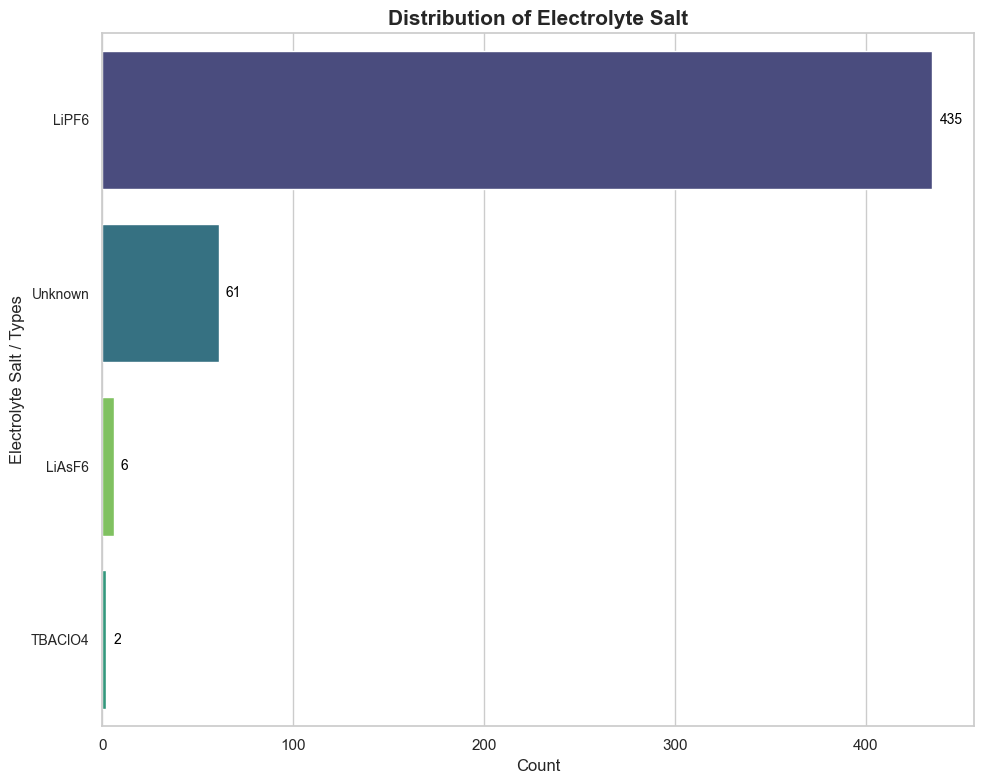

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 분포 확인 (결측치 포함)
# ==========================================
# 결측치(NaN)를 'Unknown'으로 변환하여 안전하게 문자열 처리
salt_data = df['Electrolyte salt'].fillna('Unknown').astype(str)

print("--- Electrolyte salt 분포 확인 (상위 15개) ---")
print(salt_data.value_counts().head(15))
print("-" * 40)

# ==========================================
# 2. 완벽한 디자인의 분포 시각화 (막대 값 표시)
# ==========================================
# 항목이 많을 것을 대비해 세로 길이를 넉넉하게 8로 설정
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 상위 15개 항목만 추출하여 그래프가 너무 복잡해지는 것을 방지
top_order = salt_data.value_counts().index[:15]

# 가로 막대, 빈도순 정렬, viridis 팔레트, 경고 메시지 방지(hue, legend)
ax = sns.countplot(y=salt_data, 
                   hue=salt_data,
                   legend=False,
                   order=top_order, 
                   palette='viridis')

# 막대 끝에 숫자(개수) 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='black')

# y축 글자가 길 경우를 대비해 폰트 크기 조절
plt.yticks(fontsize=10)
plt.title('Distribution of Electrolyte Salt', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Electrolyte Salt / Types', fontsize=12)

plt.tight_layout()
plt.show()

### Electrolyte concentration

[전처리 완료: mM까지 완벽하게 처리된 농도 분포]

Cleaned Concentration
1M         405
UNKNOWN     70
1.2M        17
1.1M         5
1.15M        3
1.3M         2
0.01M        2
Name: count, dtype: int64
----------------------------------------


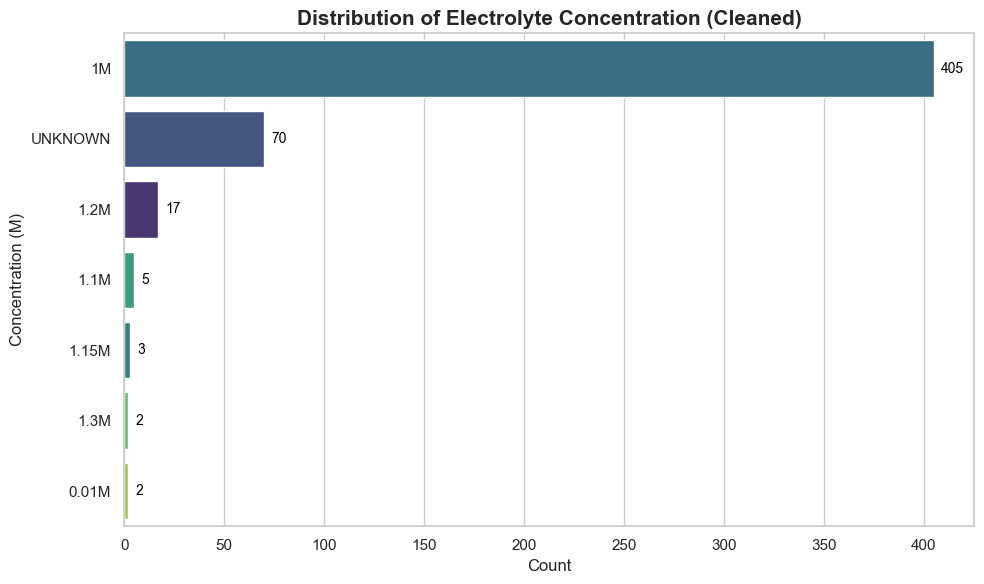

In [57]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 'mM'까지 잡아내는 궁극의 농도 단위 통일
# ==========================================
conc_col = df['Electrolyte concentration'].fillna('Unknown').astype(str)

# A. 공백을 먼저 완벽하게 제거 ('10 mM' -> '10mM')
conc_col = conc_col.str.replace(r'\s+', '', regex=True)

# B. [핵심 추가] mM 단위를 M으로 수학적 변환 ('10mM' -> '0.01M')
# (대문자로 바꾸기 전에 소문자 m이 살아있을 때 캐치해야 합니다!)
conc_col = conc_col.str.replace(r'10mM', '0.01M', case=False, regex=True)

# C. 이제 안심하고 모두 대문자로 통일
conc_col = conc_col.str.upper()

# D. 특수문자(⋅, −, /) 방어: 'MOL' 뒤에 붙은 단위들을 모조리 'M'으로 덮어쓰기
conc_col = conc_col.str.replace(r'MOL.*', 'M', regex=True)

# E. 소수점 통일: '.0M' 혹은 '.00M' 등을 깔끔하게 'M'으로 압축 ('1.0M' -> '1M')
conc_col = conc_col.str.replace(r'\.0+M', 'M', regex=True)

df['Cleaned Concentration'] = conc_col

# ==========================================
# 2. 텍스트로 상위 분포 확인
# ==========================================
print("[전처리 완료: mM까지 완벽하게 처리된 농도 분포]\n")
print(df['Cleaned Concentration'].value_counts().head(10))
print("-" * 40)

# ==========================================
# 3. 완벽한 디자인의 분포 시각화
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plot_data = df['Cleaned Concentration']
top_order = plot_data.value_counts().index[:10]

ax = sns.countplot(y=plot_data, 
                   hue=plot_data,
                   legend=False,
                   order=top_order, 
                   palette='viridis')

for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='black')

plt.yticks(fontsize=11)
plt.title('Distribution of Electrolyte Concentration (Cleaned)', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Concentration (M)', fontsize=12)

plt.tight_layout()
plt.show()

### Genspark로 해결 중_Electrolyte solvent & ratio

In [18]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from openpyxl import load_workbook
from datetime import time, timedelta

# =========================================================
# 0. 파일/컬럼 설정
# =========================================================
file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
sheet_name = 0   # 첫 번째 시트
solvent_col = "Electrolyte solvent"
ratio_col = "Electrolyte solvent ratio"

# 결과 저장 파일명
output_file = "electrolyte_solvent_preprocessed.xlsx"

# =========================================================
# 1. 원본 데이터 읽기
# =========================================================
df = pd.read_excel(file_path, sheet_name=sheet_name)

# ratio 열은 pandas가 Excel time/timedelta로 읽어버릴 수 있어서
# openpyxl로 원본 cell value를 다시 읽어옴
wb = load_workbook(file_path, data_only=True)
ws = wb[wb.sheetnames[sheet_name if isinstance(sheet_name, int) else 0]]

headers = [cell.value for cell in ws[1]]
ratio_idx = headers.index(ratio_col) + 1
raw_ratio_values = [ws.cell(row=r, column=ratio_idx).value for r in range(2, ws.max_row + 1)]

# =========================================================
# 2. 전처리용 함수
# =========================================================
def ratio_value_to_string(value):
    """
    Excel이 ratio를 time/timedelta로 바꿔 읽은 경우까지 포함해
    최종적으로 'a:b:c' 문자열로 복원
    """
    if value is None:
        return None
    if isinstance(value, float) and math.isnan(value):
        return None

    # 문자열
    if isinstance(value, str):
        s = re.sub(r"\s+", "", value)
        return s if s else None

    # 01:01:00 / 03:07:00 류가 time으로 읽힌 경우
    if isinstance(value, time):
        return f"{value.hour}:{value.minute}:{value.second}"

    # 일부는 timedelta로 읽힐 수 있음
    if isinstance(value, timedelta):
        total_seconds = int(round(value.total_seconds()))
        h = total_seconds // 3600
        m = (total_seconds % 3600) // 60
        s = total_seconds % 60
        return f"{h}:{m}:{s}"

    s = re.sub(r"\s+", "", str(value))
    return s if s else None


def standardize_solvent_name(name):
    """
    solvent 이름 통일
    필요시 alias를 여기서 추가
    """
    name = str(name).strip()
    name = re.sub(r"\s+", " ", name)

    # 대표적 alias 통일
    alias_map = {
        "fluoroethylene carbonate": "FEC",
        "Fluoroethylene carbonate": "FEC",
        "fluoroethylenecarbonate": "FEC",
    }
    return alias_map.get(name, name)


def split_solvent_list(value):
    """
    'EC:DMC', 'EC/DMC', 'EC ; DMC' 등 구분자 정리 후 solvent list 반환
    """
    if pd.isna(value):
        return []

    s = str(value).strip()
    if not s:
        return []

    s = s.replace("：", ":").replace(";", ":").replace("/", ":")
    parts = [p.strip() for p in s.split(":") if p.strip()]

    return [standardize_solvent_name(p) for p in parts]


def parse_ratio_list(value):
    """
    ratio 열을 숫자 리스트로 변환
    예:
    '1:1' -> [1, 1]
    '03:07:00' -> [3, 7, 0]
    """
    s = ratio_value_to_string(value)
    if s is None:
        return []

    s = s.replace("：", ":").replace(";", ":").replace(",", ".")
    s = s.replace("%", "")
    parts = [p for p in s.split(":") if p != ""]

    try:
        vals = [float(p) for p in parts]
    except ValueError:
        return []

    return vals


def align_and_normalize(solvents, ratios):
    """
    solvent 개수와 ratio 개수를 맞추고, 최종적으로 합이 100이 되도록 정규화
    """
    if not solvents:
        return None, "no_solvent"

    if not ratios:
        return None, "missing_ratio"

    # ratio 개수가 더 많고 뒤가 0이면 제거
    if len(ratios) > len(solvents):
        trimmed = list(ratios)
        while len(trimmed) > len(solvents) and abs(trimmed[-1]) < 1e-12:
            trimmed.pop()
        ratios = trimmed

    if len(ratios) != len(solvents):
        return None, f"length_mismatch_{len(solvents)}_{len(ratios)}"

    total = sum(ratios)
    if total <= 0:
        return None, "nonpositive_ratio_sum"

    normalized = [r / total * 100 for r in ratios]
    return normalized, "ok"


def safe_feature_name(solvent_name):
    """
    ML/heatmap용 안전한 열 이름 생성
    예: 'methyl (2,2,2-trifluoroethyl) carbonate' -> 'METHYL_2_2_2_TRIFLUOROETHYL_CARBONATE'
    """
    x = solvent_name.upper()
    x = re.sub(r"[^A-Z0-9]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x


# =========================================================
# 3. solvent + ratio 파싱
# =========================================================
parsed_rows = []
all_solvents = set()
feature_name_map = {}   # 원래 solvent명 -> 안전한 열 suffix

for solvent_raw, ratio_raw in zip(df[solvent_col], raw_ratio_values):
    solvents = split_solvent_list(solvent_raw)
    ratios = parse_ratio_list(ratio_raw)

    normalized, status = align_and_normalize(solvents, ratios)

    row_dict = {
        "cleaned_solvent_list": ":".join(solvents) if solvents else pd.NA,
        "cleaned_ratio_list_raw": ":".join(map(str, ratios)) if ratios else pd.NA,
        "num_solvents": len(solvents),
        "solvent_ratio_missing": 0,
        "solvent_parse_issue": 0,
        "solvent_status": status,
    }

    if status != "ok":
        if status == "missing_ratio":
            row_dict["solvent_ratio_missing"] = 1
        elif status != "no_solvent":
            row_dict["solvent_parse_issue"] = 1

    if normalized is not None:
        for solvent, ratio_value in zip(solvents, normalized):
            safe_name = safe_feature_name(solvent)
            feature_col = f"solvent_ratio_{safe_name}"

            feature_name_map[solvent] = feature_col
            all_solvents.add(solvent)
            row_dict[feature_col] = ratio_value

    parsed_rows.append(row_dict)

parsed_df = pd.DataFrame(parsed_rows)

# =========================================================
# 4. solvent별 비율 열 생성
# =========================================================
# parsed_df에 없는 용매 열은 0.0으로 초기화
for solvent in sorted(all_solvents):
    col = feature_name_map[solvent]
    if col not in parsed_df.columns:
        parsed_df[col] = 0.0

solvent_ratio_cols = sorted([c for c in parsed_df.columns if str(c).startswith("solvent_ratio_")])

parsed_df[solvent_ratio_cols] = parsed_df[solvent_ratio_cols].fillna(0.0)

# 보기 좋게 반올림
parsed_df[solvent_ratio_cols] = parsed_df[solvent_ratio_cols].round(4)

# 원본 df와 결합
df_final = pd.concat([df, parsed_df], axis=1)

# =========================================================
# 5. solvent명 <-> feature 열 이름 매핑표
# =========================================================
mapping_df = pd.DataFrame({
    "original_solvent_name": list(feature_name_map.keys()),
    "feature_column_name": list(feature_name_map.values())
}).sort_values("feature_column_name").reset_index(drop=True)

In [19]:
# 'solvent_ratio_'로 시작하는 모든 열 필터링
new_ratio_cols = [col for col in df_final.columns if col.startswith('solvent_ratio_')]

# 원본 텍스트와 전처리된 수치형 열 5개 예시 출력
print("[전처리 결과 확인: 원본 텍스트 -> 수치형 변환 예시]")
preview_cols = [solvent_col, ratio_col] + new_ratio_cols[:5] # 너무 많으면 잘리므로 앞의 5개 용매만
print(df_final[preview_cols].dropna(subset=[solvent_col]).head(5).to_string())

[전처리 결과 확인: 원본 텍스트 -> 수치형 변환 예시]
  Electrolyte solvent Electrolyte solvent ratio  solvent_ratio_missing  solvent_ratio_EC  solvent_ratio_EMC  solvent_ratio_DEC  solvent_ratio_DMC
0              EC:EMC                  03:07:00                      0           30.0000            70.0000             0.0000                0.0
1              EC:EMC                  03:07:00                      0           30.0000            70.0000             0.0000                0.0
2              EC:EMC                  03:07:00                      0           30.0000            70.0000             0.0000                0.0
3          EC:EMC:DEC                  01:01:01                      0           33.3333            33.3333            33.3333                0.0
4          EC:EMC:DEC                  01:01:01                      0           33.3333            33.3333            33.3333                0.0


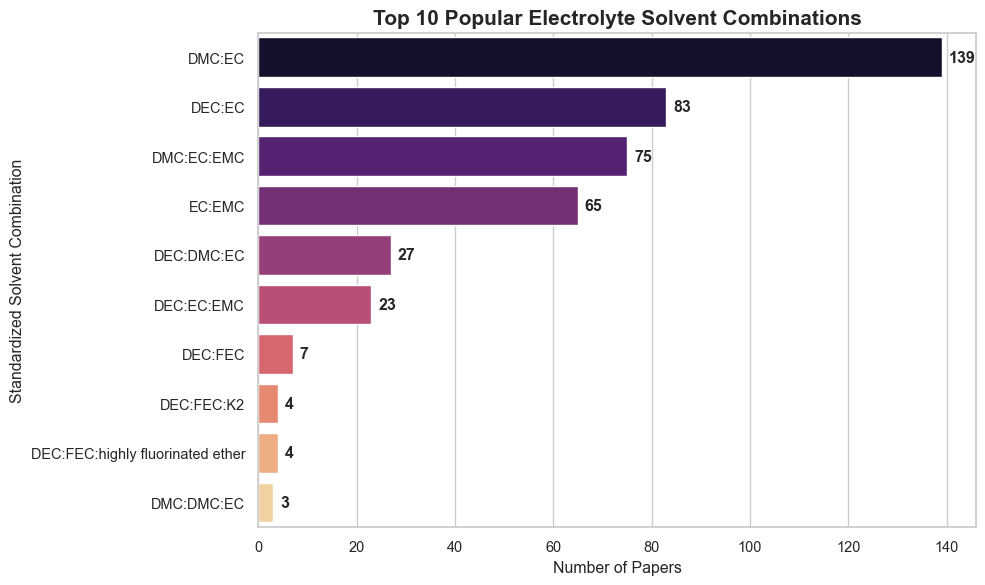

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# (서연 님의 기존 전처리 코드 쭈욱 있음...)
# =========================================================

# 원본 df와 결합 (기존 전처리 코드의 마지막 부분)
df_final = pd.concat([df, parsed_df], axis=1)

# =========================================================
# 6. 통일된 용매 조합으로 시각화하기 (새로 추가할 부분)
# =========================================================
# 1. 조합명 알파벳 순 정렬 함수
def sort_combination(x):
    if pd.isna(x):
        return x
    return ':'.join(sorted(x.split(':')))

# 2. 새로운 열에 통일된 조합명을 저장
df_final['standard_combination'] = df_final['cleaned_solvent_list'].apply(sort_combination)

# 3. 정렬된 새로운 열을 기준으로 다시 빈도수 카운트!
combination_counts = df_final['standard_combination'].value_counts().head(10)

# 4. 시각화 
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=combination_counts.values, y=combination_counts.index, 
                 palette='magma', hue=combination_counts.index, legend=False)

# 막대 끝에 숫자 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold')

plt.title("Top 10 Popular Electrolyte Solvent Combinations", fontsize=15, fontweight='bold')
plt.xlabel("Number of Papers")
plt.ylabel("Standardized Solvent Combination")

plt.tight_layout()
plt.show()

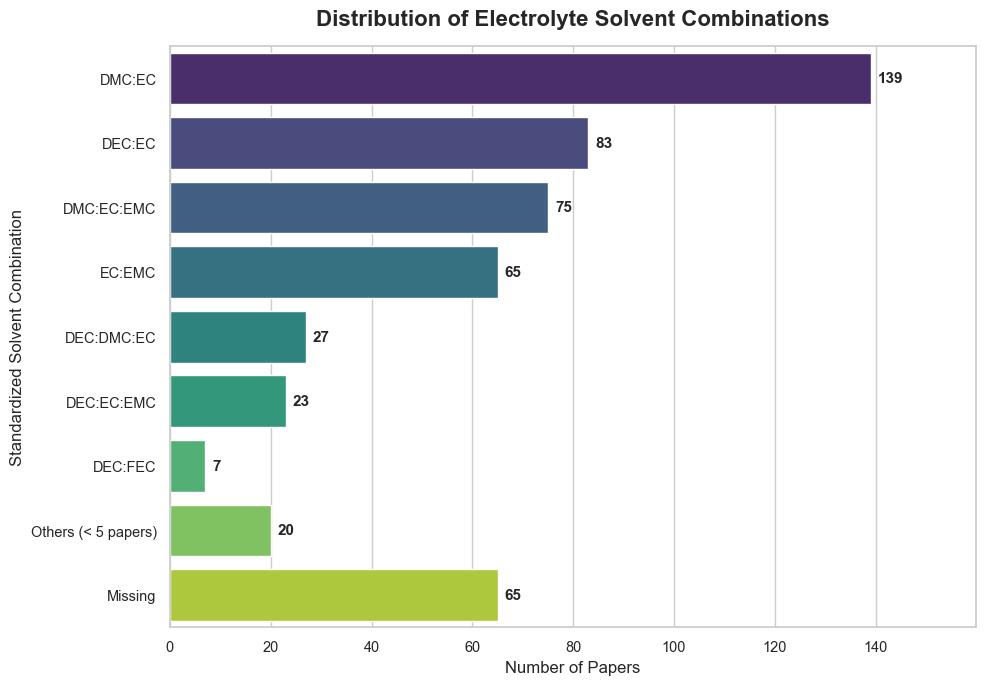

In [21]:
# =========================================================
# 6. 용매 조합 정렬 및 5개 미만 'Others' 통일 시각화
# =========================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 조합명 알파벳 순 정렬 함수 (EC:DMC와 DMC:EC 통일)
def sort_combination(x):
    if pd.isna(x):
        return "Missing" # 비어있는 데이터는 Missing으로 처리
    return ':'.join(sorted(x.split(':')))

# 새로운 열에 통일된 조합명을 저장
df_final['standard_combination'] = df_final['cleaned_solvent_list'].apply(sort_combination)

# 2. 각 조합의 전체 빈도수 계산
raw_counts = df_final['standard_combination'].value_counts()

# 3. 빈도수 5 미만인 조합을 'Others'로 묶어주는 함수
def group_others(combo):
    if combo == "Missing":
        return "Missing"
    if raw_counts[combo] < 5:
        return "Others (< 5 papers)"
    return combo

# 'Others'가 적용된 최종 조합 열 생성
df_final['grouped_combination'] = df_final['standard_combination'].apply(group_others)

# 4. 최종 빈도수 카운트
grouped_counts = df_final['grouped_combination'].value_counts()

# 그래프를 예쁘게 그리기 위해 순서 정렬 (개수 많은 순 -> Others -> Missing 순서)
# Others와 Missing을 그래프 맨 아래로 보내는 로직입니다.
main_cats = grouped_counts.drop(labels=["Others (< 5 papers)", "Missing"], errors='ignore').sort_values(ascending=False)
others_cats = grouped_counts[grouped_counts.index.isin(["Others (< 5 papers)"])]
missing_cats = grouped_counts[grouped_counts.index.isin(["Missing"])]

final_plot_order = pd.concat([main_cats, others_cats, missing_cats])

# 5. 시각화
plt.figure(figsize=(10, 7))
ax = sns.barplot(x=final_plot_order.values, y=final_plot_order.index, 
                 palette='viridis', hue=final_plot_order.index, legend=False)

# 막대 끝에 숫자 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight='bold', fontsize=11)

plt.title("Distribution of Electrolyte Solvent Combinations", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Number of Papers", fontsize=12)
plt.ylabel("Standardized Solvent Combination", fontsize=12)

# 가독성을 위해 x축 범위 살짝 늘리기
plt.xlim(0, final_plot_order.max() * 1.15)

plt.tight_layout()
plt.show()

### Additive

[Additive 전처리 완료: 물질 및 함량 분포 확인]

--- 1. Additive Material (순수 물질만) ---
Additive Material
None / Unknown          445
VC                       37
FEC                       7
LiDFOB                    4
TMEB                      3
LiBOB                     2
proprietary additive      2
DA                        1
DODSi                     1
Li2S                      1
Name: count, dtype: int64
------------------------------
--- 2. Additive Original (물질 + 함량 형태) ---
Additive Original
None / Unknown              445
VC, 2%                       23
VC, 1%                        8
FEC, 5.0%                     4
LiDFOB, 5-8%                  4
VC, 1 wt%                     4
FEC, 10%                      2
VC, 2 wt%                     2
proprietary additive, 2%      2
LiBOB, 0.1M; DA, 0.1%         1
Name: count, dtype: int64
------------------------------
--- 3. Additive Amount (함량 표기 형태) ---
Additive Amount
Not specified    446
2%                25
1%                 8
5.0%               

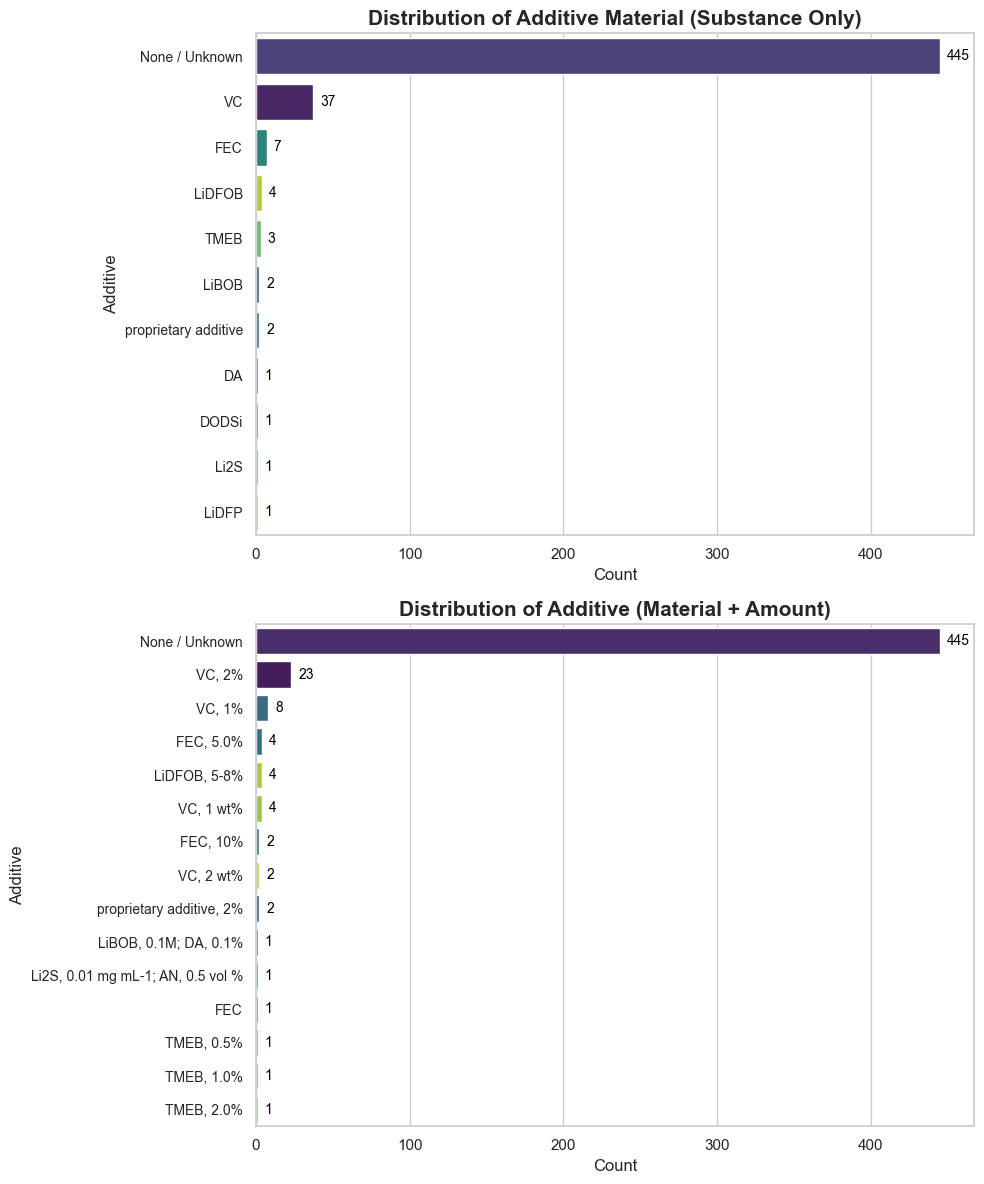

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Additive 열 전처리 (물질과 함량 분리)
# ==========================================
# 결측치(NaN)를 빈 문자열로 안전하게 변환
additive_col = df['Additive'].fillna('').astype(str)

# 콤마(,)를 기준으로 첫 번째 항목(물질)과 두 번째 항목(함량)으로 분리
# n=1 은 첫 번째 콤마에서만 자르라는 뜻입니다. (예: "VC, 2 wt%" -> "VC" / "2 wt%")
split_additive = additive_col.str.split(',', n=1, expand=True)

# 새로운 열 생성 및 좌우 공백(띄어쓰기) 깔끔하게 제거
df['Additive Material'] = split_additive[0].str.strip()

# 두 번째 항목(함량)이 없는 경우를 대비해 예외 처리
if len(split_additive.columns) > 1:
    df['Additive Amount'] = split_additive[1].str.strip()
else:
    df['Additive Amount'] = None

# 빈 문자열을 분석하기 좋게 직관적인 이름으로 변경
df['Additive Material'] = df['Additive Material'].replace('', 'None / Unknown')
df['Additive Amount'] = df['Additive Amount'].replace('', 'Not specified').fillna('Not specified')
df['Additive Original'] = additive_col.str.strip().replace('', 'None / Unknown')

# ==========================================
# 2. 텍스트로 상위 분포 확인
# ==========================================
print("[Additive 전처리 완료: 물질 및 함량 분포 확인]\n")

print("--- 1. Additive Material (순수 물질만) ---")
print(df['Additive Material'].value_counts().head(10))
print("-" * 30)

print("--- 2. Additive Original (물질 + 함량 형태) ---")
print(df['Additive Original'].value_counts().head(10))
print("-" * 30)

print("--- 3. Additive Amount (함량 표기 형태) ---")
print(df['Additive Amount'].value_counts().head(5))
print("-" * 30)

# ==========================================
# 3. 완벽한 디자인의 분포 시각화 (물질 vs 원본 비교)
# ==========================================
# 2개의 그래프를 위아래로 배치 (가로 10, 세로 12)
plt.figure(figsize=(10, 12))
sns.set_theme(style="whitegrid")

# 시각화할 두 개의 열 지정
plot_cols = ['Additive Material', 'Additive Original']
titles = ['Distribution of Additive Material (Substance Only)', 
          'Distribution of Additive (Material + Amount)']

for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 1, i)
    
    # 상위 15개 항목만 추출 (그래프가 너무 복잡해지는 것 방지)
    plot_data = df[col]
    top_order = plot_data.value_counts().index[:15]
    
    # 가로 막대, 빈도순 정렬, viridis 팔레트
    ax = sns.countplot(y=plot_data, 
                       hue=plot_data,
                       legend=False,
                       order=top_order, 
                       palette='viridis')
    
    # 막대 끝에 숫자(개수) 표시
    for container in ax.containers:
        ax.bar_label(container, padding=5, fontsize=10, color='black')
        
    plt.yticks(fontsize=10)
    plt.title(titles[i-1], fontsize=15, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Additive', fontsize=12)

# 그래프 간의 간격을 자동으로 예쁘게 조절
plt.tight_layout()
plt.show()

[카테고리화 완료: Additive Category 분포]
Additive Category
None (No Additive)               446
Carbonate-based (VC, FEC)         44
Other Functional Additives         6
Li-salt based (LiDFOB, LiBOB)      6
Proprietary                        2
Name: count, dtype: int64
----------------------------------------


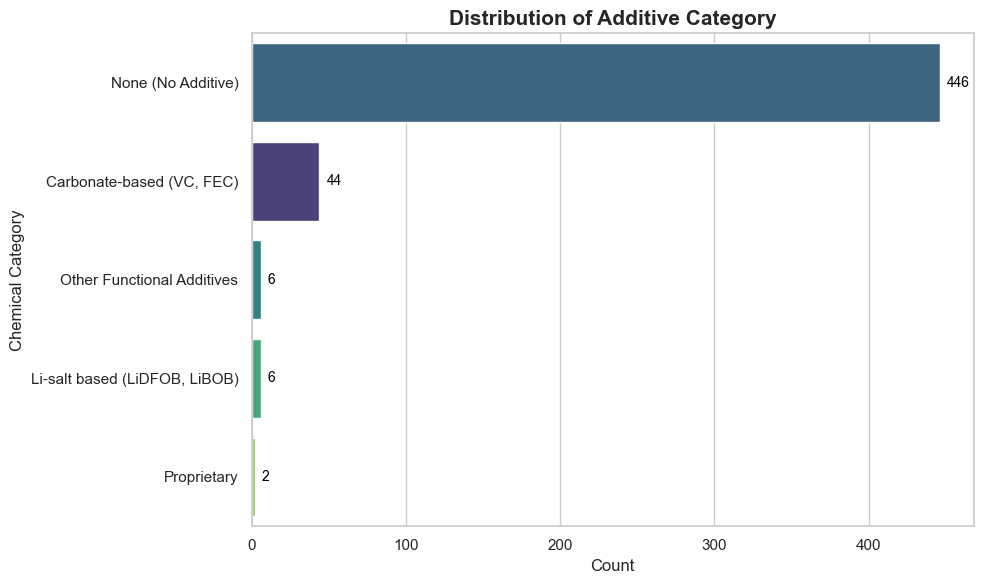

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Additive Material 카테고리 매핑 정의
# ==========================================
additive_mapping = {
    # 1. Carbonate-based (탄산염계 SEI 형성제)
    'VC': 'Carbonate-based (VC, FEC)',
    'FEC': 'Carbonate-based (VC, FEC)',
    
    # 2. Li-salt based (리튬염 보조 첨가제)
    'LiDFOB': 'Li-salt based (LiDFOB, LiBOB)',
    'LiBOB': 'Li-salt based (LiDFOB, LiBOB)',
    
    # 3. Other Functional Additives (기타 특수 기능성)
    'TMEB': 'Other Functional Additives',
    'DODSi': 'Other Functional Additives',
    'Li2S': 'Other Functional Additives',
    'DA': 'Other Functional Additives',
    
    # 4. Proprietary (영업비밀/자체첨가제)
    'proprietary additive': 'Proprietary',
    
    # 5. None (첨가제 없음/미상)
    'None / Unknown': 'None (No Additive)'
}

# 새로운 카테고리 열 생성
df['Additive Category'] = df['Additive Material'].map(additive_mapping).fillna('None (No Additive)')

# ==========================================
# 2. 전처리 결과 확인
# ==========================================
print("[카테고리화 완료: Additive Category 분포]")
print(df['Additive Category'].value_counts(dropna=False))
print("-" * 40)

# ==========================================
# 3. 완벽한 디자인의 시각화 (막대 값 표시)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plot_data = df['Additive Category']

# 가로 막대, 빈도순 정렬, viridis 팔레트
ax = sns.countplot(y=plot_data, 
                   hue=plot_data,
                   legend=False,
                   order=plot_data.value_counts().index, 
                   palette='viridis')

# 막대 끝에 숫자(개수) 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='black')

# y축 글자가 길 수 있으므로 폰트 크기 조절
plt.yticks(fontsize=11)
plt.title('Distribution of Additive Category', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Chemical Category', fontsize=12)

plt.tight_layout()
plt.show()


[Additive 사용 여부 3분류 분포 확인]
Additive Usage Status
Unknown (Not Mentioned)    445
Used (With Additive)        59
Name: count, dtype: int64
----------------------------------------


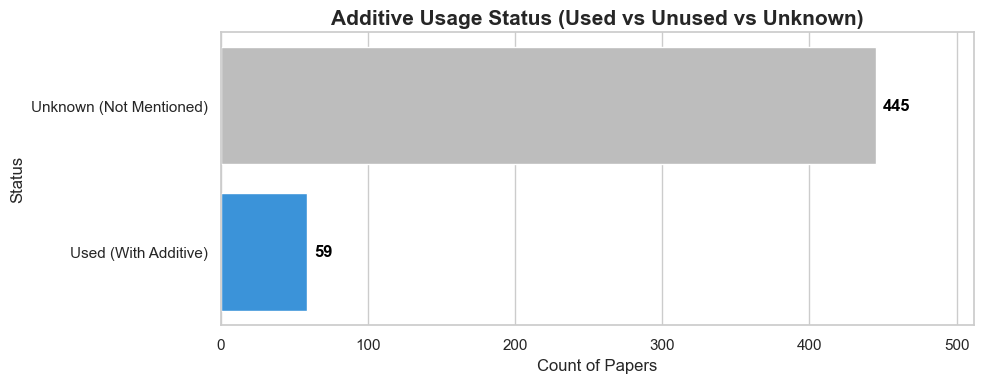

In [23]:
# ==========================================
# 4. Additive 사용 여부 (Usage Status) 3분할 분류 및 시각화
# ==========================================
def classify_usage(text):
    """
    원본 텍스트를 바탕으로 첨가제 사용 여부를 3가지로 분류합니다.
    """
    # 소문자로 변환 후 양쪽 공백 제거
    t = str(text).strip().lower()
    
    # 1. 아예 값이 비어있거나 NaN인 경우 -> 언급 없음
    if t == '' or t == 'nan':
        return 'Unknown (Not Mentioned)'
    
    # 2. '첨가제 없음'을 명시한 경우 -> 미사용
    elif t in ['none', 'no additive', 'without additive', 'n/a', 'base', '0']:
        return 'Unused (Explicitly None)'
    
    # 3. 그 외 특정 물질이 적혀있는 경우 -> 사용
    else:
        return 'Used (With Additive)'

# 원본 'Additive' 열에 함수 적용하여 새로운 열 생성
df['Additive Usage Status'] = df['Additive'].apply(classify_usage)

print("\n[Additive 사용 여부 3분류 분포 확인]")
print(df['Additive Usage Status'].value_counts())
print("-" * 40)

# ------------------------------------------
# 시각화 (가로 막대 그래프)
# ------------------------------------------
plt.figure(figsize=(10, 4))
sns.set_theme(style="whitegrid")

plot_data_usage = df['Additive Usage Status']

# 사용 빈도가 높은 순서대로 정렬
usage_order = plot_data_usage.value_counts().index

# 색상: Used(초록/파랑계열), Unknown(회색), Unused(빨강/주황계열)로 직관성 부여
# viridis 팔레트와 어울리도록 색상 지정
custom_palette = {'Used (With Additive)': '#2196F3', 
                  'Unknown (Not Mentioned)': '#BDBDBD', 
                  'Unused (Explicitly None)': '#FF9800'}

ax3 = sns.countplot(y=plot_data_usage, 
                    hue=plot_data_usage,
                    legend=False,
                    order=usage_order, 
                    palette=custom_palette)

# 막대 끝에 숫자(개수) 표시
for container in ax3.containers:
    ax3.bar_label(container, padding=5, fontsize=12, color='black', fontweight='bold')

plt.yticks(fontsize=11)
plt.title('Additive Usage Status (Used vs Unused vs Unknown)', fontsize=15, fontweight='bold')
plt.xlabel('Count of Papers', fontsize=12)
plt.ylabel('Status', fontsize=12)

# 가독성을 위해 x축 여백 살짝 확보
plt.xlim(0, plot_data_usage.value_counts().max() * 1.15)

plt.tight_layout()
plt.show()

### 미완_Loading density (mass loading of NCM) => 기호들 때문에 전처리가 잘 안돼서 보완 중

[전처리 완료: Loading Density 분포 확인 (상위 15개)]

Cleaned Loading Density
Unknown    259
4-5         24
4           15
2           13
8-9         12
8.5         12
12.5         9
6-7          8
2.0±0.2      8
7            7
3-4          7
7.7          7
4-6          6
12           6
15           5
Name: count, dtype: int64
----------------------------------------


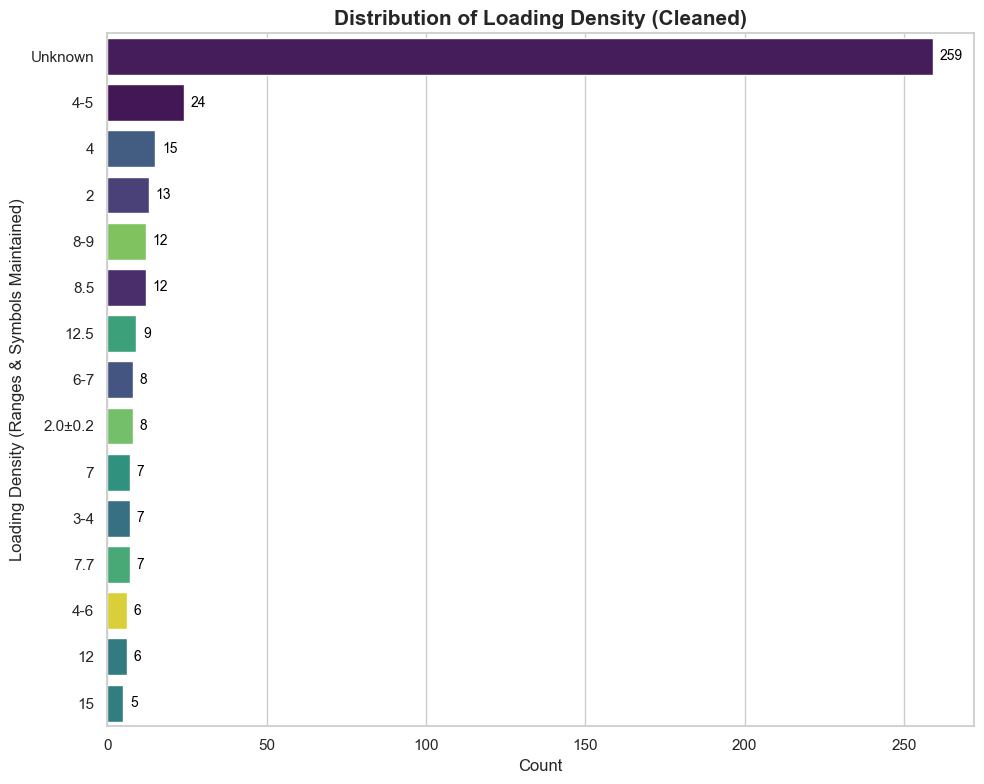

In [62]:
import pandas as pd
import re
from openpyxl import load_workbook
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 파일 불러오기 및 openpyxl 세팅
# ==========================================
file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
df = pd.read_excel(file_path)

target_col = "Loading density (mass loading of NCM)"

wb = load_workbook(file_path, data_only=True)
ws = wb.active
headers = [cell.value for cell in ws[1]]
col_idx = headers.index(target_col) + 1

# ==========================================
# 2. Excel 날짜 변환 오류 강제 복원 및 전처리
# ==========================================
def restore_loading(value):
    # A. 엑셀이 '4-5'를 '4월 5일(datetime)'로 바꾼 경우 복원
    if isinstance(value, datetime.datetime):
        s = f"{value.month}-{value.day}"
    # 혹시 모를 시간(time) 변환 방어
    elif isinstance(value, datetime.time):
        s = f"{value.hour}-{value.minute}"
    else:
        s = str(value) if pd.notna(value) else ""
        
    # B. 기본 단위인 'mg' 대소문자 구분 없이 제거
    s = re.sub(r'(?i)mg', '', s)
    
    # C. 거슬리는 공백(띄어쓰기) 제거 ('4 - 5' -> '4-5')
    s = s.replace(' ', '')
    
    # 빈 값은 Unknown 처리
    return s if s != "" else "Unknown"

# 함수 적용
raw_values = [ws.cell(row=r, column=col_idx).value for r in range(2, ws.max_row + 1)]
df['Cleaned Loading Density'] = [restore_loading(v) for v in raw_values]

# ==========================================
# 3. 텍스트로 상위 분포 확인
# ==========================================
print("[전처리 완료: Loading Density 분포 확인 (상위 15개)]\n")
print(df['Cleaned Loading Density'].value_counts().head(15))
print("-" * 40)

# ==========================================
# 4. 완벽한 디자인의 분포 시각화
# ==========================================
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

plot_data = df['Cleaned Loading Density']

# 상위 15개 항목만 추출
top_order = plot_data.value_counts().index[:15]

# 가로 막대, 빈도순 정렬, viridis 팔레트
ax = sns.countplot(y=plot_data, 
                   hue=plot_data,
                   legend=False,
                   order=top_order, 
                   palette='viridis')

# 막대 끝에 숫자(개수) 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='black')

plt.yticks(fontsize=11)
plt.title('Distribution of Loading Density (Cleaned)', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Loading Density (Ranges & Symbols Maintained)', fontsize=12)

plt.tight_layout()
plt.show()

### Voltage range

[전처리 완료: Voltage Min/Max 분포 확인]

--- Voltage_min (하한 전압) ---
Voltage_min
3.0    195
2.8    100
2.7     63
2.5     62
2.0     36
Name: count, dtype: int64
------------------------------
--- Voltage_max (상한 전압) ---
Voltage_max
4.3    228
4.5    105
4.6     40
4.2     28
4.4     25
Name: count, dtype: int64
------------------------------


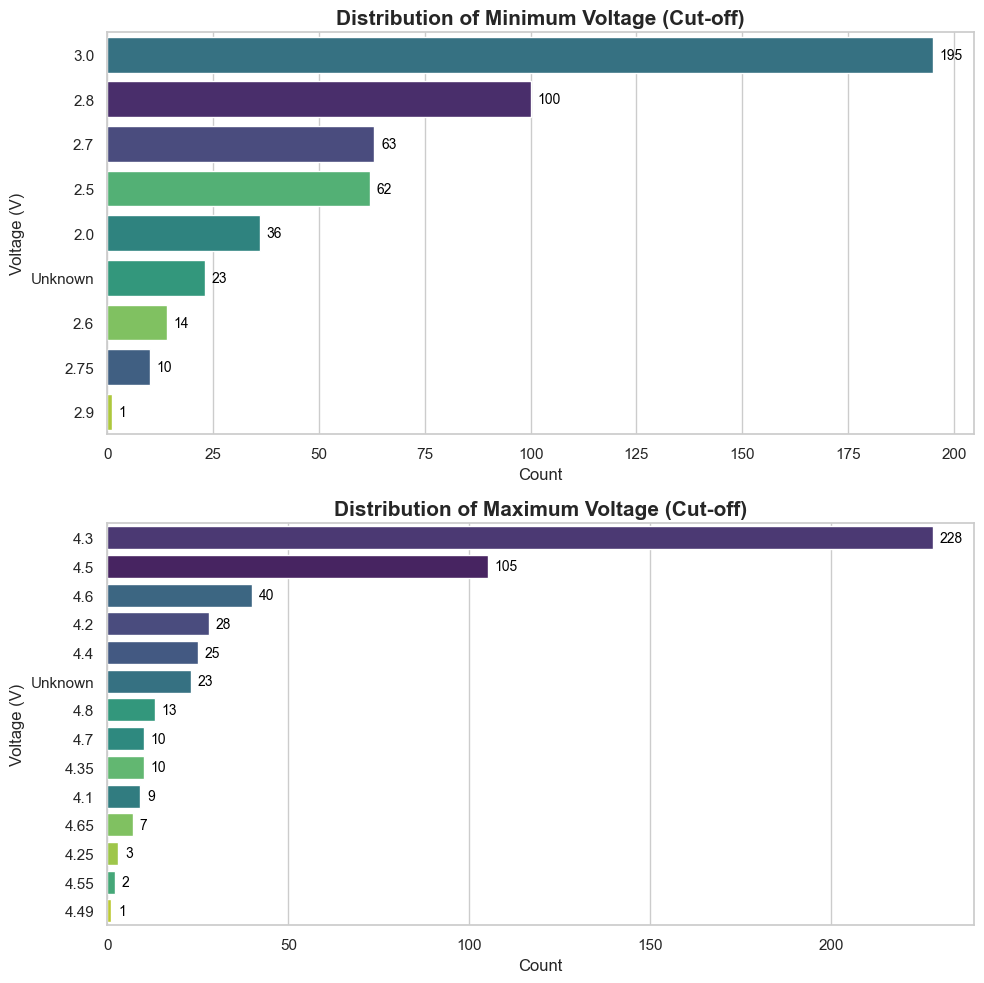

In [63]:
import pandas as pd
import re
from openpyxl import load_workbook
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 파일 불러오기 및 openpyxl 세팅
# ==========================================
file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
df = pd.read_excel(file_path)

target_col = "Voltage range"

wb = load_workbook(file_path, data_only=True)
ws = wb.active
headers = [cell.value for cell in ws[1]]
col_idx = headers.index(target_col) + 1

# ==========================================
# 2. Excel 날짜 변환 복원 및 Min/Max 분리 함수
# ==========================================
def parse_voltage(value):
    # A. 엑셀 날짜/시간 변환 복원 (예: 3월 4.5일(?) 등 기형적인 변환 방어)
    if isinstance(value, datetime.datetime):
        s = f"{value.month}-{value.day}"
    elif isinstance(value, datetime.time):
        s = f"{value.hour}-{value.minute}"
    else:
        s = str(value).lower() if pd.notna(value) else ""
        
    if s == "" or s == "nan":
        return None, None

    # B. 'to' 같은 글자를 하이픈(-)으로 변경 (예: "2.5 to 4.3" -> "2.5 - 4.3")
    s = s.replace('to', '-')
    
    # C. 거슬리는 알파벳(v, vs, li 등) 및 띄어쓰기 모조리 제거
    s = re.sub(r'[a-z\s]', '', s)
    
    # D. 물결표(~)나 긴 하이픈을 모두 기본 하이픈(-)으로 통일
    s = s.replace('~', '-').replace('–', '-')
    
    # E. 하이픈(-)을 기준으로 분리하여 Min, Max 추출
    parts = s.split('-')
    if len(parts) == 2:
        try:
            vmin = float(parts[0])
            vmax = float(parts[1])
            return vmin, vmax
        except ValueError:
            pass # 숫자로 변환 실패 시 넘어감
            
    return None, None # 형태가 맞지 않으면 None 반환

# ==========================================
# 3. 함수 적용 및 새로운 열 생성
# ==========================================
raw_values = [ws.cell(row=r, column=col_idx).value for r in range(2, ws.max_row + 1)]

# Min, Max 값을 각각 담을 리스트 생성
vmin_list, vmax_list = zip(*[parse_voltage(v) for v in raw_values])

# 데이터프레임에 새로운 열 추가
df['Voltage_min'] = vmin_list
df['Voltage_max'] = vmax_list

# ==========================================
# 4. 텍스트로 상위 분포 확인
# ==========================================
print("[전처리 완료: Voltage Min/Max 분포 확인]\n")
print("--- Voltage_min (하한 전압) ---")
print(df['Voltage_min'].value_counts(dropna=False).head(5))
print("-" * 30)
print("--- Voltage_max (상한 전압) ---")
print(df['Voltage_max'].value_counts(dropna=False).head(5))
print("-" * 30)

# ==========================================
# 5. 완벽한 디자인의 분포 시각화 (위아래 2개 그래프)
# ==========================================
plt.figure(figsize=(10, 10))
sns.set_theme(style="whitegrid")

plot_cols = ['Voltage_min', 'Voltage_max']
titles = ['Distribution of Minimum Voltage (Cut-off)', 
          'Distribution of Maximum Voltage (Cut-off)']

for i, col in enumerate(plot_cols, 1):
    plt.subplot(2, 1, i)
    
    # 결측치는 'Unknown'으로 표기하여 시각화 (문자열 변환)
    plot_data = df[col].fillna('Unknown').astype(str)
    
    # 데이터 종류가 너무 많을 경우 상위 15개만 추출 (깔끔한 시각화를 위해)
    top_order = plot_data.value_counts().index[:15]
    
    ax = sns.countplot(y=plot_data, 
                       hue=plot_data,
                       legend=False,
                       order=top_order, 
                       palette='viridis')
    
    # 막대 끝에 숫자(개수) 표시
    for container in ax.containers:
        ax.bar_label(container, padding=5, fontsize=10, color='black')
        
    plt.yticks(fontsize=11)
    plt.title(titles[i-1], fontsize=15, fontweight='bold')
    plt.xlabel('Count', fontsize=12)
    plt.ylabel('Voltage (V)', fontsize=12)

plt.tight_layout()
plt.show()

### Temperature

[전처리 완료: Temperature 분포 확인]

Cleaned Temperature
25.0       308
Unknown    116
20.0        33
30.0        27
28.0         6
55.0         5
27.0         5
26.0         2
45.0         2
Name: count, dtype: int64
----------------------------------------


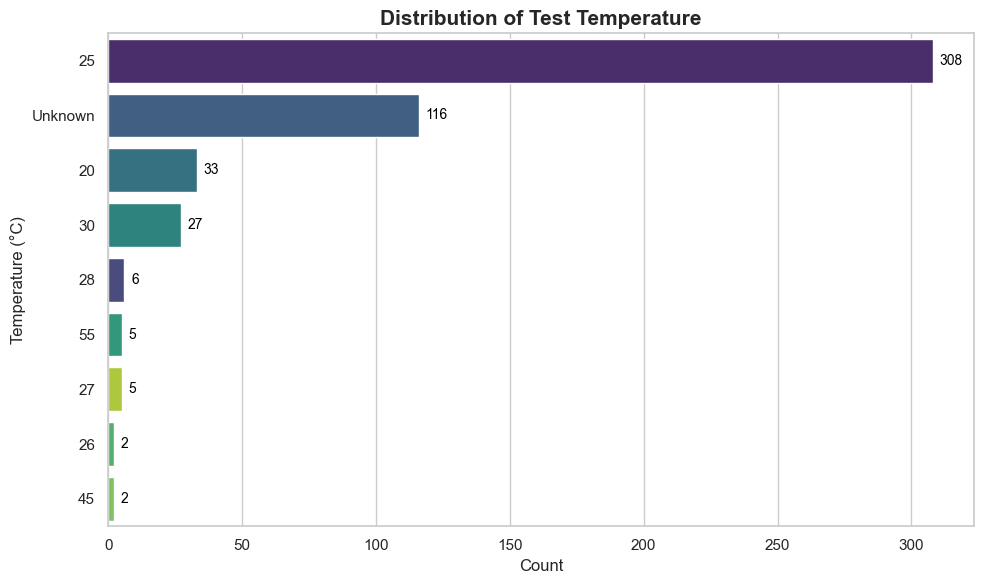

In [64]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Temperature 열 전처리 ('Room temperature' -> 25 등)
# ==========================================
# 결측치(NaN)를 'Unknown'으로 변환 후 소문자로 통일
temp_col = df['Temperature'].fillna('Unknown').astype(str).str.lower()

def clean_temperature(val):
    if val == 'unknown' or val == 'nan':
        return 'Unknown'
    
    # 상온(Room temperature, RT, Ambient)을 25로 변환
    if 'room' in val or 'rt' in val or 'ambient' in val:
        return 25.0
        
    # 정규표현식을 사용하여 숫자만 쏙 골라내기 (예: '25 °c' -> 25.0)
    nums = re.findall(r'\d+\.?\d*', val)
    if nums:
        return float(nums[0]) # 첫 번째로 찾은 숫자 반환
    else:
        return 'Unknown'

# 함수 적용 및 새로운 열 생성
df['Cleaned Temperature'] = temp_col.apply(clean_temperature)

# ==========================================
# 2. 텍스트로 상위 분포 확인
# ==========================================
print("[전처리 완료: Temperature 분포 확인]\n")
print(df['Cleaned Temperature'].value_counts(dropna=False).head(10))
print("-" * 40)

# ==========================================
# 3. 완벽한 디자인의 분포 시각화 (막대 값 표시)
# ==========================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 그래프에 표시하기 위해 다시 문자열로 변환 (예: 25.0 -> '25.0')
# 소수점 .0이 보기 싫으시다면 아래처럼 처리 가능합니다.
def format_label(val):
    if isinstance(val, float) and val.is_integer():
        return str(int(val))
    return str(val)

plot_data = df['Cleaned Temperature'].apply(format_label)

# 데이터 종류가 많을 수 있으므로 상위 15개만 추출
top_order = plot_data.value_counts().index[:15]

# 가로 막대, 빈도순 정렬, viridis 팔레트
ax = sns.countplot(y=plot_data, 
                   hue=plot_data,
                   legend=False,
                   order=top_order, 
                   palette='viridis')

# 막대 끝에 숫자(개수) 표시
for container in ax.containers:
    ax.bar_label(container, padding=5, fontsize=10, color='black')

plt.yticks(fontsize=11)
plt.title('Distribution of Test Temperature', fontsize=15, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

plt.tight_layout()
plt.show()

### capacity

[전처리 완료: C-rate별 데이터 개수 (상위 15개)]

C-rate 0.1      200
C-rate 1.0       88
C-rate 5.0       71
C-rate 0.2       70
C-rate 0.5       60
C-rate 10.0      42
C-rate 2.0       38
C-rate 0.05      24
C-rate 3.0       23
C-rate 20.0       9
C-rate 0.067      7
C-rate 0.125      7
C-rate 4.0        7
C-rate 6.0        6
C-rate 0.14       6
dtype: int64
----------------------------------------


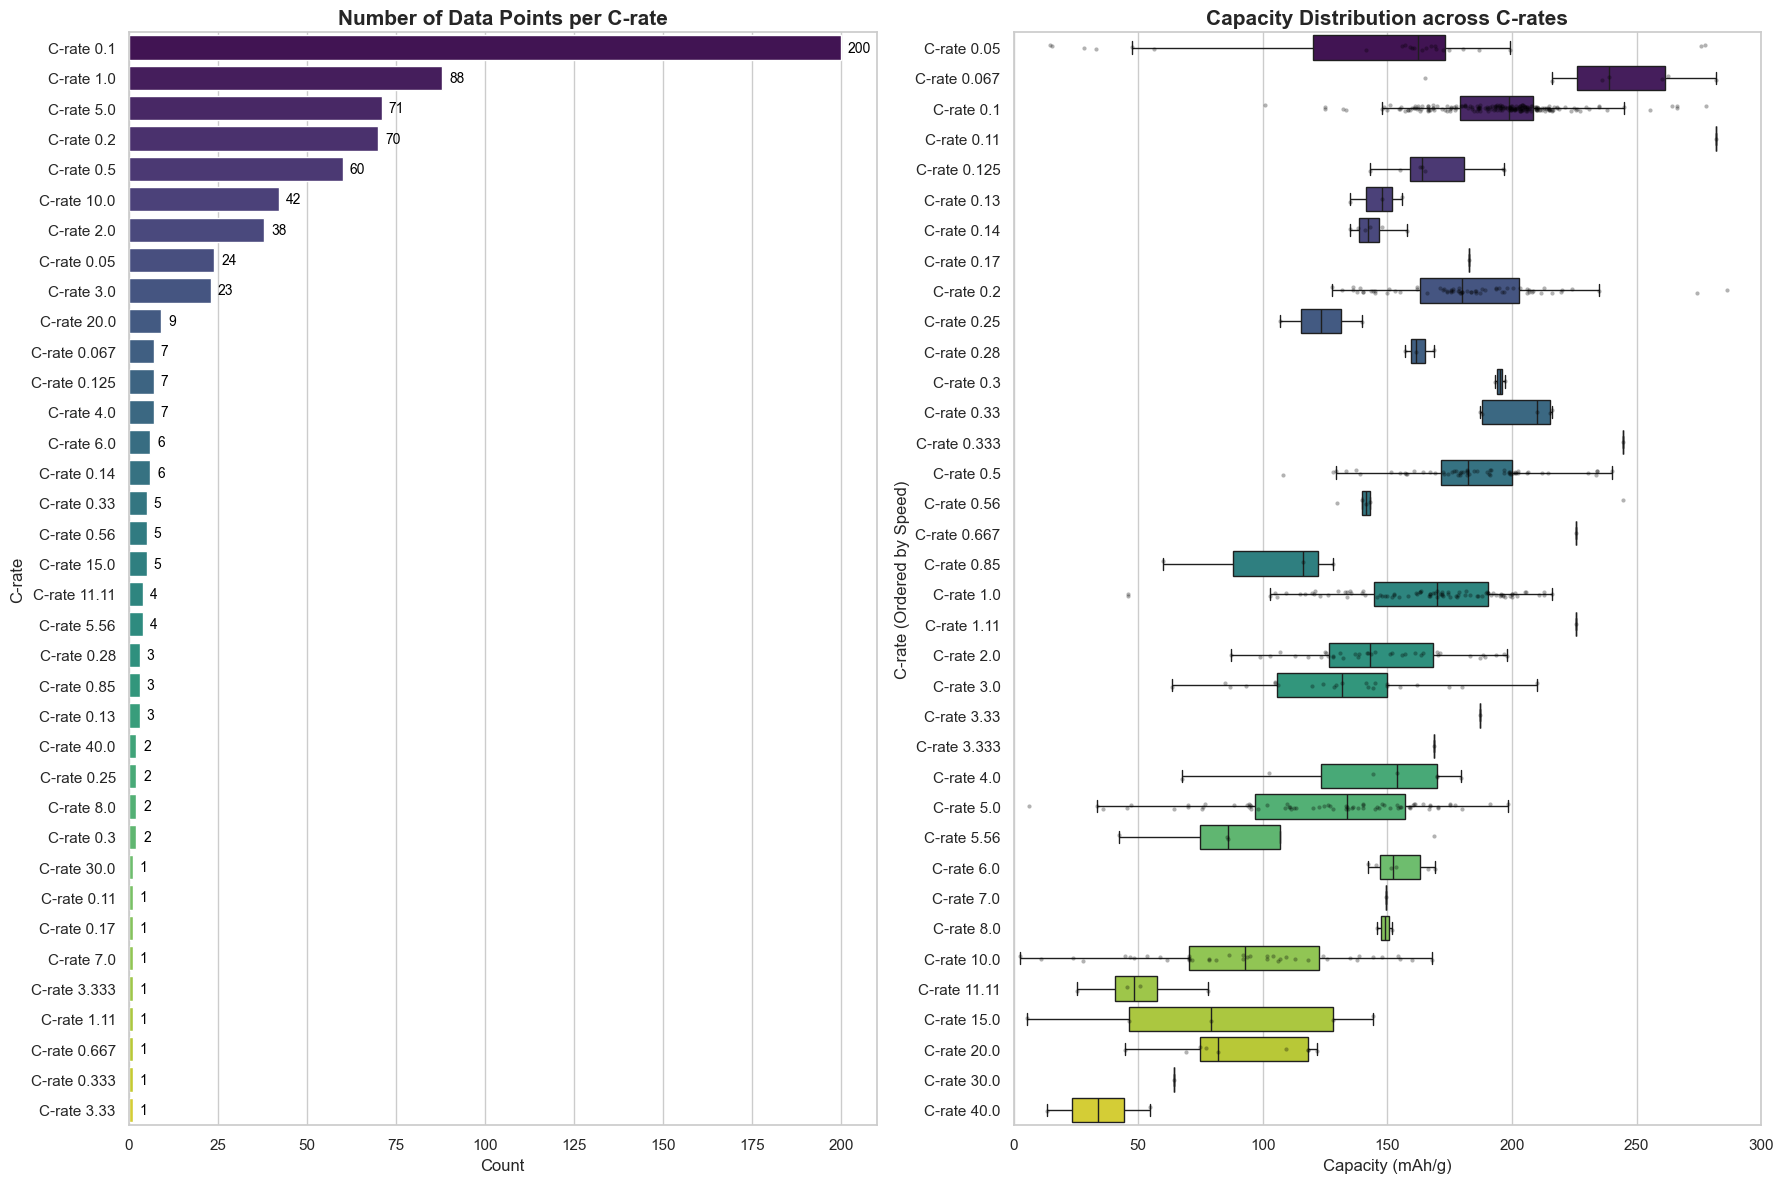

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 파일 불러오기 (df 정의 에러 해결!)
# ==========================================
file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
df = pd.read_excel(file_path)

# ==========================================
# 1. 대상 열 지정 및 수치형 데이터로 변환
# ==========================================
raw_c_rate_cols = [
    'C-rate 0.05', 'C-rate 0.067', 'C-rate 0.1', 'C-rate 0.11', 'C-rate 0.125', 
    'C-rate 0.13', 'C-rate 0.14', 'C-rate 0.17', 'C-rate 0.2', 'C-rate 0.25', 
    'C-rate 0.28', 'C-rate 0.3', 'C-rate 0.33', 'C-rate 0.333', 'C-rate 0.5', 
    'C-rate 0.56', 'C-rate 0.667', 'C-rate 0.85', 'C-rate 1.0', 'C-rate 1.11', 
    'C-rate 2.0', 'C-rate 3.0', 'C-rate 3.33', 'C-rate 3.333', 'C-rate 4.0', 
    'C-rate 5.0', 'C-rate 5.56', 'C-rate 6.0', 'C-rate 7.0', 'C-rate 8.0', 
    'C-rate 10.0', 'C-rate 11.11', 'C-rate 15.0', 'C-rate 20.0', 'C-rate 30.0', 'C-rate 40.0'
]

# 실제 데이터프레임에 존재하는 열만 안전하게 필터링
c_rate_cols = [col for col in raw_c_rate_cols if col in df.columns]

# 문자열이나 공백이 섞여 있을 수 있으므로 모두 순수한 숫자로 강제 변환
for col in c_rate_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

# ==========================================
# 2. 각 C-rate별 유효한 데이터(결측치 제외) 개수 파악
# ==========================================
counts = df[c_rate_cols].count().sort_values(ascending=False)

print("[전처리 완료: C-rate별 데이터 개수 (상위 15개)]\n")
print(counts.head(15))
print("-" * 40)

# ==========================================
# 3. 완벽한 디자인의 시각화 (개수 & 용량 분포)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 12)) # 가로로 2개의 그래프를 넓게 배치
sns.set_theme(style="whitegrid")

# --- 첫 번째 그래프: C-rate별 데이터 개수 (빈도순 정렬) ---
# 데이터가 1개 이상 존재하는 C-rate만 추출
valid_counts = counts[counts > 0]

ax1 = sns.barplot(x=valid_counts.values, y=valid_counts.index, 
                  palette='viridis', ax=axes[0], hue=valid_counts.index, legend=False)

for container in ax1.containers:
    ax1.bar_label(container, padding=5, fontsize=10, color='black')

axes[0].set_title('Number of Data Points per C-rate', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Count', fontsize=12)
axes[0].set_ylabel('C-rate', fontsize=12)

# --- 두 번째 그래프: C-rate별 용량(Capacity) 분포 (Boxplot) ---
# 과학적 분석을 위해 C-rate의 '숫자 크기순'으로 정렬 (0.05 -> 40.0)
def extract_rate(col_name):
    return float(col_name.replace('C-rate ', ''))

sorted_cols = sorted([col for col in c_rate_cols if counts[col] > 0], key=extract_rate)

# Boxplot을 그리기 위해 데이터를 세로로 길게 풀기(Melt)
melted_df = df[sorted_cols].melt(var_name='C-rate', value_name='Capacity').dropna()

ax2 = sns.boxplot(data=melted_df, x='Capacity', y='C-rate', 
                  palette='viridis', ax=axes[1], hue='C-rate', legend=False,
                  showfliers=False) # 이상치(outliers) 점은 깔끔함을 위해 숨김

# 박스플롯 위에 실제 데이터 점들을 흩뿌려서(Stripplot) 밀도 확인
sns.stripplot(data=melted_df, x='Capacity', y='C-rate', 
              color='black', alpha=0.3, size=3, ax=axes[1])

axes[1].set_title('Capacity Distribution across C-rates', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Capacity (mAh/g)', fontsize=12)
axes[1].set_ylabel('C-rate (Ordered by Speed)', fontsize=12)

axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

### Particle size

Particle size 전처리 완료

[selected_unit 분포]
selected_unit
None           273
μm             150
nm              57
qualitative     24
Name: count, dtype: int64

[unit_confidence 분포]
unit_confidence
None           273
inferred        99
explicit        86
qualitative     24
corrected       22
Name: count, dtype: int64

[particle_size_category 분포]
particle_size_category
None                     285
micro-medium (5-15μm)     81
nano (<0.5μm)             58
micro-small (1-5μm)       52
micro-large (15-25μm)     19
sub-micro (0.5-1μm)        8
macro (>25μm)              1
Name: count, dtype: int64

엑셀 저장 완료: particle_size_preprocessed_first_unit.xlsx


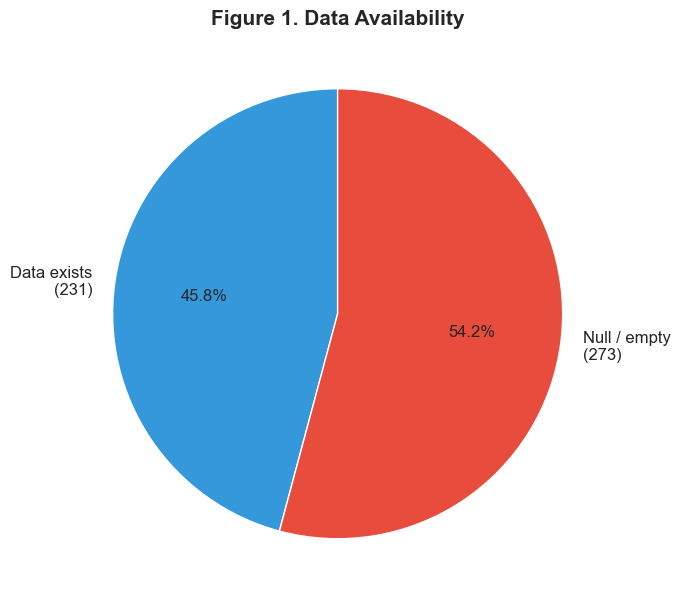

C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1146519466.py:772: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


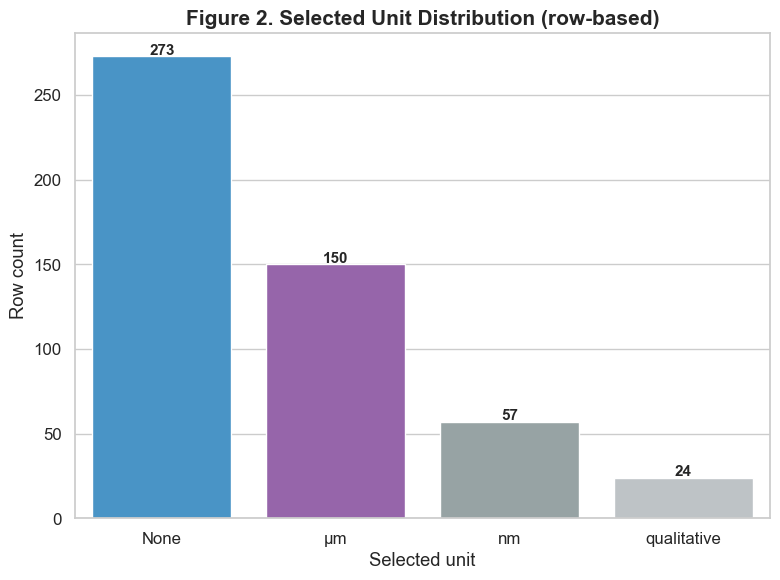

C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1146519466.py:795: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


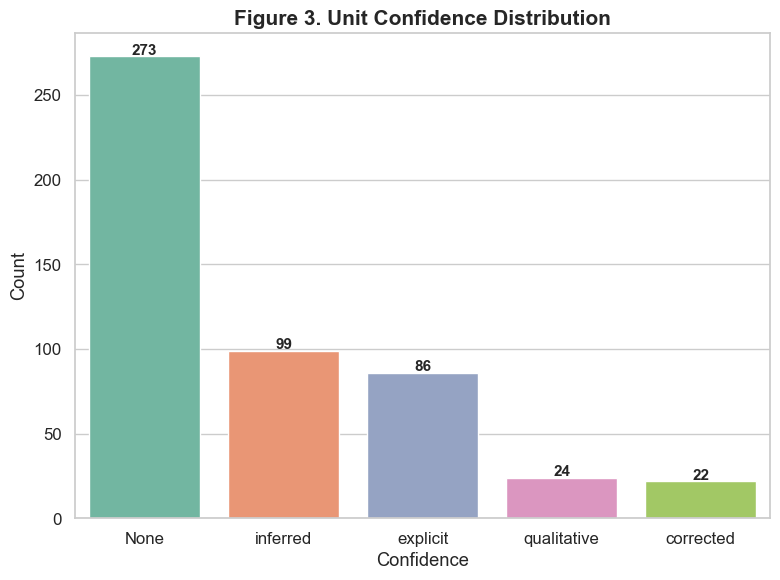

C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1146519466.py:818: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


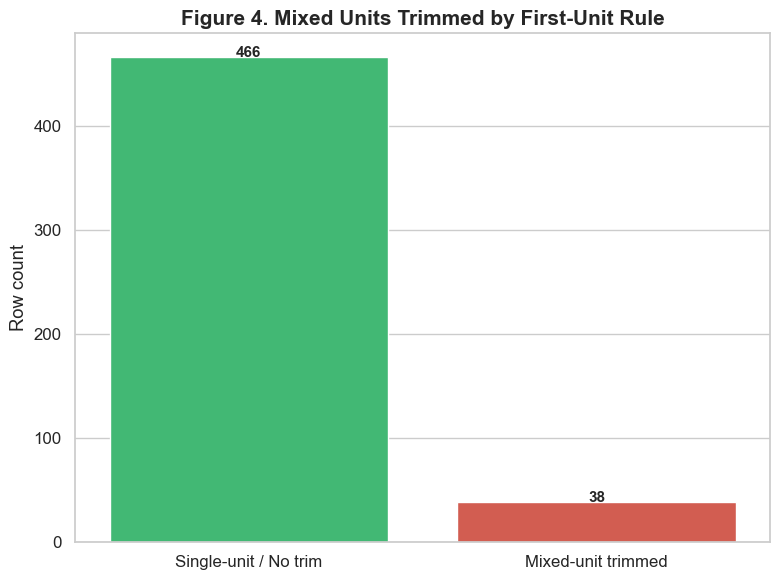

C:\Users\LECS\AppData\Local\Temp\ipykernel_30784\1146519466.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


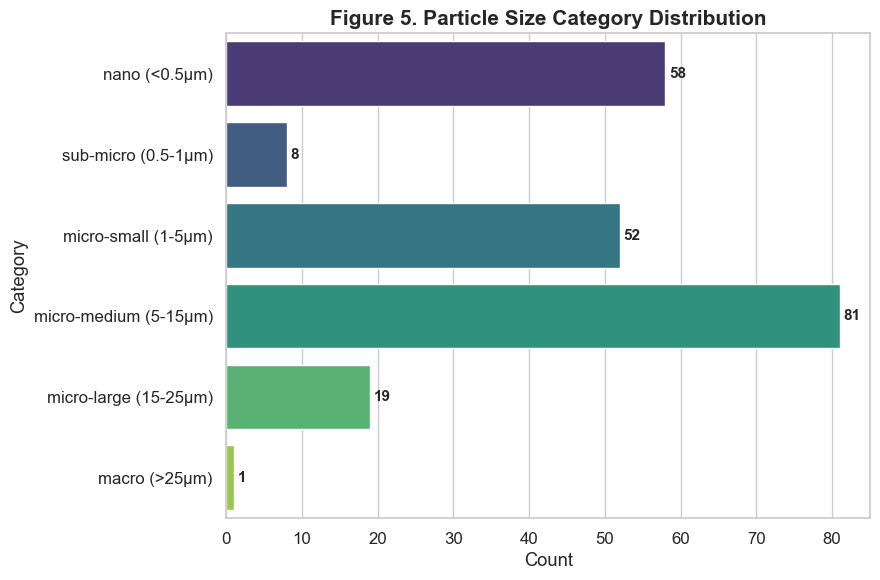

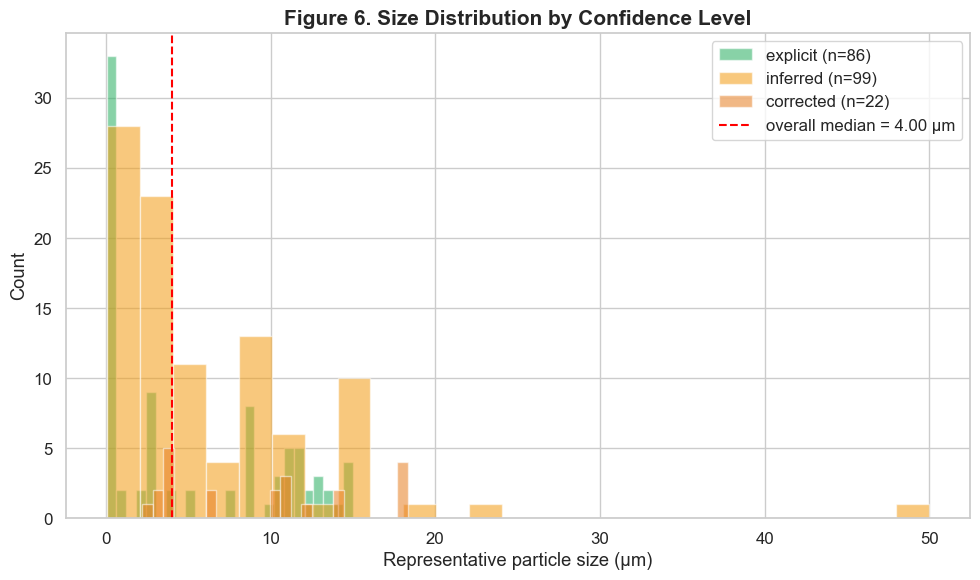

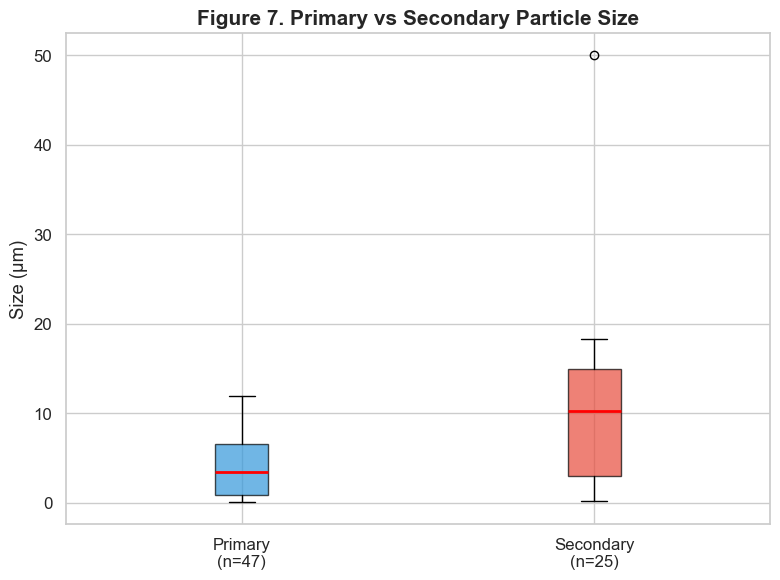

In [17]:
# ============================================================
# Particle size 전처리 + 7개 시각화 코드
# ------------------------------------------------------------
# 핵심 규칙
# 1) Excel이 날짜/과학표기법으로 망가뜨린 값 복구
# 2) 단위(nm / μm / mm)는 원래 있으면 보존
# 3) 단위가 없으면 NCM 도메인 지식으로 추론
# 4) 한 문장에 단위가 여러 개 나오면 "앞에 나온 첫 단위만 사용"
# 5) 결과를 엑셀로 저장
# 6) 총 7개 그래프 생성
# ============================================================

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from openpyxl import load_workbook
from datetime import datetime, time, timedelta


# ============================================================
# 0. 사용자 설정 영역
# ------------------------------------------------------------
# 아래 file_path만 네 파일 경로로 맞춰주면 됨
# ============================================================

file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
sheet_name = 0   # 첫 번째 시트
target_col = "Particle size"

# 결과 저장 파일명
output_excel = "particle_size_preprocessed_first_unit.xlsx"


# ============================================================
# 1. 원본 데이터 읽기
# ------------------------------------------------------------
# pandas로 전체 df를 읽고,
# openpyxl로 Particle size 원본 셀 값을 따로 읽음
# (이유: Excel이 날짜/시간/과학표기법으로 망가뜨린 값을 복구해야 하기 때문)
# ============================================================

# 전체 데이터프레임 읽기
df = pd.read_excel(file_path, sheet_name=sheet_name)

# openpyxl로 원본 워크북 열기
wb = load_workbook(file_path, data_only=True)
ws = wb[wb.sheetnames[sheet_name if isinstance(sheet_name, int) else 0]]

# 헤더(열 이름) 찾기
headers = [cell.value for cell in ws[1]]

# Particle size 열 위치 찾기
col_idx = headers.index(target_col) + 1

# Paper ID 열도 같이 가져오면 나중에 추적하기 쉬움
paper_id_idx = headers.index("Paper ID") + 1

# Particle size 원본 값 / Paper ID 원본 값 읽기
raw_values = [ws.cell(row=r, column=col_idx).value for r in range(2, ws.max_row + 1)]
paper_ids = [ws.cell(row=r, column=paper_id_idx).value for r in range(2, ws.max_row + 1)]


# ============================================================
# 2. Excel 오염 복구 함수
# ------------------------------------------------------------
# 예:
#   "3-5"  -> Excel이 날짜로 바꿔서 datetime(2026, 3, 5)
#   "5-25" -> Excel이 5e+25 같은 과학표기법으로 바꿈
# 이런 걸 다시 문자열로 복구
# ============================================================

def restore_corrupted_value(value):
    """
    Excel이 자동 변환해버린 값을 최대한 원래 의미에 가깝게 복구한다.
    """

    # None이면 그대로 None
    if value is None:
        return None

    # NaN이면 None 처리
    if isinstance(value, float) and math.isnan(value):
        return None

    # 예: "3-5" -> datetime(2026, 3, 5) 로 잘못 바뀐 경우
    if isinstance(value, datetime):
        return f"{value.month}-{value.day}"

    # 혹시 time 타입이면 문자열로 복구
    if isinstance(value, time):
        return f"{value.hour}:{value.minute}"

    # 혹시 timedelta 타입이면 문자열로 복구
    if isinstance(value, timedelta):
        total_seconds = int(round(value.total_seconds()))
        hour = total_seconds // 3600
        minute = (total_seconds % 3600) // 60
        second = total_seconds % 60
        return f"{hour}:{minute}:{second}"

    # 예: 5e+25 -> 원래 "5-25"였을 가능성 높음
    if isinstance(value, float) and value > 1e10:
        sci_text = f"{value:.0e}"  # 예: '5e+25'
        match = re.match(r"(\d+)e\+(\d+)", sci_text)
        if match:
            return f"{match.group(1)}-{match.group(2)}"
        return str(value)

    # 일반 숫자는 문자열로 바꿈
    if isinstance(value, (int, float)):
        return str(value)

    # 이미 문자열이면 앞뒤 공백 제거
    return str(value).strip()


# ============================================================
# 3. 텍스트 정규화 함수
# ------------------------------------------------------------
# 논문 텍스트에서 특수 대시, e 표기 등을 통일
# 예:
#   200e300 -> 200~300
#   5e 20   -> 5~20
# ============================================================

def normalize_text(text):
    if text is None:
        return None

    text = str(text)

    # 논문에서 range 구분자로 e를 쓰는 경우를 ~로 바꿈
    # 예: 200e300 -> 200~300
    text = re.sub(r'(\d+\.?\d*)\s*e\s*(\d+\.?\d+)', r'\1~\2', text)
    text = re.sub(r'(\d{2,})\s*e\s*(\d{2,})', r'\1~\2', text)
    text = re.sub(r'(\d+)\s*e\s+(\d+)', r'\1~\2', text)

    # 특수 기호 통일
    text = text.replace('−', '-').replace('–', '-').replace('—', '-')
    text = text.replace('∼', '~').replace('≈', '~')

    return text


# ============================================================
# 4. 단위 관련 함수
# ------------------------------------------------------------
# 명시 단위 감지:
#   nm, μm, um, µm, mm, micron 등
# ============================================================

UNIT_RE = re.compile(
    r'(nm|μm|µm|um|mm|micron|micro[\s\-]?m(?:eter|etre)?|nano[\s\-]?m(?:eter|etre)?)',
    re.IGNORECASE
)

# 범위 패턴
# 예: 3-5 μm / 200~300 nm / 1 to 2
RANGE_PAT = re.compile(
    r'(?:(?:between|from)\s*)?'
    r'(?P<v1>\d+\.?\d*)\s*'
    r'(?:-|~|to|and)\s*'
    r'(?:(?:about|around|approx\.?|approximately)\s*)?'
    r'(?P<v2>\d+\.?\d*)\s*'
    r'(?P<unit>nm|μm|µm|um|mm|micron)?',
    re.IGNORECASE
)

# 단일 숫자 패턴
# 예: 10 μm / 145 / 0.4
SINGLE_PAT = re.compile(
    r'(?P<val>\d+\.?\d*)\s*(?P<unit>nm|μm|µm|um|mm|micron)?',
    re.IGNORECASE
)


def normalize_unit(unit_text):
    """
    다양한 단위 표기를 표준화해서
    nm / μm / mm 중 하나로 맞춘다.
    """
    if not unit_text:
        return None

    unit_text = unit_text.lower().replace("µ", "μ")

    if unit_text == "nm" or "nanom" in unit_text:
        return "nm"

    if unit_text in ("μm", "um", "micron") or "microm" in unit_text:
        return "μm"

    if unit_text == "mm":
        return "mm"

    return None


def detect_explicit_units_in_order(text):
    """
    문장 안에서 '명시된 단위'를 등장 순서대로 찾는다.
    예:
      '11.7 μm ... 170 to 230 nm'
      -> [(pos1, 'μm'), (pos2, 'nm')]
    """
    units = []

    if not text:
        return units

    for m in UNIT_RE.finditer(text):
        unit = normalize_unit(m.group(1))
        if unit:
            units.append((m.start(), unit))

    return units


def extract_number_entries_in_order(text):
    """
    문장에서 숫자들을 순서대로 추출한다.
    범위는 2개 숫자로 나눠서 넣는다.

    반환 예시:
    [
      {'pos': 10, 'value': 11.7, 'explicit_unit': 'μm'},
      {'pos': 40, 'value': 170, 'explicit_unit': 'nm'},
      {'pos': 41, 'value': 230, 'explicit_unit': 'nm'},
    ]
    """
    if not text:
        return []

    text = normalize_text(text)
    entries = []
    used_spans = []

    # 1) 범위를 먼저 추출
    for m in RANGE_PAT.finditer(text):
        v1 = float(m.group("v1"))
        v2 = float(m.group("v2"))
        unit = normalize_unit(m.group("unit"))

        entries.append({
            "pos": m.start(),
            "value": v1,
            "explicit_unit": unit,
            "raw_span": m.group(0)
        })
        entries.append({
            "pos": m.start() + 0.001,   # 순서 유지용
            "value": v2,
            "explicit_unit": unit,
            "raw_span": m.group(0)
        })

        used_spans.append((m.start(), m.end()))

    # 2) 단일 숫자 추출
    for m in SINGLE_PAT.finditer(text):
        # 이미 범위에서 잡힌 부분이면 스킵
        overlapped = False
        for s, e in used_spans:
            if s <= m.start() < e:
                overlapped = True
                break

        if overlapped:
            continue

        value = float(m.group("val"))
        unit = normalize_unit(m.group("unit"))

        entries.append({
            "pos": m.start(),
            "value": value,
            "explicit_unit": unit,
            "raw_span": m.group(0)
        })

    # 순서대로 정렬
    entries = sorted(entries, key=lambda x: x["pos"])
    return entries


# ============================================================
# 5. 단위 추론 함수
# ------------------------------------------------------------
# 단위 없는 숫자에 대해 NCM cathode 도메인 지식으로 추론
#
# 규칙:
#   value >= 100   -> nm
#   1 <= value <100 -> μm
#   value < 1      -> μm
# ============================================================

def infer_unit_for_value(value, text_context=None):
    """
    단위 없는 숫자에 대해 도메인 지식으로 단위를 추론한다.
    """
    if value is None:
        return None, "unknown"

    context = (text_context or "").lower()

    is_primary_context = bool(re.search(
        r'primary|grain|crystallite|crystal\s*grain|nano', context
    ))

    is_secondary_context = bool(re.search(
        r'secondary|sphere|agglomerat|aggregat', context
    ))

    # 100 이상이면 보통 nm
    if value >= 100:
        return "nm", "inferred: value≥100 → nm"

    # 1 이상 100 미만이면 보통 μm
    if 1 <= value < 100:
        note = "inferred: 1≤value<100 → μm"
        if is_secondary_context:
            note += " (secondary context)"
        elif is_primary_context:
            note += " (primary/single-crystal context)"
        return "μm", note

    # 1 미만이면 보통 μm 표기의 sub-micron
    if value < 1:
        return "μm", "inferred: value<1 → μm (sub-micron notation)"

    return None, "unknown"


def correct_mm_if_needed(value, detected_unit):
    """
    mm는 NCM 문헌에서 오타인 경우가 많아서 보정.
    예: 10 mm -> 실제론 10 μm일 가능성이 큼
    """
    if detected_unit != "mm":
        return detected_unit, "explicit"

    if value < 100:
        return "μm", "corrected: mm→μm (likely typo in NCM literature)"

    return "mm", "explicit_suspicious: mm with very large value"


def convert_to_um(value, unit):
    """
    최종 단위를 μm 기준 숫자로 변환
    """
    if value is None or unit is None:
        return None

    if unit == "nm":
        return value / 1000.0

    if unit == "μm":
        return value

    if unit == "mm":
        return value * 1000.0

    return None


# ============================================================
# 6. qualitative 텍스트 처리 함수
# ------------------------------------------------------------
# 숫자가 없는 경우:
#   nano-sized -> nano
#   micrometer-sized -> micro-medium
#   micro-particles -> micro-small
#   submicron -> sub-micro
#
# 단, 실제 수치(size_um)는 넣지 않고 category만 부여
# ============================================================

def qualitative_category_from_first_keyword(text):
    if not text:
        return None

    text = text.lower()

    candidates = []

    patterns = [
        (r'submicron|sub-micro|submicro', 'sub-micro (0.5-1μm)'),
        (r'nano[\s-]?sized|nanoscale|nanomet|nano\b', 'nano (<0.5μm)'),
        (r'micro[\s-]?particles?', 'micro-small (1-5μm)'),
        (r'micrometer|micrometre|micron|micro[\s-]?sized|microsized', 'micro-medium (5-15μm)'),
    ]

    for pat, category in patterns:
        m = re.search(pat, text)
        if m:
            candidates.append((m.start(), category))

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: x[0])
    return candidates[0][1]


def detect_primary_secondary(text):
    """
    문장 안에 primary / secondary particle 관련 키워드가 있는지 확인
    """
    if not text:
        return False, False

    text = text.lower()

    has_primary = bool(re.search(
        r'primary|grain|crystallite|crystal\s*grain|nano[\s-]?sized|nanoscale|nanomet',
        text
    ))

    has_secondary = bool(re.search(
        r'secondary|sphere|agglomerat|aggregat|micro[\s-]?sized|micrometre|micrometer',
        text
    ))

    return has_primary, has_secondary


# ============================================================
# 7. size_um -> category 함수
# ============================================================

def assign_size_category(size_um):
    if size_um is None or (isinstance(size_um, float) and math.isnan(size_um)):
        return None

    if size_um < 0.5:
        return "nano (<0.5μm)"
    elif size_um < 1:
        return "sub-micro (0.5-1μm)"
    elif size_um < 5:
        return "micro-small (1-5μm)"
    elif size_um < 15:
        return "micro-medium (5-15μm)"
    elif size_um < 25:
        return "micro-large (15-25μm)"
    else:
        return "macro (>25μm)"


# ============================================================
# 8. 메인 전처리 루프
# ------------------------------------------------------------
# 핵심:
#   한 행에 여러 단위가 있어도
#   "앞에 나온 첫 단위만 사용"
# ============================================================

records = []

for i, raw_value in enumerate(raw_values):
    restored_text = restore_corrupted_value(raw_value)
    paper_id = paper_ids[i]

    record = {
        "Paper ID": paper_id,
        "restored_text": restored_text,
        "has_data": restored_text is not None,
    }

    # 값 자체가 없는 경우
    if restored_text is None:
        record.update({
            "detected_units_all": None,
            "selected_unit": None,
            "unit_confidence": None,
            "confidence_detail": None,
            "mixed_units_found": False,
            "discarded_units": None,
            "raw_value_min": None,
            "raw_value_max": None,
            "raw_value_repr": None,
            "size_um": None,
            "particle_size_category": None,
            "has_primary_info": False,
            "has_secondary_info": False,
            "primary_size_avg_um": None,
            "secondary_size_avg_um": None,
        })
        records.append(record)
        continue

    text = normalize_text(restored_text)

    # primary / secondary 키워드 감지
    has_primary, has_secondary = detect_primary_secondary(text)

    # 문장 안에 명시된 단위들을 순서대로 찾기
    explicit_units_in_order = detect_explicit_units_in_order(text)
    explicit_units_only = [u for _, u in explicit_units_in_order]

    # 문장 안에서 명시된 단위 전체 목록
    unique_units_in_order = list(dict.fromkeys(explicit_units_only))
    detected_units_all = ", ".join(unique_units_in_order) if unique_units_in_order else None

    # 숫자 추출
    entries = extract_number_entries_in_order(text)

    # 숫자가 아예 없으면 qualitative 처리
    if len(entries) == 0:
        record.update({
            "detected_units_all": "qualitative",
            "selected_unit": "qualitative",
            "unit_confidence": "qualitative",
            "confidence_detail": "no numeric value found",
            "mixed_units_found": False,
            "discarded_units": None,
            "raw_value_min": None,
            "raw_value_max": None,
            "raw_value_repr": None,
            "size_um": None,
            "particle_size_category": qualitative_category_from_first_keyword(text),
            "has_primary_info": has_primary,
            "has_secondary_info": has_secondary,
            "primary_size_avg_um": None,
            "secondary_size_avg_um": None,
        })
        records.append(record)
        continue

    # --------------------------------------------------------
    # 각 숫자에 대해 단위를 결정
    # --------------------------------------------------------
    resolved_entries = []

    for entry in entries:
        value = entry["value"]
        explicit_unit = entry["explicit_unit"]

        # 1) 숫자 바로 옆에 명시 단위가 있으면 그걸 사용
        if explicit_unit is not None:
            final_unit, confidence = correct_mm_if_needed(value, explicit_unit)
            size_um = convert_to_um(value, final_unit)

            resolved_entries.append({
                "pos": entry["pos"],
                "value": value,
                "detected_unit": explicit_unit,
                "final_unit": final_unit,
                "confidence": confidence,
                "size_um": size_um,
                "raw_span": entry["raw_span"],
            })

        # 2) 숫자 바로 옆에 단위가 없으면 도메인 추론
        else:
            inferred_unit, confidence = infer_unit_for_value(value, text)
            size_um = convert_to_um(value, inferred_unit) if inferred_unit else None

            resolved_entries.append({
                "pos": entry["pos"],
                "value": value,
                "detected_unit": "none",
                "final_unit": inferred_unit,
                "confidence": confidence,
                "size_um": size_um,
                "raw_span": entry["raw_span"],
            })

    # 유효한 값만 남김
    valid_entries = [
        x for x in resolved_entries
        if x["final_unit"] is not None
        and x["size_um"] is not None
        and 0 < x["size_um"] < 500
    ]

    # 유효한 값이 없으면
    if len(valid_entries) == 0:
        record.update({
            "detected_units_all": detected_units_all if detected_units_all else "none",
            "selected_unit": "unknown",
            "unit_confidence": "unknown",
            "confidence_detail": "; ".join(sorted(set([x["confidence"] for x in resolved_entries])))[:200],
            "mixed_units_found": False,
            "discarded_units": None,
            "raw_value_min": None,
            "raw_value_max": None,
            "raw_value_repr": ", ".join([str(x["value"]) for x in resolved_entries[:6]]),
            "size_um": None,
            "particle_size_category": qualitative_category_from_first_keyword(text),
            "has_primary_info": has_primary,
            "has_secondary_info": has_secondary,
            "primary_size_avg_um": None,
            "secondary_size_avg_um": None,
        })
        records.append(record)
        continue

    # --------------------------------------------------------
    # 핵심 규칙:
    # "앞에 나온 첫 단위만 사용"
    # --------------------------------------------------------
    selected_unit = valid_entries[0]["final_unit"]

    kept_entries = [x for x in valid_entries if x["final_unit"] == selected_unit]
    discarded_entries = [x for x in valid_entries if x["final_unit"] != selected_unit]

    mixed_units_found = len(set([x["final_unit"] for x in valid_entries])) > 1
    discarded_units = ", ".join(sorted(set([x["final_unit"] for x in discarded_entries]))) if discarded_entries else None

    kept_raw_values = [x["value"] for x in kept_entries]
    kept_um_values = [x["size_um"] for x in kept_entries]
    kept_confidences = [x["confidence"] for x in kept_entries]

    # row-level confidence 정리
    if all(c == "explicit" for c in kept_confidences):
        row_confidence = "explicit"
    elif any("corrected" in c for c in kept_confidences):
        row_confidence = "corrected"
    elif any("inferred" in c for c in kept_confidences):
        row_confidence = "inferred"
    else:
        row_confidence = "unknown"

    # primary / secondary 평균 계산
    primary_um = []
    secondary_um = []

    if has_primary and has_secondary and len(kept_um_values) >= 2:
        # 둘 다 있으면 작은 값 쪽을 primary, 큰 값 쪽을 secondary로 나눔
        sorted_values = sorted(kept_um_values)
        mid = len(sorted_values) // 2
        primary_um = sorted_values[:mid]
        secondary_um = sorted_values[mid:]
    elif has_primary and not has_secondary:
        primary_um = kept_um_values
    elif has_secondary and not has_primary:
        secondary_um = kept_um_values

    # 대표값:
    # secondary 값이 있으면 secondary 평균을 대표값으로,
    # 없으면 전체 평균 사용
    if len(secondary_um) > 0:
        representative_size = np.mean(secondary_um)
    else:
        representative_size = np.mean(kept_um_values)

    record.update({
        "detected_units_all": detected_units_all if detected_units_all else ", ".join(list(dict.fromkeys([x["detected_unit"] for x in resolved_entries]))),
        "selected_unit": selected_unit,
        "unit_confidence": row_confidence,
        "confidence_detail": "; ".join(sorted(set(kept_confidences)))[:200],
        "mixed_units_found": mixed_units_found,
        "discarded_units": discarded_units,
        "raw_value_min": round(min(kept_raw_values), 4),
        "raw_value_max": round(max(kept_raw_values), 4),
        "raw_value_repr": ", ".join([str(v) for v in kept_raw_values[:6]]),
        "size_um": round(representative_size, 4),
        "particle_size_category": assign_size_category(representative_size),
        "has_primary_info": has_primary,
        "has_secondary_info": has_secondary,
        "primary_size_avg_um": round(np.mean(primary_um), 4) if len(primary_um) > 0 else None,
        "secondary_size_avg_um": round(np.mean(secondary_um), 4) if len(secondary_um) > 0 else None,
    })

    records.append(record)


# 결과 데이터프레임 만들기
result_df = pd.DataFrame(records)

# 원본 df와 합치기
merge_cols = [c for c in result_df.columns if c != "Paper ID"]
df_final = pd.concat([df, result_df[merge_cols]], axis=1)


# ============================================================
# 9. 전처리 결과 간단 확인
# ============================================================

print("=" * 70)
print("Particle size 전처리 완료")
print("=" * 70)

print("\n[selected_unit 분포]")
print(df_final["selected_unit"].value_counts(dropna=False))

print("\n[unit_confidence 분포]")
print(df_final["unit_confidence"].value_counts(dropna=False))

print("\n[particle_size_category 분포]")
print(df_final["particle_size_category"].value_counts(dropna=False))


# ============================================================
# 10. 엑셀 저장
# ------------------------------------------------------------
# preprocessed 시트 + rule 설명 시트 저장
# ============================================================

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    df_final.to_excel(writer, sheet_name="preprocessed", index=False)

    rule_df = pd.DataFrame({
        "rule": ["R1", "R2", "R3", "R4", "R5", "R6"],
        "description": [
            "한 행에 단위가 여러 개 있으면 앞에 나온 첫 단위만 사용",
            "명시 단위가 nm이면 nm 사용",
            "명시 단위가 μm이면 μm 사용",
            "명시 단위가 mm이고 값<100이면 μm로 보정",
            "단위 없고 값>=100이면 nm 추론",
            "단위 없고 값<100이면 μm 추론",
        ],
        "confidence": [
            "selection_rule",
            "explicit",
            "explicit",
            "corrected",
            "inferred",
            "inferred",
        ]
    })
    rule_df.to_excel(writer, sheet_name="rules", index=False)

print(f"\n엑셀 저장 완료: {output_excel}")


# ============================================================
# 11. 시각화 설정
# ============================================================

sns.set_theme(style="whitegrid", font_scale=1.1)

# 자주 쓰는 값 계산
total_rows = len(df_final)
has_data_count = int(df_final["has_data"].sum())
null_count = total_rows - has_data_count


# ============================================================
# Figure 1. Data Availability
# ============================================================

plt.figure(figsize=(7, 7))
plt.pie(
    [has_data_count, null_count],
    labels=[f"Data exists\n({has_data_count})", f"Null / empty\n({null_count})"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#3498db", "#e74c3c"],
    textprops={"fontsize": 12}
)
plt.title("Figure 1. Data Availability", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2. Selected Unit Distribution
# ------------------------------------------------------------
# row 기준!
# 이제 합이 231(data exists 개수)와 맞아야 함
# ============================================================

selected_unit_counts = df_final["selected_unit"].fillna("None").value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=selected_unit_counts.index,
    y=selected_unit_counts.values,
    palette=["#3498db", "#9b59b6", "#95a5a6", "#bdc3c7"][:len(selected_unit_counts)]
)

for i, v in enumerate(selected_unit_counts.values):
    plt.text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="bold")

plt.title("Figure 2. Selected Unit Distribution (row-based)", fontsize=15, fontweight="bold")
plt.ylabel("Row count")
plt.xlabel("Selected unit")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3. Unit Confidence Distribution
# ============================================================

confidence_counts = df_final["unit_confidence"].fillna("None").value_counts()

plt.figure(figsize=(8, 6))
sns.barplot(
    x=confidence_counts.index,
    y=confidence_counts.values,
    palette="Set2"
)

for i, v in enumerate(confidence_counts.values):
    plt.text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="bold")

plt.title("Figure 3. Unit Confidence Distribution", fontsize=15, fontweight="bold")
plt.ylabel("Count")
plt.xlabel("Confidence")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 4. Mixed Units Trimmed by First-Unit Rule
# ============================================================

mixed_counts = df_final["mixed_units_found"].fillna(False).value_counts().reindex([False, True], fill_value=0)

plt.figure(figsize=(8, 6))
sns.barplot(
    x=["Single-unit / No trim", "Mixed-unit trimmed"],
    y=mixed_counts.values,
    palette=["#2ecc71", "#e74c3c"]
)

for i, v in enumerate(mixed_counts.values):
    plt.text(i, v + 1, str(v), ha="center", fontsize=11, fontweight="bold")

plt.title("Figure 4. Mixed Units Trimmed by First-Unit Rule", fontsize=15, fontweight="bold")
plt.ylabel("Row count")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5. Particle Size Category Distribution
# ============================================================

category_order = [
    "nano (<0.5μm)",
    "sub-micro (0.5-1μm)",
    "micro-small (1-5μm)",
    "micro-medium (5-15μm)",
    "micro-large (15-25μm)",
    "macro (>25μm)"
]

category_counts = (
    df_final["particle_size_category"]
    .dropna()
    .value_counts()
    .reindex(category_order, fill_value=0)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    y=category_counts.index,
    x=category_counts.values,
    palette="viridis"
)

for i, v in enumerate(category_counts.values):
    if v > 0:
        plt.text(v + 0.5, i, str(v), va="center", fontsize=11, fontweight="bold")

plt.title("Figure 5. Particle Size Category Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6. Size Distribution by Confidence Level
# ------------------------------------------------------------
# explicit / inferred / corrected 별로 histogram
# qualitative는 숫자 size_um이 없어서 제외됨
# ============================================================

plt.figure(figsize=(10, 6))

for confidence, color in [
    ("explicit", "#27ae60"),
    ("inferred", "#f39c12"),
    ("corrected", "#e67e22"),
]:
    subset = df_final.loc[df_final["unit_confidence"] == confidence, "size_um"].dropna()

    if len(subset) > 0:
        plt.hist(
            subset,
            bins=25,
            alpha=0.55,
            label=f"{confidence} (n={len(subset)})",
            color=color,
            edgecolor="white"
        )

# 전체 중앙값 표시
all_size_um = df_final["size_um"].dropna()
if len(all_size_um) > 0:
    plt.axvline(
        all_size_um.median(),
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"overall median = {all_size_um.median():.2f} μm"
    )

plt.title("Figure 6. Size Distribution by Confidence Level", fontsize=15, fontweight="bold")
plt.xlabel("Representative particle size (μm)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# Figure 7. Primary vs Secondary Particle Size
# ------------------------------------------------------------
# primary / secondary 평균 크기 boxplot
# ============================================================

primary_values = df_final["primary_size_avg_um"].dropna().tolist()
secondary_values = df_final["secondary_size_avg_um"].dropna().tolist()

plot_data = []
plot_labels = []

if len(primary_values) > 0:
    plot_data.append(primary_values)
    plot_labels.append(f"Primary\n(n={len(primary_values)})")

if len(secondary_values) > 0:
    plot_data.append(secondary_values)
    plot_labels.append(f"Secondary\n(n={len(secondary_values)})")

plt.figure(figsize=(8, 6))

if len(plot_data) > 0:
    box = plt.boxplot(
        plot_data,
        tick_labels=plot_labels,
        patch_artist=True,
        medianprops=dict(color="red", linewidth=2)
    )

    # 색 지정
    colors = ["#3498db", "#e74c3c"]
    for patch, color in zip(box["boxes"], colors[:len(box["boxes"])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

plt.title("Figure 7. Primary vs Secondary Particle Size", fontsize=15, fontweight="bold")
plt.ylabel("Size (μm)")
plt.tight_layout()
plt.show()


### Particle shape

Particle size 전처리 완료!
  size_um 있는 행: 207

Particle shape 전처리 완료!
  shape_category 있는 행: 258

[shape_category 분포]
shape_category
None              246
spherical         138
other              59
polyhedral         18
rod/bar            13
irregular          10
granular            6
single-crystal      6
plate               5
ellipsoidal         2
hollow              1

[surface_quality 분포]
surface_quality
not_mentioned    422
rough             38
smooth            32
porous            10
cracked            2

  통합 분석 (size × shape)
전체 행: 504
size 있음: 207
shape 있음: 258
둘 다 있음: 172

[shape_category별 size_um 통계]
                count   mean  median   std    min    max
shape_category                                          
spherical         103   7.72    8.50  5.29   0.10  24.00
other              22   4.48    2.75  4.75   0.25  14.00
polyhedral         14   0.48    0.29  0.74   0.15   3.00
rod/bar            13   2.14    3.00  1.34   0.14   3.00
irregular           8   2.13    2.20  2.0

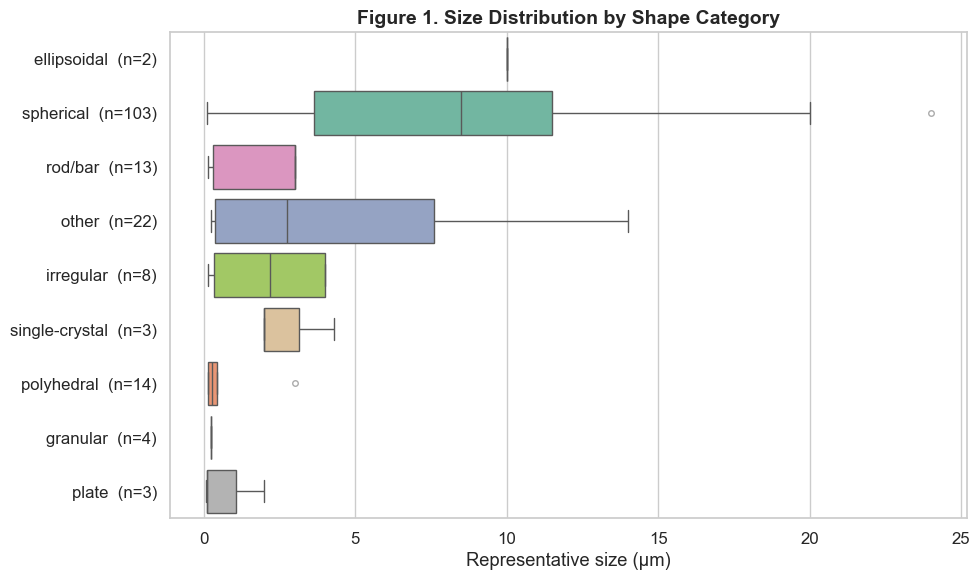

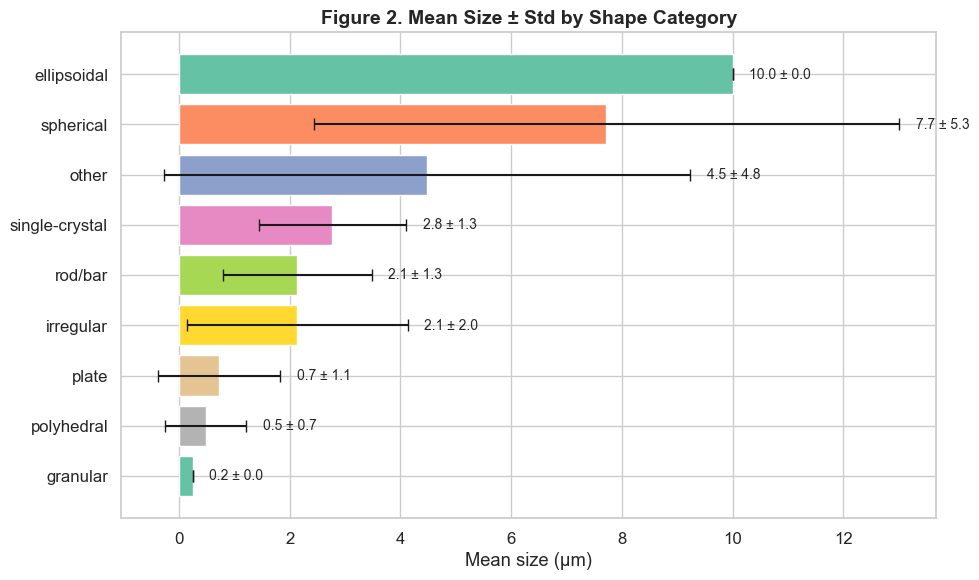

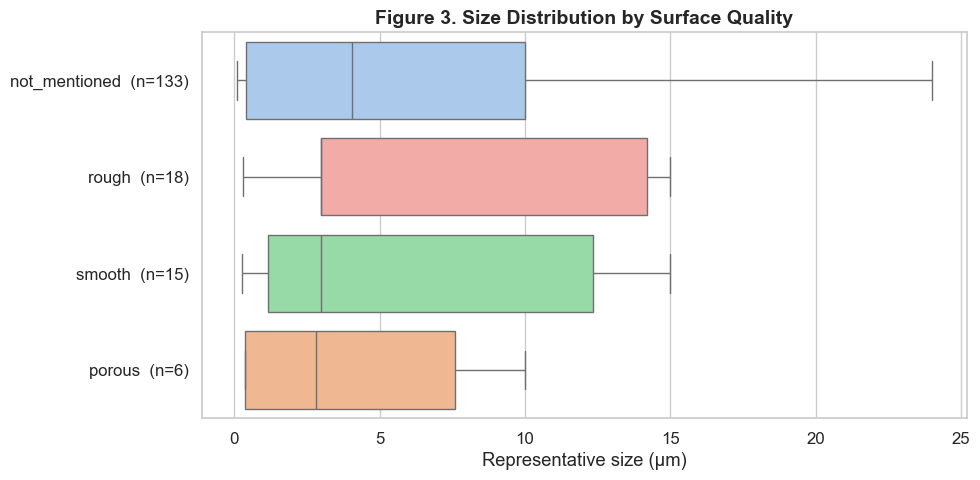

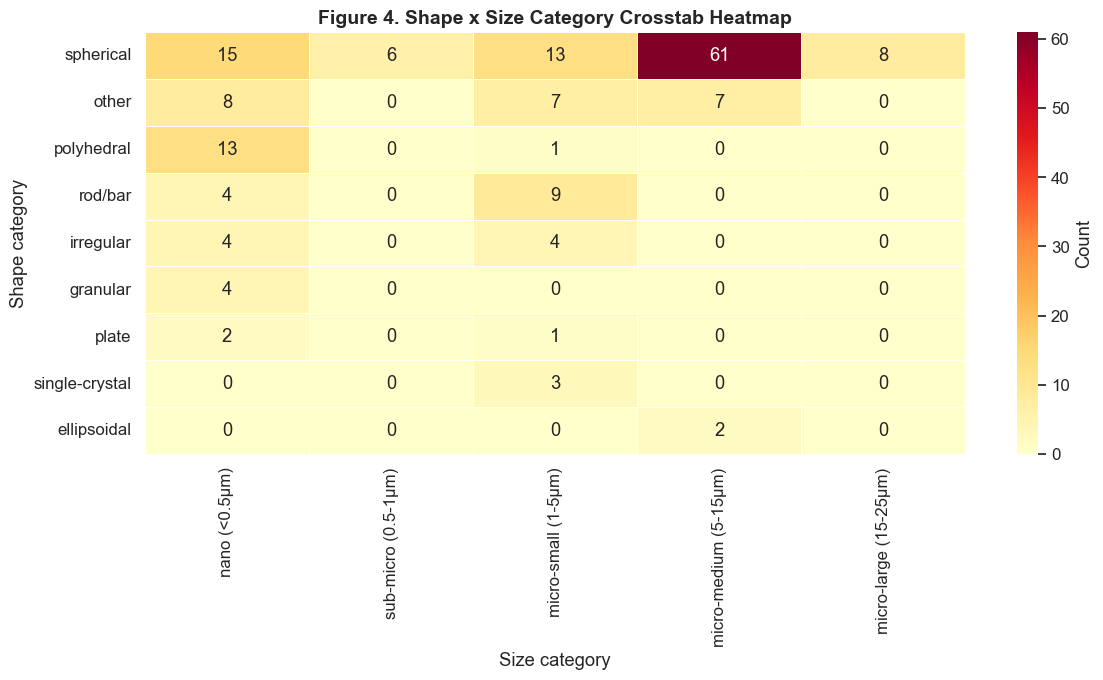

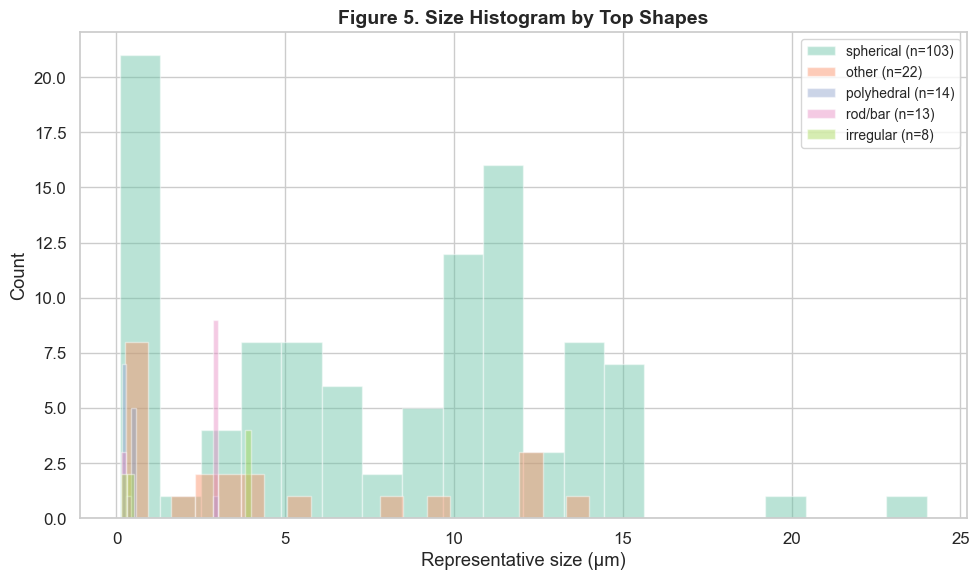

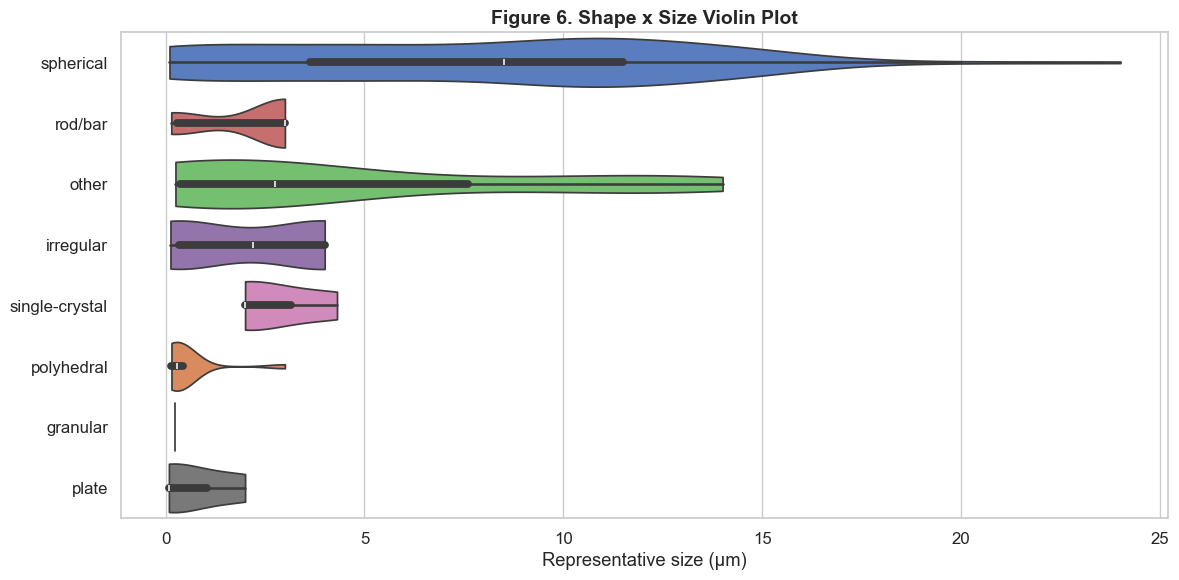

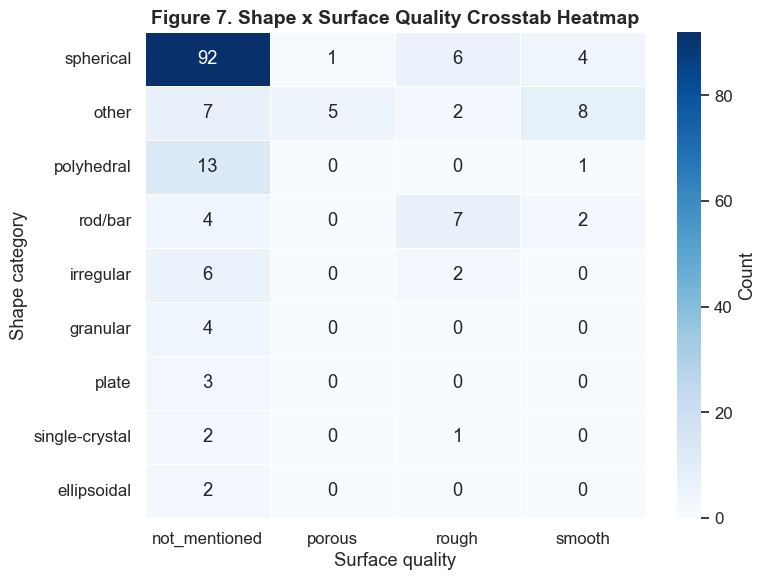

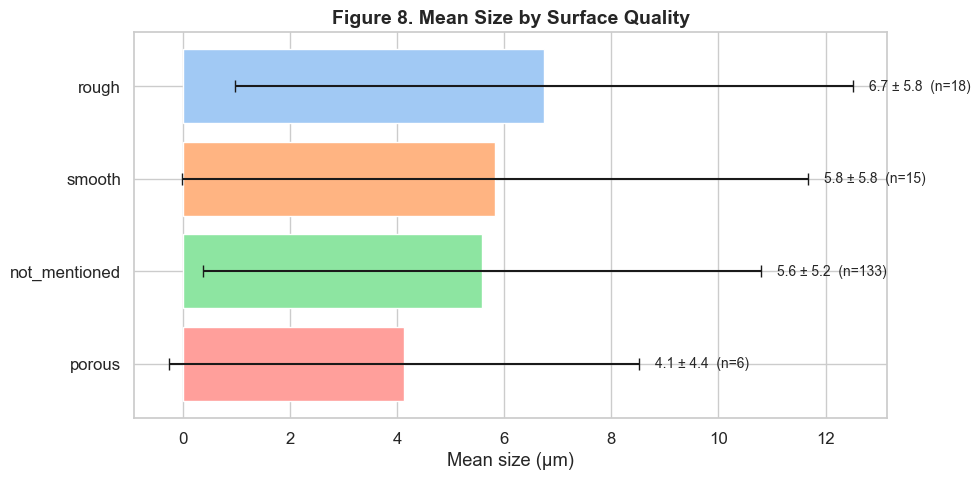


 엑셀 저장 완료: size_shape_combined_analysis.xlsx

 저장된 시트:
  1. combined_data        - 전처리된 172건 데이터
  2. shape_size_stats     - shape별 size 통계
  3. surface_size_stats   - surface별 size 통계
  4. shape_x_size_crosstab  - shape × size 교차표
  5. shape_x_surface_crosstab - shape × surface 교차표


In [18]:
# ============================================================
# Particle size × Particle shape 통합 전처리 + 상관관계 분석 + 시각화
# ============================================================
#
# 이 코드가 하는 일:
#   1) Particle size 열 전처리 (Excel 오염 복구 + 단위 추론 + 카테고리)
#   2) Particle shape 열 전처리 (키워드 기반 → shape_category + surface_quality)
#   3) 두 열을 합쳐서 상관관계 분석
#   4) 8개 figure 시각화
#   5) 엑셀 저장
#
# ============================================================

import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from openpyxl import load_workbook
from datetime import datetime, time, timedelta
from scipy import stats


# ============================================================
# 0. 사용자 설정 - 여기만 수정하면 됨
# ============================================================

file_path = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
sheet_name = 0  # 첫 번째 시트

# 결과 저장 파일명
output_excel = "size_shape_combined_analysis.xlsx"


# ############################################################
# ############################################################
# ##                                                        ##
# ##   PART A. Particle size 전처리                          ##
# ##                                                        ##
# ############################################################
# ############################################################


# ============================================================
# A-1. 데이터 읽기
# ------------------------------------------------------------
# pandas: 전체 데이터프레임
# openpyxl: Particle size 원본 셀 값 (Excel 오염 복구용)
# ============================================================

df = pd.read_excel(file_path, sheet_name=sheet_name)

wb = load_workbook(file_path, data_only=True)
ws = wb[wb.sheetnames[sheet_name if isinstance(sheet_name, int) else 0]]
headers = [cell.value for cell in ws[1]]

# Particle size 열 위치
size_col_idx = headers.index("Particle size") + 1

# Paper ID 열 위치 (나중에 추적용)
paper_col_idx = headers.index("Paper ID") + 1

# Particle size 원본 값 읽기
raw_size_values = [
    ws.cell(row=r, column=size_col_idx).value
    for r in range(2, ws.max_row + 1)
]


# ============================================================
# A-2. Excel 오염 복구 함수
# ------------------------------------------------------------
# Excel이 자동으로 바꿔버린 값을 원래 의미로 복구
#
# 예:
#   "3-5" → datetime(2026, 3, 5) 로 바뀐 것 → "3-5"로 복구
#   "5-25" → 5e+25 로 바뀐 것 → "5-25"로 복구
# ============================================================

def restore_corrupted_value(value):
    """Excel이 망가뜨린 값을 문자열로 복구"""

    if value is None:
        return None

    if isinstance(value, float) and math.isnan(value):
        return None

    # datetime(2026, 3, 5) → "3-5" (particle size 범위)
    if isinstance(value, datetime):
        return f"{value.month}-{value.day}"

    # time 타입이면 문자열로
    if isinstance(value, time):
        return f"{value.hour}:{value.minute}"

    # timedelta 타입이면 문자열로
    if isinstance(value, timedelta):
        total = int(round(value.total_seconds()))
        h = total // 3600
        m = (total % 3600) // 60
        s = total % 60
        return f"{h}:{m}:{s}"

    # 5e+25 같은 비정상적으로 큰 float → "5-25"로 복구
    if isinstance(value, float) and value > 1e10:
        sci_str = f"{value:.0e}"
        match = re.match(r"(\d+)e\+(\d+)", sci_str)
        if match:
            return f"{match.group(1)}-{match.group(2)}"
        return str(value)

    # 일반 숫자 → 문자열로
    if isinstance(value, (int, float)):
        return str(value)

    return str(value).strip()


# ============================================================
# A-3. 텍스트 정규화 함수
# ------------------------------------------------------------
# 논문에서 쓰는 특수 표기를 통일
#
# 예:
#   200e300 → 200~300  (e가 범위 구분자로 쓰인 경우)
#   5−15    → 5-15     (특수 대시 → 일반 대시)
# ============================================================

def normalize_text(text):
    """특수 기호를 통일 (단위 변환은 하지 않음)"""

    if text is None:
        return None

    text = str(text)

    # 논문에서 "e"를 범위 구분자로 쓴 경우 → "~"로 변환
    text = re.sub(r'(\d+\.?\d*)\s*e\s*(\d+\.?\d+)', r'\1~\2', text)
    text = re.sub(r'(\d{2,})\s*e\s*(\d{2,})', r'\1~\2', text)
    text = re.sub(r'(\d+)\s*e\s+(\d+)', r'\1~\2', text)

    # 특수 대시/틸데 → 일반 기호
    text = text.replace('−', '-').replace('–', '-').replace('—', '-')
    text = text.replace('∼', '~').replace('≈', '~')

    return text


# ============================================================
# A-4. 단위 관련 함수
# ============================================================

# 단위를 잡는 정규식
UNIT_RE = re.compile(
    r'(nm|μm|µm|um|mm|micron|micro[\s\-]?m(?:eter|etre)?)',
    re.IGNORECASE
)

# 범위 패턴: "3-5 μm", "200~300 nm", "1 to 2" 등
RANGE_PATTERN = re.compile(
    r'(?:(?:between|from)\s*)?'            # 선택: "between", "from"
    r'(?P<v1>\d+\.?\d*)\s*'                # 첫 번째 숫자
    r'(?:-|~|to|and)\s*'                   # 구분자
    r'(?:(?:about|around|approx\.?|approximately)\s*)?'  # 선택: "about" 등
    r'(?P<v2>\d+\.?\d*)\s*'                # 두 번째 숫자
    r'(?P<unit>nm|μm|µm|um|mm|micron)?',   # 선택: 단위
    re.IGNORECASE
)

# 단일 숫자 패턴: "10 μm", "145", "0.4" 등
SINGLE_PATTERN = re.compile(
    r'(?P<val>\d+\.?\d*)\s*(?P<unit>nm|μm|µm|um|mm|micron)?',
    re.IGNORECASE
)


def normalize_unit(unit_text):
    """다양한 단위 표기 → nm / μm / mm 중 하나로 통일"""

    if not unit_text:
        return None

    u = unit_text.lower().replace('µ', 'μ')

    if u == 'nm' or 'nanom' in u:
        return 'nm'
    if u in ('μm', 'um', 'micron') or 'microm' in u:
        return 'μm'
    if u == 'mm':
        return 'mm'

    return None


def extract_number_entries(text):
    """
    문장에서 숫자들을 순서대로 추출한다.
    범위("3-5")는 두 개 숫자로 나눠서 넣는다.
    """

    if not text:
        return []

    text = normalize_text(text)
    entries = []
    used_spans = []

    # 1) 범위 먼저 추출
    for m in RANGE_PATTERN.finditer(text):
        v1 = float(m.group('v1'))
        v2 = float(m.group('v2'))
        unit = normalize_unit(m.group('unit'))

        entries.append({'pos': m.start(), 'value': v1, 'unit': unit})
        entries.append({'pos': m.start() + 0.001, 'value': v2, 'unit': unit})
        used_spans.append((m.start(), m.end()))

    # 2) 단일 숫자 추출 (이미 범위에서 잡힌 부분은 스킵)
    for m in SINGLE_PATTERN.finditer(text):
        overlapped = any(s <= m.start() < e for s, e in used_spans)
        if overlapped:
            continue

        value = float(m.group('val'))
        unit = normalize_unit(m.group('unit'))
        entries.append({'pos': m.start(), 'value': value, 'unit': unit})

    # 순서 정렬
    entries = sorted(entries, key=lambda x: x['pos'])
    return entries


# ============================================================
# A-5. 도메인 기반 단위 추론
# ------------------------------------------------------------
# 단위 없는 숫자에 대해 NCM 양극재 도메인 지식으로 단위를 추론
#
# NCM cathode 일반 지식:
#   Primary particle:   50 ~ 500 nm
#   Secondary particle: 2 ~ 20 μm
#   Single crystal:     1 ~ 5 μm
#
# 규칙:
#   값 >= 100  → nm  (primary particle 범위)
#   1 <= 값 < 100 → μm  (secondary / single crystal 범위)
#   값 < 1     → μm  (sub-micron 표기)
# ============================================================

def infer_unit_for_value(value):
    """도메인 지식으로 단위 추론"""

    if value >= 100:
        return 'nm'
    if 1 <= value < 100:
        return 'μm'
    if value < 1:
        return 'μm'
    return None


def convert_to_um(value, unit):
    """단위를 μm 기준으로 변환"""

    if unit == 'nm':
        return value / 1000.0
    if unit == 'μm':
        return value
    if unit == 'mm':
        return value * 1000.0
    return None


# ============================================================
# A-6. Particle size 전처리 메인 함수
# ------------------------------------------------------------
# 핵심 규칙:
#   - 단위가 있으면 그대로 사용 (mm는 μm로 보정)
#   - 단위 없으면 도메인 추론
#   - 한 문장에 여러 단위 → 앞에 나온 첫 단위만 사용
# ============================================================

def process_one_size(raw_value):
    """
    한 행의 Particle size 값을 전처리

    반환: (size_um, confidence, restored_text)
      - size_um: 대표 크기 (μm)
      - confidence: 'explicit' / 'inferred' / 'corrected' / None
      - restored_text: 복구된 원본 텍스트
    """

    # 1) 오염 복구
    text = restore_corrupted_value(raw_value)
    if text is None:
        return None, None, None

    # 2) 텍스트 정규화
    text_normalized = normalize_text(text)

    # 3) 숫자+단위 추출
    entries = extract_number_entries(text_normalized)
    if len(entries) == 0:
        return None, None, text

    # 4) 각 숫자에 단위 결정
    resolved = []
    for entry in entries:
        value = entry['value']
        unit = entry['unit']

        if unit is not None:
            # 명시 단위 있음
            if unit == 'mm' and value < 100:
                # mm는 NCM에서 보통 μm 오타
                final_unit = 'μm'
                confidence = 'corrected'
            else:
                final_unit = unit
                confidence = 'explicit'
        else:
            # 명시 단위 없음 → 도메인 추론
            final_unit = infer_unit_for_value(value)
            confidence = 'inferred' if final_unit else 'unknown'

        # μm로 변환
        size_um = convert_to_um(value, final_unit) if final_unit else None

        # 유효한 범위만 보존 (0 < size < 500 μm)
        if size_um and 0 < size_um < 500:
            resolved.append({
                'value': value,
                'final_unit': final_unit,
                'size_um': size_um,
                'confidence': confidence,
            })

    if len(resolved) == 0:
        return None, None, text

    # 5) 핵심 규칙: 첫 단위만 사용
    selected_unit = resolved[0]['final_unit']
    kept = [r for r in resolved if r['final_unit'] == selected_unit]

    # 6) 대표값 = 유지된 값들의 평균
    representative = np.mean([r['size_um'] for r in kept])
    confidence = kept[0]['confidence']

    return round(representative, 4), confidence, text


# ============================================================
# A-7. Particle size 전처리 실행
# ============================================================

# 빈 리스트 준비
size_um_list = []
size_confidence_list = []
size_text_list = []

# 각 행에 대해 전처리
for raw_val in raw_size_values:
    um, conf, txt = process_one_size(raw_val)
    size_um_list.append(um)
    size_confidence_list.append(conf)
    size_text_list.append(txt)

# 결과를 df에 추가
df['size_um'] = size_um_list
df['size_confidence'] = size_confidence_list
df['size_restored'] = size_text_list


# size 카테고리 부여 함수
def assign_size_category(size_um):
    """μm 값을 NCM 기준 카테고리로 분류"""

    if size_um is None:
        return None
    if isinstance(size_um, float) and math.isnan(size_um):
        return None

    if size_um < 0.5:
        return 'nano (<0.5μm)'
    elif size_um < 1:
        return 'sub-micro (0.5-1μm)'
    elif size_um < 5:
        return 'micro-small (1-5μm)'
    elif size_um < 15:
        return 'micro-medium (5-15μm)'
    elif size_um < 25:
        return 'micro-large (15-25μm)'
    else:
        return 'macro (>25μm)'


df['size_category'] = df['size_um'].apply(assign_size_category)

print("Particle size 전처리 완료!")
print(f"  size_um 있는 행: {df['size_um'].notna().sum()}")


# ############################################################
# ############################################################
# ##                                                        ##
# ##   PART B. Particle shape 전처리                         ##
# ##                                                        ##
# ############################################################
# ############################################################


# ============================================================
# B-1. Shape 카테고리 규칙
# ------------------------------------------------------------
# 키워드 매칭으로 비정형 텍스트 → 표준 카테고리
#
# 규칙: 위에서부터 순서대로 매칭하고, 첫 매칭이 결과가 됨
# ============================================================

# (카테고리 이름, 키워드 정규식) 순서
SHAPE_RULES = [
    ('spherical',      r'spher|sphere|globular|microsphere|round'),
    ('polyhedral',     r'polyhedr|faceted|cuboctahedr'),
    ('rod/bar',        r'\brod\b|bar-like|nanobar|elongat'),
    ('plate',          r'plate|nanoplate|flat'),
    ('granular',       r'granular'),
    ('single-crystal', r'single.?crystal'),
    ('ellipsoidal',    r'ellipsoid'),
    ('hollow',         r'hollow'),
    ('irregular',      r'irregular|shapeless|non-specific'),
]

# 표면 품질 규칙
SURFACE_RULES = [
    ('smooth',  r'smooth|clean'),
    ('rough',   r'rough|coars|rugged|fuzzy'),
    ('porous',  r'porous|porosity|pinhole'),
    ('cracked', r'crack'),
]


def classify_shape(text):
    """
    텍스트에서 shape 카테고리 추출
    예: 'spherical morphology' → 'spherical'
    """

    # 값이 없으면 None
    if pd.isna(text) or not str(text).strip():
        return None

    text_lower = str(text).lower()

    # 위에서부터 순서대로 매칭
    for category_name, pattern in SHAPE_RULES:
        if re.search(pattern, text_lower):
            return category_name

    # 어디에도 안 걸리면 'other'
    return 'other'


def classify_surface(text):
    """
    텍스트에서 surface quality 추출
    예: 'smooth surface' → 'smooth'
    """

    if pd.isna(text) or not str(text).strip():
        return 'not_mentioned'

    text_lower = str(text).lower()

    for category_name, pattern in SURFACE_RULES:
        if re.search(pattern, text_lower):
            return category_name

    return 'not_mentioned'


# ============================================================
# B-2. Particle shape 전처리 실행
# ============================================================

df['shape_category'] = df['Particle shape'].apply(classify_shape)
df['surface_quality'] = df['Particle shape'].apply(classify_surface)

print("\nParticle shape 전처리 완료!")
print(f"  shape_category 있는 행: {df['shape_category'].notna().sum()}")
print(f"\n[shape_category 분포]")
print(df['shape_category'].value_counts(dropna=False).to_string())
print(f"\n[surface_quality 분포]")
print(df['surface_quality'].value_counts(dropna=False).to_string())


# ############################################################
# ############################################################
# ##                                                        ##
# ##   PART C. 통합 상관관계 분석                              ##
# ##                                                        ##
# ############################################################
# ############################################################


# ============================================================
# C-1. 두 열이 모두 있는 행만 추출
# ============================================================

both = df.dropna(subset=['size_um', 'shape_category']).copy()

print("\n" + "=" * 60)
print("  통합 분석 (size × shape)")
print("=" * 60)
print(f"전체 행: {len(df)}")
print(f"size 있음: {df['size_um'].notna().sum()}")
print(f"shape 있음: {df['shape_category'].notna().sum()}")
print(f"둘 다 있음: {len(both)}")


# ============================================================
# C-2. Shape별 Size 통계
# ============================================================

print("\n[shape_category별 size_um 통계]")
shape_stats = (
    both
    .groupby('shape_category')['size_um']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
    .sort_values('count', ascending=False)
)
print(shape_stats.to_string())

print("\n[surface_quality별 size_um 통계]")
surface_stats = (
    both
    .groupby('surface_quality')['size_um']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .round(2)
    .sort_values('count', ascending=False)
)
print(surface_stats.to_string())


# ============================================================
# C-3. Shape × Size Category 교차표
# ============================================================

print("\n[shape_category × size_category 교차표]")
crosstab = pd.crosstab(
    both['shape_category'],
    both['size_category'],
    margins=True
)
print(crosstab.to_string())


# ============================================================
# C-4. ANOVA 검정
# ------------------------------------------------------------
# "shape_category별로 size_um이 유의미하게 다른가?"
# ============================================================

print("\n[ANOVA 검정: shape별 size 차이]")

# 3개 이상 데이터가 있는 그룹만 사용
groups = [
    group['size_um'].values
    for _, group in both.groupby('shape_category')
    if len(group) >= 3
]

if len(groups) >= 2:
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"  F-statistic = {f_stat:.3f}")
    print(f"  p-value     = {p_val:.6f}")

    if p_val < 0.05:
        print("  → 유의미한 차이 있음 (p < 0.05)")
    else:
        print("  → 유의미한 차이 없음 (p >= 0.05)")


# ############################################################
# ############################################################
# ##                                                        ##
# ##   PART D. 시각화 (8개 Figure)                           ##
# ##                                                        ##
# ############################################################
# ############################################################

sns.set_theme(style='whitegrid', font_scale=1.1)


# ============================================================
# Figure 1. Shape Category별 Size 분포 (Boxplot)
# ------------------------------------------------------------
# 각 shape category의 크기 분포를 한눈에 비교
# ============================================================

# shape를 중앙값 기준으로 정렬
shape_order = (
    both
    .groupby('shape_category')['size_um']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# 2건 이상인 것만 표시
shape_order = [
    s for s in shape_order
    if both[both['shape_category'] == s].shape[0] >= 2
]

# 각 shape의 데이터 개수
shape_counts = both['shape_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=both[both['shape_category'].isin(shape_order)],
    y='shape_category',
    x='size_um',
    order=shape_order,
    hue='shape_category',
    palette='Set2',
    legend=False,
    showfliers=True,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
plt.yticks(
    range(len(shape_order)),
    [f"{s}  (n={shape_counts.get(s, 0)})" for s in shape_order]
)
plt.xlabel('Representative size (μm)')
plt.ylabel('')
plt.title('Figure 1. Size Distribution by Shape Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 2. Shape Category별 평균 Size ± Std (Bar)
# ============================================================

mean_df = (
    both
    .groupby('shape_category')['size_um']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
mean_df = mean_df[mean_df['count'] >= 2].sort_values('mean', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    mean_df['shape_category'],
    mean_df['mean'],
    xerr=mean_df['std'],
    color=sns.color_palette('Set2', len(mean_df)),
    capsize=4,
    edgecolor='white',
    linewidth=1
)

# 수치 표시
for i, (_, row) in enumerate(mean_df.iterrows()):
    plt.text(
        row['mean'] + row['std'] + 0.3,
        i,
        f"{row['mean']:.1f} ± {row['std']:.1f}",
        va='center',
        fontsize=10
    )

plt.xlabel('Mean size (μm)')
plt.title('Figure 2. Mean Size ± Std by Shape Category', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ============================================================
# Figure 3. Surface Quality별 Size 분포 (Boxplot)
# ============================================================

surf_order = (
    both
    .groupby('surface_quality')['size_um']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

surf_order = [
    s for s in surf_order
    if both[both['surface_quality'] == s].shape[0] >= 2
]

surf_counts = both['surface_quality'].value_counts()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=both[both['surface_quality'].isin(surf_order)],
    y='surface_quality',
    x='size_um',
    order=surf_order,
    hue='surface_quality',
    palette='pastel',
    legend=False,
    flierprops=dict(marker='o', markersize=4, alpha=0.5)
)
plt.yticks(
    range(len(surf_order)),
    [f"{s}  (n={surf_counts.get(s, 0)})" for s in surf_order]
)
plt.xlabel('Representative size (μm)')
plt.ylabel('')
plt.title('Figure 3. Size Distribution by Surface Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 4. Shape × Size Category 교차 히트맵
# ------------------------------------------------------------
# 가장 중요한 그래프!
# "어떤 형태가 어떤 크기 범위에 주로 분포하는지"를 보여줌
# ============================================================

size_cat_order = [
    'nano (<0.5μm)',
    'sub-micro (0.5-1μm)',
    'micro-small (1-5μm)',
    'micro-medium (5-15μm)',
    'micro-large (15-25μm)',
    'macro (>25μm)',
]

# 교차표 만들기
cross_clean = pd.crosstab(both['shape_category'], both['size_category'])

# 순서 맞추기
cross_clean = cross_clean.reindex(
    columns=[c for c in size_cat_order if c in cross_clean.columns],
    fill_value=0
)

# shape도 빈도순으로 정렬
shape_heatmap_order = cross_clean.sum(axis=1).sort_values(ascending=False).index.tolist()
cross_clean = cross_clean.reindex(shape_heatmap_order)

plt.figure(figsize=(12, 7))
sns.heatmap(
    cross_clean,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Count'}
)
plt.title('Figure 4. Shape x Size Category Crosstab Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Shape category')
plt.xlabel('Size category')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 5. 주요 Shape별 Size 히스토그램
# ============================================================

# 상위 5개 shape만
top_shapes = both['shape_category'].value_counts().head(5).index.tolist()
colors = sns.color_palette('Set2', len(top_shapes))

plt.figure(figsize=(10, 6))

for shape, color in zip(top_shapes, colors):
    subset = both[both['shape_category'] == shape]['size_um']

    plt.hist(
        subset,
        bins=20,
        alpha=0.45,
        label=f'{shape} (n={len(subset)})',
        color=color,
        edgecolor='white'
    )

plt.xlabel('Representative size (μm)')
plt.ylabel('Count')
plt.legend(fontsize=10)
plt.title('Figure 5. Size Histogram by Top Shapes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 6. Shape별 Size Violin Plot
# ------------------------------------------------------------
# boxplot보다 분포 모양을 더 자세히 보여줌
# ============================================================

# 3건 이상인 shape만
violin_shapes = both['shape_category'].value_counts()
violin_shapes = violin_shapes[violin_shapes >= 3].index.tolist()

violin_df = both[both['shape_category'].isin(violin_shapes)].copy()

violin_order = (
    violin_df
    .groupby('shape_category')['size_um']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=violin_df,
    y='shape_category',
    x='size_um',
    order=violin_order,
    hue='shape_category',
    palette='muted',
    legend=False,
    inner='box',
    density_norm='width',
    cut=0
)
plt.xlabel('Representative size (μm)')
plt.ylabel('')
plt.title('Figure 6. Shape x Size Violin Plot', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 7. Shape × Surface Quality 교차 히트맵
# ============================================================

cross_ss = pd.crosstab(both['shape_category'], both['surface_quality'])
cross_ss = cross_ss.reindex(shape_heatmap_order)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cross_ss,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': 'Count'}
)
plt.title('Figure 7. Shape x Surface Quality Crosstab Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Shape category')
plt.xlabel('Surface quality')
plt.tight_layout()
plt.show()


# ============================================================
# Figure 8. Surface Quality별 평균 Size (Bar)
# ============================================================

surf_mean = (
    both
    .groupby('surface_quality')['size_um']
    .agg(['mean', 'std', 'count'])
    .reset_index()
)
surf_mean = surf_mean[surf_mean['count'] >= 2].sort_values('mean', ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.barh(
    surf_mean['surface_quality'],
    surf_mean['mean'],
    xerr=surf_mean['std'],
    color=sns.color_palette('pastel', len(surf_mean)),
    capsize=4,
    edgecolor='white'
)

for i, (_, row) in enumerate(surf_mean.iterrows()):
    plt.text(
        row['mean'] + row['std'] + 0.3,
        i,
        f"{row['mean']:.1f} ± {row['std']:.1f}  (n={int(row['count'])})",
        va='center',
        fontsize=10
    )

plt.xlabel('Mean size (μm)')
plt.title('Figure 8. Mean Size by Surface Quality', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# ############################################################
# ############################################################
# ##                                                        ##
# ##   PART E. 엑셀 저장                                     ##
# ##                                                        ##
# ############################################################
# ############################################################

with pd.ExcelWriter(output_excel, engine='openpyxl') as writer:

    # 1) 분석에 사용된 172건 데이터
    both[[
        'Paper ID',
        'Particle size', 'Particle shape',
        'size_um', 'size_category', 'size_confidence',
        'shape_category', 'surface_quality',
    ]].to_excel(writer, sheet_name='combined_data', index=False)

    # 2) shape별 size 통계
    shape_stats.to_excel(writer, sheet_name='shape_size_stats')

    # 3) surface별 size 통계
    surface_stats.to_excel(writer, sheet_name='surface_size_stats')

    # 4) shape × size 교차표
    cross_clean.to_excel(writer, sheet_name='shape_x_size_crosstab')

    # 5) shape × surface 교차표
    cross_ss.to_excel(writer, sheet_name='shape_x_surface_crosstab')

print(f"\n 엑셀 저장 완료: {output_excel}")
print("\n 저장된 시트:")
print("  1. combined_data        - 전처리된 172건 데이터")
print("  2. shape_size_stats     - shape별 size 통계")
print("  3. surface_size_stats   - surface별 size 통계")
print("  4. shape_x_size_crosstab  - shape × size 교차표")
print("  5. shape_x_surface_crosstab - shape × surface 교차표")


📖 데이터 기본 정보
전체 행(row) 수: 504
전체 열(column) 수: 75
Coating 열 — 데이터 있음: 214행, 비어있음: 290행
Particle shape 열 — 데이터 있음: 258행, 비어있음: 246행

--- Coating Category 분포 ---
coating_category
NaN                       290
Metal Oxides               61
Li-based Compounds         50
Phosphates & Fluorides     33
Others / Unspecified       28
Carbon-based               19
Polymers & Organics        16
Hybrids / Composites        7


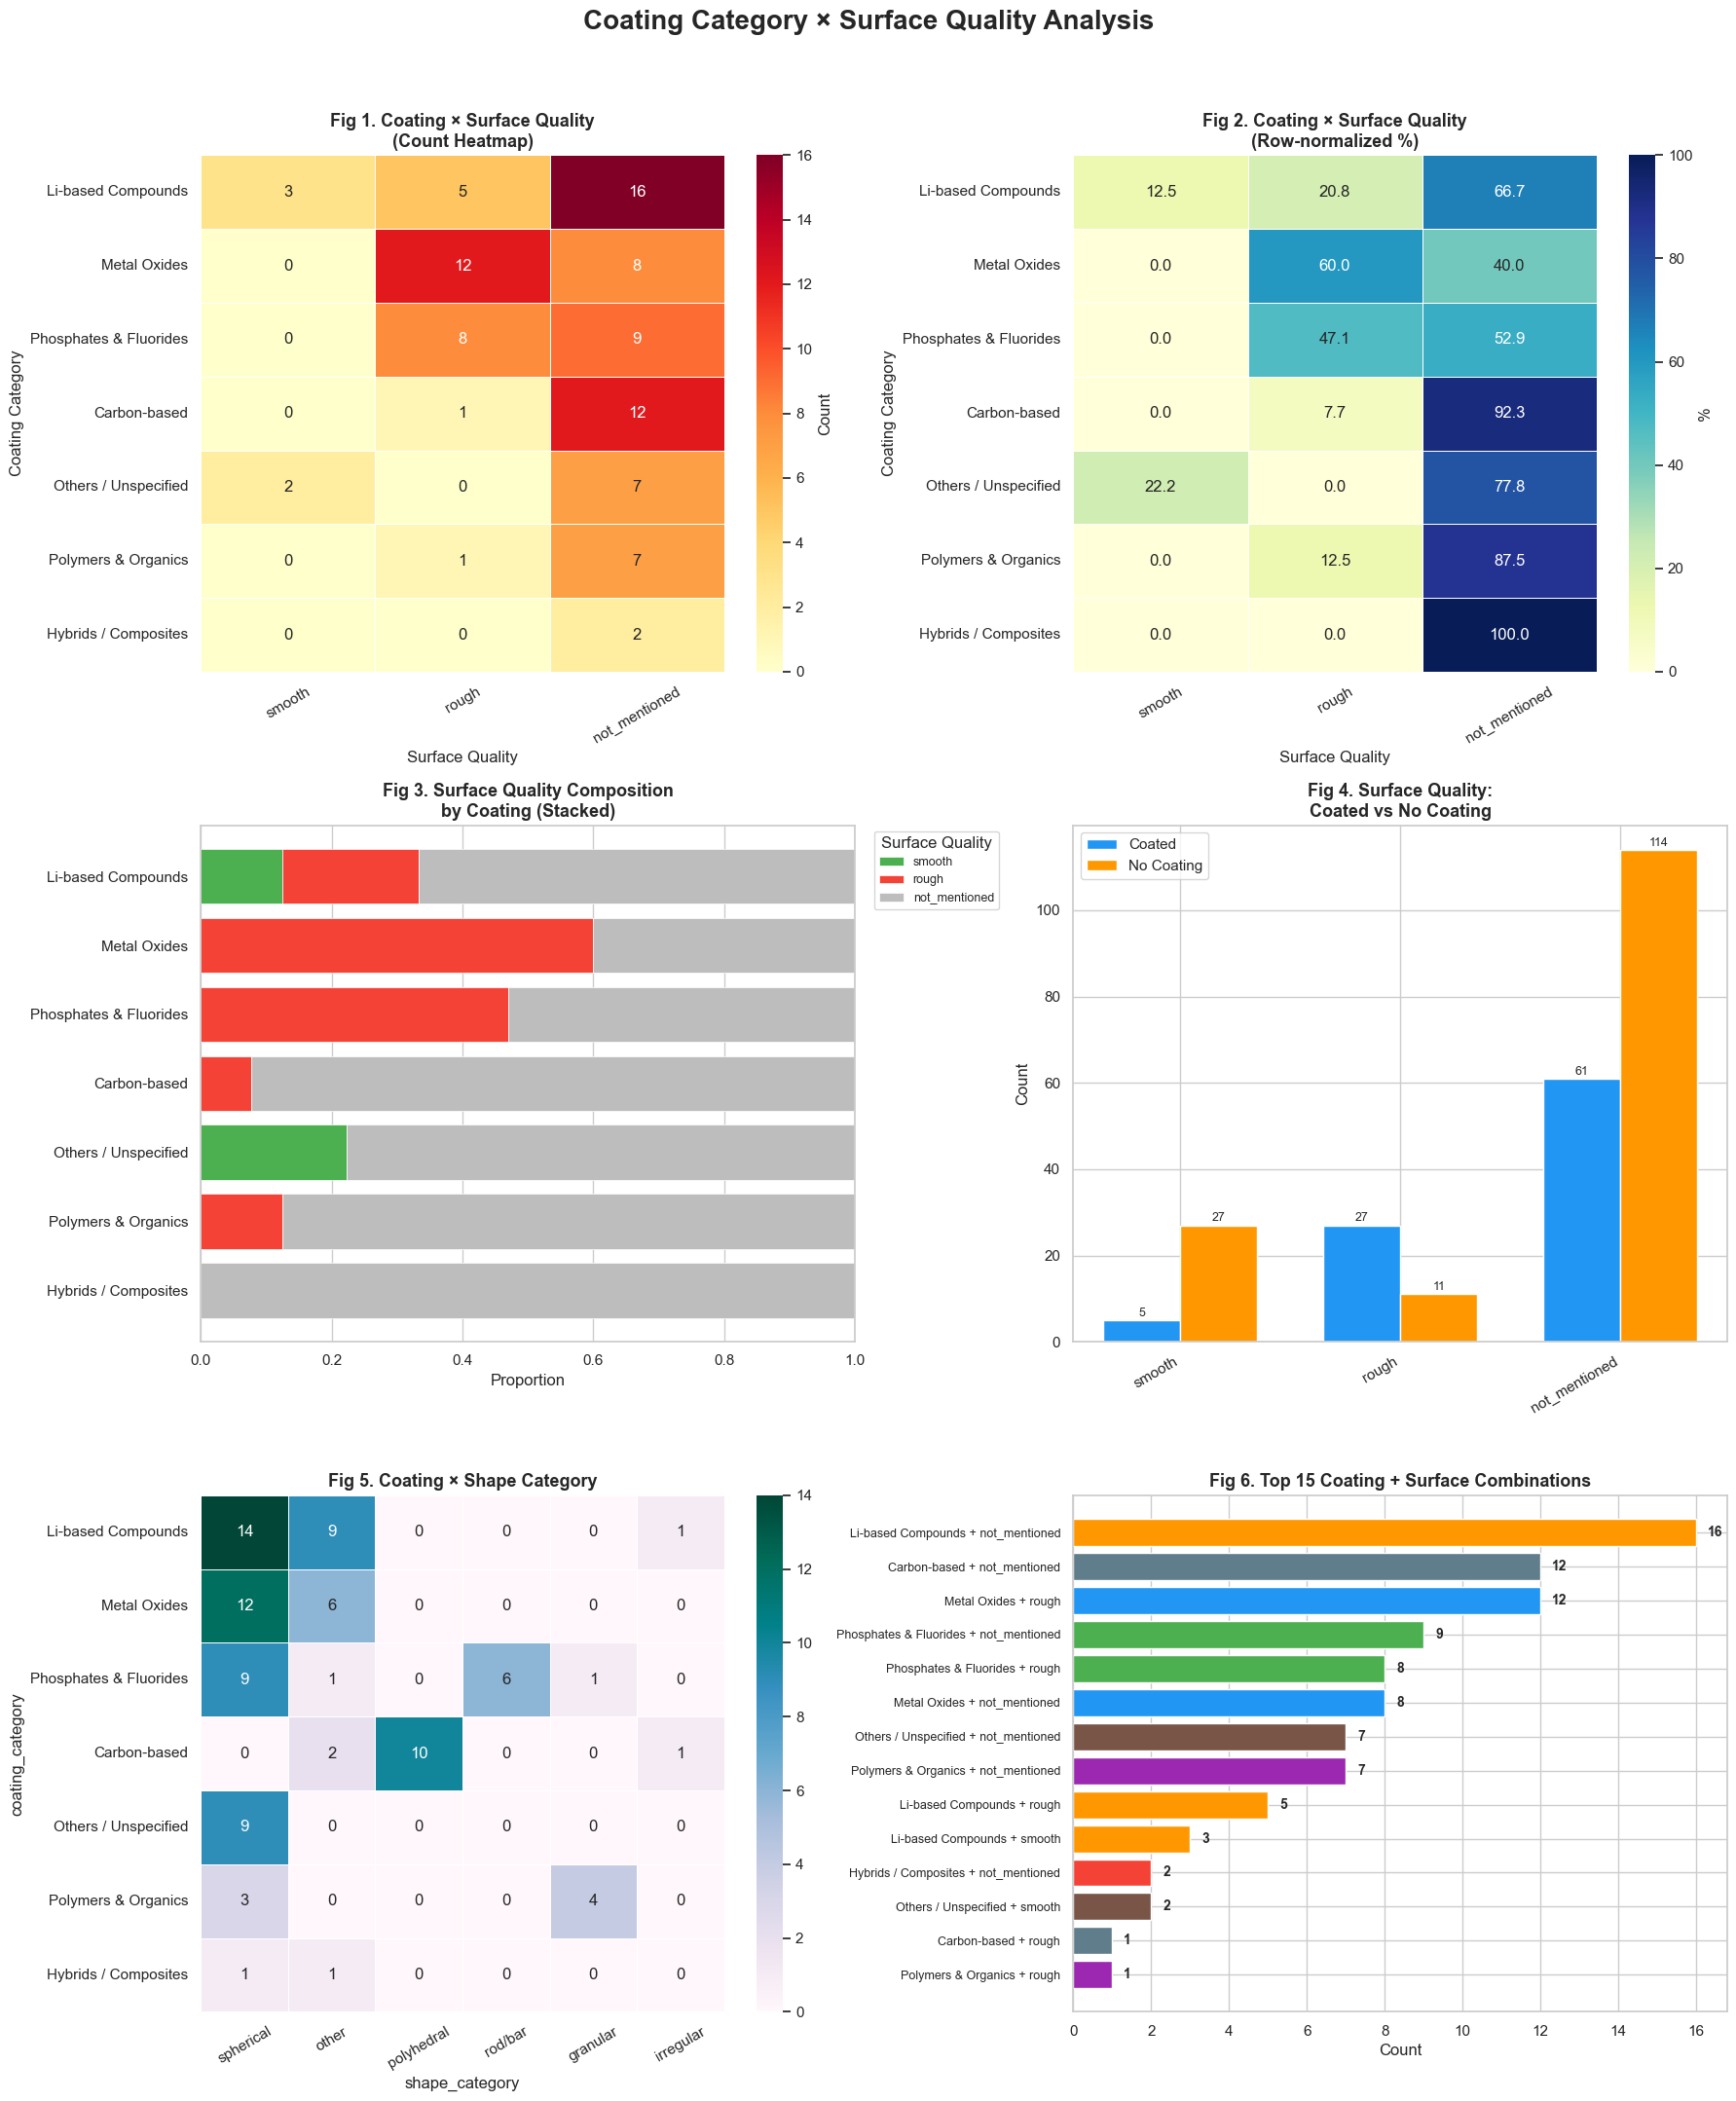


📊 핵심 인사이트 요약

[1] Coated vs No Coating의 Surface Quality 차이:
  Coated (n=93): smooth=5(5.4%), rough=27(29.0%)
  No Coating (n=165): smooth=27(16.4%), rough=11(6.7%)

[2] 가장 흔한 Coating + Surface 조합 Top 3:
  1. Li-based Compounds + not_mentioned: 16건
  2. Carbon-based + not_mentioned: 12건
  3. Metal Oxides + rough: 12건


In [2]:
# ============================================================
# 📌 Coating Category × Surface Quality 통합 분석 (Jupyter Notebook 버전)
# ============================================================
# Jupyter 환경에서 그래프를 셀 바로 아래에 출력하기 위한 매직 명령어
%matplotlib inline

# ============================================================
# 0. 라이브러리 불러오기
# ============================================================
import pandas as pd          # 데이터 분석용 (엑셀 읽기, 테이블 조작)
import numpy as np           # 수학 연산용 (배열, 숫자 계산)
import matplotlib.pyplot as plt   # 그래프 그리기
import seaborn as sns        # 예쁜 통계 그래프 그리기

# ============================================================
# 1. ⚙️ 설정 (자신의 엑셀 파일 경로로 수정하세요!)
# ============================================================
FILE_PATH = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"

OUTPUT_IMAGE = "coating_surface_analysis.png"    # 시각화 이미지 저장명
OUTPUT_EXCEL = "coating_surface_analysis.xlsx"   # 분석 결과 엑셀 저장명

# ============================================================
# 2. 📖 데이터 불러오기
# ============================================================
df = pd.read_excel(FILE_PATH)

print("=" * 60)
print("📖 데이터 기본 정보")
print("=" * 60)
print(f"전체 행(row) 수: {len(df)}")
print(f"전체 열(column) 수: {len(df.columns)}")
print(f"Coating 열 — 데이터 있음: {df['Coating'].notna().sum()}행, "
      f"비어있음: {df['Coating'].isna().sum()}행")
print(f"Particle shape 열 — 데이터 있음: {df['Particle shape'].notna().sum()}행, "
      f"비어있음: {df['Particle shape'].isna().sum()}행")

# ============================================================
# 3. 🏷️ Coating 카테고리 매핑
# ============================================================
coating_mapping = {
    # ── 1. Metal Oxides (금속 산화물) ──
    'Al2O3': 'Metal Oxides', 'ZrO2': 'Metal Oxides', 'TiO2': 'Metal Oxides',
    'Co3O4': 'Metal Oxides', 'SiO2': 'Metal Oxides', 'Co oxide': 'Metal Oxides',
    'WO3': 'Metal Oxides', 'B2O3': 'Metal Oxides', 'Cr3O2': 'Metal Oxides',
    'CeO2': 'Metal Oxides', 'ZnO': 'Metal Oxides', 'La2O3': 'Metal Oxides',

    # ── 2. Li-based Compounds (리튬 화합물 및 고체전해질) ──
    'LiNbO3': 'Li-based Compounds', 'LiAlO2': 'Li-based Compounds', 'Li3VO4': 'Li-based Compounds',
    'Li2ZrO3': 'Li-based Compounds', 'LSTP': 'Li-based Compounds', 'Li4Ti5O12': 'Li-based Compounds',
    'Li2SO4/Li2SO3': 'Li-based Compounds', 'lithium tungsten oxide': 'Li-based Compounds',
    'Li2TiO3-Li2ZrO3': 'Li-based Compounds', 'LiAlO2, Al2O3': 'Li-based Compounds',
    'Li2TiO3': 'Li-based Compounds', 'LiNO3': 'Li-based Compounds', 'Al2O3/LiAlO2': 'Li-based Compounds',
    'Li5AlO4': 'Li-based Compounds', 'Na5AlO4': 'Li-based Compounds', 'LiBO2/LiAlO2': 'Li-based Compounds',
    'Li3BO3': 'Li-based Compounds', 'LiBO2': 'Li-based Compounds', 'NCA': 'Li-based Compounds',

    # ── 3. Phosphates & Fluorides (인산염 및 불화물) ──
    'Li3PO4': 'Phosphates & Fluorides', 'MnPO4': 'Phosphates & Fluorides', 'LiF': 'Phosphates & Fluorides',
    'AlF3': 'Phosphates & Fluorides', 'CaF2': 'Phosphates & Fluorides', 'Mn3(PO4)2': 'Phosphates & Fluorides',
    'LATP': 'Phosphates & Fluorides',

    # ── 4. Carbon-based (탄소계) ──
    'carbon': 'Carbon-based', 'RGO': 'Carbon-based', 'g-C3N4': 'Carbon-based',
    'AHNS-rGO': 'Carbon-based', 'AHNS-rGO/CNT': 'Carbon-based',

    # ── 5. Polymers & Organics (고분자 및 유기물) ──
    'EPS': 'Polymers & Organics', 'PPy': 'Polymers & Organics', 'PAN': 'Polymers & Organics',
    'PVDF': 'Polymers & Organics', 'MPDMS': 'Polymers & Organics', '(H2AlOtBu)2': 'Polymers & Organics',
    '(H2AlOtBu)2, HF': 'Polymers & Organics',

    # ── 6. Hybrids / Composites (복합 코팅) ──
    'TiO2-Ag': 'Hybrids / Composites', 'LATP, CNT': 'Hybrids / Composites',
    'Li3PO4, PPy': 'Hybrids / Composites', 'polymer/γ-Al2O3': 'Hybrids / Composites',

    # ── 7. Others / Unspecified (기타 및 미상) ──
    'yes': 'Others / Unspecified', 'unspecified': 'Others / Unspecified', 'Al': 'Others / Unspecified',
    'Ag': 'Others / Unspecified', 'Ge-132': 'Others / Unspecified', 'Hec': 'Others / Unspecified',
    'concentration-gradient shell': 'Others / Unspecified', 'multi-element': 'Others / Unspecified',
    'boric acid': 'Others / Unspecified',
}

df['coating_category'] = df['Coating'].replace(coating_mapping)

VALID_CATEGORIES = [
    'Metal Oxides', 'Li-based Compounds', 'Phosphates & Fluorides',
    'Carbon-based', 'Polymers & Organics', 'Hybrids / Composites', 'Others / Unspecified'
]

unmapped_mask = df['Coating'].notna() & ~df['coating_category'].isin(VALID_CATEGORIES)
if unmapped_mask.sum() > 0:
    df.loc[unmapped_mask, 'coating_category'] = 'Others / Unspecified'

print("\n--- Coating Category 분포 ---")
print(df['coating_category'].value_counts(dropna=False).to_string())

# ============================================================
# 4. 🔍 Surface Quality 추출
# ============================================================
def extract_surface_quality(text):
    if pd.isna(text): return np.nan
    t = str(text).lower()
    if any(kw in t for kw in ['rough', 'coarse', 'rugged']): return 'rough'
    elif any(kw in t for kw in ['smooth', 'clean']): return 'smooth'
    elif any(kw in t for kw in ['porous', 'porosity', 'pore']): return 'porous'
    elif any(kw in t for kw in ['crack', 'fracture']): return 'cracked'
    elif any(kw in t for kw in ['compact', 'dense']): return 'compact/dense'
    else: return 'not_mentioned'

df['surface_quality'] = df['Particle shape'].apply(extract_surface_quality)

# ============================================================
# 5. 🔍 Shape Category 추출
# ============================================================
def extract_shape_category(text):
    if pd.isna(text): return np.nan
    t = str(text).lower()
    if any(kw in t for kw in ['spheri', 'sphere', 'round', 'globular']): return 'spherical'
    elif any(kw in t for kw in ['polyhedr', 'faceted', 'polyhedral']): return 'polyhedral'
    elif any(kw in t for kw in ['rod', 'bar', 'elongat', 'needle', 'whisker']): return 'rod/bar'
    elif any(kw in t for kw in ['plate', 'flat', 'sheet', 'flake']): return 'plate'
    elif any(kw in t for kw in ['granul', 'grain']): return 'granular'
    elif any(kw in t for kw in ['single-crystal', 'single crystal', 'monocrystal']): return 'single-crystal'
    elif any(kw in t for kw in ['ellips', 'oval']): return 'ellipsoidal'
    elif any(kw in t for kw in ['irregular', 'non-uniform', 'random']): return 'irregular'
    elif any(kw in t for kw in ['hollow']): return 'hollow'
    else: return 'other'

df['shape_category'] = df['Particle shape'].apply(extract_shape_category)

# ============================================================
# 6. 🔗 코팅 유무 열 생성
# ============================================================
df['has_coating'] = df['Coating'].notna().map({True: 'Coated', False: 'No Coating'})

# ============================================================
# 7. 📊 통합 분석 대상 데이터 필터링
# ============================================================
mask_both = df['coating_category'].notna() & df['surface_quality'].notna()
df_both = df[mask_both].copy()

# ============================================================
# 8. 📋 교차표 생성
# ============================================================
cross_count = pd.crosstab(df_both['coating_category'], df_both['surface_quality'], margins=True)
cross_pct = pd.crosstab(df_both['coating_category'], df_both['surface_quality'], normalize='index').round(3) * 100

df_with_surf = df[df['surface_quality'].notna()].copy()
cross_coated = pd.crosstab(df_with_surf['has_coating'], df_with_surf['surface_quality'], normalize='index').round(3) * 100

# ============================================================
# 9. 🎨 시각화 (6개 피겨)
# ============================================================
sns.set_theme(style="whitegrid", font_scale=1.0)
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
fig.suptitle('Coating Category × Surface Quality Analysis', fontsize=20, fontweight='bold', y=0.98)

coat_order = df_both['coating_category'].value_counts().index.tolist()
surf_order = [s for s in ['smooth', 'rough', 'porous', 'compact/dense', 'cracked', 'not_mentioned'] 
              if s in df_both['surface_quality'].unique()]

coat_colors = {'Metal Oxides': '#2196F3', 'Li-based Compounds': '#FF9800', 'Phosphates & Fluorides': '#4CAF50',
               'Carbon-based': '#607D8B', 'Polymers & Organics': '#9C27B0', 'Hybrids / Composites': '#F44336', 'Others / Unspecified': '#795548'}
surf_colors = {'smooth': '#4CAF50', 'rough': '#F44336', 'porous': '#FF9800', 'compact/dense': '#2196F3', 'cracked': '#9C27B0', 'not_mentioned': '#BDBDBD'}

# Fig 1
ax1 = axes[0, 0]
cross_hm = pd.crosstab(df_both['coating_category'], df_both['surface_quality']).reindex(index=coat_order, columns=surf_order).fillna(0)
sns.heatmap(cross_hm, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_title('Fig 1. Coating × Surface Quality\n(Count Heatmap)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Surface Quality'); ax1.set_ylabel('Coating Category')
ax1.tick_params(axis='x', rotation=30)

# Fig 2
ax2 = axes[0, 1]
cross_pct_hm = pd.crosstab(df_both['coating_category'], df_both['surface_quality'], normalize='index').round(3) * 100
cross_pct_hm = cross_pct_hm.reindex(index=coat_order, columns=surf_order).fillna(0)
sns.heatmap(cross_pct_hm, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5, ax=ax2, cbar_kws={'label': '%'}, vmin=0, vmax=100)
ax2.set_title('Fig 2. Coating × Surface Quality\n(Row-normalized %)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Surface Quality'); ax2.set_ylabel('Coating Category')
ax2.tick_params(axis='x', rotation=30)

# Fig 3
ax3 = axes[1, 0]
cross_stack = pd.crosstab(df_both['coating_category'], df_both['surface_quality'], normalize='index').reindex(index=coat_order, columns=surf_order).fillna(0)
bottom = np.zeros(len(coat_order))
for sq in surf_order:
    if sq in cross_stack.columns:
        vals = cross_stack[sq].values
        ax3.barh(coat_order, vals, left=bottom, label=sq, color=surf_colors.get(sq, '#888888'), edgecolor='white', linewidth=0.5)
        bottom += vals
ax3.set_xlim(0, 1.0); ax3.set_xlabel('Proportion')
ax3.set_title('Fig 3. Surface Quality Composition\nby Coating (Stacked)', fontsize=13, fontweight='bold')
ax3.legend(title='Surface Quality', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax3.invert_yaxis()

# Fig 4
ax4 = axes[1, 1]
cross_coated_viz = pd.crosstab(df_with_surf['has_coating'], df_with_surf['surface_quality']).reindex(columns=surf_order).fillna(0)
x = np.arange(len(surf_order)); width = 0.35
bars_coated = cross_coated_viz.loc['Coated'].values if 'Coated' in cross_coated_viz.index else np.zeros(len(surf_order))
bars_nocoat = cross_coated_viz.loc['No Coating'].values if 'No Coating' in cross_coated_viz.index else np.zeros(len(surf_order))

rects1 = ax4.bar(x - width/2, bars_coated, width, label='Coated', color='#2196F3', edgecolor='white')
rects2 = ax4.bar(x + width/2, bars_nocoat, width, label='No Coating', color='#FF9800', edgecolor='white')
ax4.set_xticks(x); ax4.set_xticklabels(surf_order, rotation=30, ha='right')
ax4.set_ylabel('Count'); ax4.set_title('Fig 4. Surface Quality:\nCoated vs No Coating', fontsize=13, fontweight='bold')
ax4.legend()

for rect in rects1 + rects2:
    h = rect.get_height()
    if h > 0: ax4.annotate(f'{int(h)}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

# Fig 5
ax5 = axes[2, 0]
mask_shape = df['coating_category'].notna() & df['shape_category'].notna()
df_coat_shape = df[mask_shape].copy()
cross_coat_shape = pd.crosstab(df_coat_shape['coating_category'], df_coat_shape['shape_category'])
shape_order = df_coat_shape['shape_category'].value_counts().index.tolist()
cross_coat_shape = cross_coat_shape.reindex(index=coat_order, columns=shape_order[:6]).fillna(0)

sns.heatmap(cross_coat_shape, annot=True, fmt='.0f', cmap='PuBuGn', linewidths=0.5, ax=ax5)
ax5.set_title('Fig 5. Coating × Shape Category', fontsize=13, fontweight='bold')
ax5.tick_params(axis='x', rotation=30)

# Fig 6
ax6 = axes[2, 1]
df_both['combo'] = df_both['coating_category'] + ' + ' + df_both['surface_quality']
combo_counts = df_both['combo'].value_counts().head(15)
colors_bar = [coat_colors.get(name.split(' + ')[0], '#888888') for name in combo_counts.index]
bars = ax6.barh(range(len(combo_counts)), combo_counts.values, color=colors_bar, edgecolor='white')
ax6.set_yticks(range(len(combo_counts))); ax6.set_yticklabels(combo_counts.index, fontsize=9)
ax6.invert_yaxis(); ax6.set_xlabel('Count')
ax6.set_title('Fig 6. Top 15 Coating + Surface Combinations', fontsize=13, fontweight='bold')

for bar, val in zip(bars, combo_counts.values):
    ax6.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ============================================================
# 10. 💾 결과를 엑셀로 저장 & 11. 📊 인사이트 요약
# ============================================================
with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:
    df[[c for c in ['Paper ID', 'Coating', 'coating_category', 'Particle shape', 'shape_category', 'surface_quality', 'has_coating'] if c in df.columns]].to_excel(writer, sheet_name='preprocessed', index=True)
    cross_count.to_excel(writer, sheet_name='coating_x_surface_count')
    cross_pct.to_excel(writer, sheet_name='coating_x_surface_pct')
    cross_coated.to_excel(writer, sheet_name='coated_vs_nocoating')
    cross_coat_shape.to_excel(writer, sheet_name='coating_x_shape_count')
    combo_counts.reset_index(name='Count').rename(columns={'index':'Combination'}).to_excel(writer, sheet_name='top_combinations', index=False)

print(f"\n{'='*60}\n📊 핵심 인사이트 요약\n{'='*60}")
print("\n[1] Coated vs No Coating의 Surface Quality 차이:")
for group in ['Coated', 'No Coating']:
    subset = df_with_surf[df_with_surf['has_coating'] == group]; total = len(subset)
    if total > 0:
        print(f"  {group} (n={total}): smooth={(subset['surface_quality'] == 'smooth').sum()}({(subset['surface_quality'] == 'smooth').sum()/total*100:.1f}%), rough={(subset['surface_quality'] == 'rough').sum()}({(subset['surface_quality'] == 'rough').sum()/total*100:.1f}%)")

print("\n[2] 가장 흔한 Coating + Surface 조합 Top 3:")
for i, (combo, cnt) in enumerate(combo_counts.head(3).items()): print(f"  {i+1}. {combo}: {cnt}건")

### Particle distribution

# 📌 Particle Distribution 전처리 + 시각화

NCM 양극재 문헌 데이터에서 **"Particle distribution"** 열의 비정형 텍스트를 분석하여  
**3개의 차원**(크기분포 / 응집상태 / 충전구조)으로 분류하고, **6개의 피겨**로 시각화합니다.

### 분류 체계 요약
| 차원 | 분류 | 설명 |
|------|------|------|
| **A: 크기 분포** | Uniform vs Non-uniform | 이분할 |
| **B: 응집 상태** | Clustered vs Dispersed | 이분할 |
| **C: 충전 구조** | Engineered/Dense vs Standard/Random vs Porous | 3분할 |

## 0. 라이브러리 불러오기 & 설정

In [5]:
import pandas as pd          # 데이터 분석용 (엑셀 읽기, 테이블 조작)
import numpy as np           # 수학 연산용 (NaN 처리 등)
import matplotlib.pyplot as plt   # 그래프 그리기
import seaborn as sns        # 예쁜 통계 그래프 (matplotlib 위에서 동작)
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

# ⚙️ 설정 — 여기만 수정하면 됩니다!
FILE_PATH = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"   # 📂 엑셀 파일 경로
OUTPUT_IMAGE = "particle_distribution_analysis.png"             # 💾 시각화 이미지 파일명
OUTPUT_EXCEL = "particle_distribution_preprocessed.xlsx"        # 💾 결과 엑셀 파일명

## 1. 📖 데이터 불러오기

엑셀 파일을 읽고, `Particle distribution` 열의 기본 현황을 확인합니다.

In [7]:
# pandas의 read_excel로 엑셀 파일을 DataFrame(표 형태)으로 읽어옵니다
df = pd.read_excel(FILE_PATH)

# 전처리 대상 열 이름
COL = 'Particle distribution'

# 기본 정보 출력
print(f"전체 행(row) 수: {len(df)}")
print(f"Particle distribution 열 — 데이터 있음: {df[COL].notna().sum()}행, "
      f"비어있음: {df[COL].isna().sum()}행")
print(f"데이터 존재 비율: {df[COL].notna().mean()*100:.1f}%")

# 샘플 데이터 미리보기
print("\n--- 샘플 데이터 (처음 10건) ---")
for i, val in enumerate(df[COL].dropna().head(10)):
    print(f"  [{i}] {val}")

전체 행(row) 수: 504
Particle distribution 열 — 데이터 있음: 173행, 비어있음: 331행
데이터 존재 비율: 34.3%

--- 샘플 데이터 (처음 10건) ---
  [0] composed of densely packed primary particles
  [1] relatively broad distribution in particle sizes
  [2] relatively narrow particle size distribution
  [3] standard deviation of 1.7e2.2 mm
  [4] standard deviation of 1.7e2.2 mm
  [5] primary particles inside the original particles are closely arranged to form the secondary particles
  [6] polycrystalline secondary particles
  [7] assembled by densely irregular primary nano-particles
  [8] Unimodal
  [9] Unimodal


## 2. 📐 차원 A: 크기 분포 (Size Distribution) 분류

텍스트에서 크기 분포에 대한 정보를 추출합니다.

| 그룹 | 포함 키워드 | 의미 |
|------|-------------|------|
| **Uniform** | uniform, homogeneous, narrow, unimodal | 크기가 고르고 하나의 피크를 가지는 균일 분포 |
| **Non-uniform** | broad, polydisperse, bimodal | 크기가 제각각이거나 두 개 이상의 피크 |
| **Not mentioned** | 위 키워드가 하나도 없는 경우 | 크기 분포에 대한 언급 없음 |

In [8]:
def classify_size_distribution(text):
    """
    텍스트에서 크기 분포 유형을 추출하는 함수
    
    Returns: 'Uniform', 'Non-uniform', 'Not mentioned', 또는 NaN
    """
    # 값 자체가 비어있으면 NaN 반환 (= 원래 데이터가 없음)
    if pd.isna(text):
        return np.nan

    # 소문자로 통일 (대소문자 구분 없이 키워드를 찾기 위해)
    t = str(text).lower()

    # Uniform 그룹 키워드
    # any()는 리스트 안에 하나라도 True면 True를 반환합니다
    is_uniform = any(kw in t for kw in [
        'uniform',       # "uniform distribution"
        'homogeneous',   # "homogeneous in shape"
        'homogenous',    # 오타 변형
        'monodispers',   # "monodispersity"
        'narrow',        # "narrow size distribution"
        'unimodal'       # "Unimodal"
    ])

    # Non-uniform 그룹 키워드
    is_non_uniform = any(kw in t for kw in [
        'broad',         # "broader distribution"
        'wide',          # "wide distribution"
        'polydispers',   # "polydisperse"
        'bi-modal',      # "Bi-modal"
        'bimodal'        # "bimodal" (붙여쓰기 변형)
    ])

    # 분류 (만약 양쪽 모두 해당하면 → Uniform 우선, 매우 드문 케이스)
    if is_uniform and is_non_uniform:
        return 'Uniform'
    elif is_uniform:
        return 'Uniform'
    elif is_non_uniform:
        return 'Non-uniform'
    else:
        return 'Not mentioned'  # 크기 분포에 대한 언급이 아예 없는 경우

## 3. 🔗 차원 B: 응집 상태 (Agglomeration State) 분류

입자들이 뭉쳐있는지(Clustered), 잘 퍼져있는지(Dispersed) 분류합니다.

| 그룹 | 포함 키워드 | 의미 |
|------|-------------|------|
| **Clustered** | agglomerated, aggregated | 입자가 뭉쳐서 떡진 상태 |
| **Dispersed** | well-dispersed, no agglomeration, evenly distributed | 입자가 고르게 잘 퍼진 상태 |
| **Not mentioned** | 위 키워드가 하나도 없는 경우 | 응집에 대한 언급 없음 |

> ⚠️ 주의: `"no agglomeration"` 처럼 부정형은 **Dispersed**로 분류해야 합니다.  
> 따라서 부정형 키워드를 **먼저** 체크합니다.

In [9]:
def classify_agglomeration(text):
    """
    텍스트에서 응집/분산 상태를 추출하는 함수
    
    Returns: 'Clustered', 'Dispersed', 'Not mentioned', 또는 NaN
    """
    if pd.isna(text):
        return np.nan

    t = str(text).lower()

    # ── Dispersed 그룹 (부정형 + 분산 키워드) — 먼저 체크! ──
    # "no agglomeration"은 agglomerat 키워드를 포함하지만,
    # 의미는 반대(뭉치지 않음)이므로 Dispersed에 넣어야 합니다.
    is_dispersed = any(kw in t for kw in [
        'well-dispersed',              # "well-dispersed particles"
        'well dispersed',              # 하이픈 없는 변형
        'evenly dispersed',            # "evenly dispersed"
        'no agglomerat',               # "no agglomeration"
        'no significant agglomerat',   # "no significant agglomeration"
        'without agglomerat',          # "without agglomeration"
        'no considerable agglomerat',  # "no considerable agglomeration"
        'without obvious aggregat',    # "without obvious aggregation"
        'little agglomerat',           # "little agglomeration" (거의 없음)
        'no severe',                   # "no severe cracks and isolated..."
        'uniformly distributed',       # "uniformly distributed" (간접 표현)
        'evenly distributed'           # "evenly distributed" (간접 표현)
    ])

    # ── Clustered 그룹 (응집/뭉침 키워드) ──
    is_clustered = any(kw in t for kw in [
        'agglomerat',   # "agglomerated", "agglomeration", "agglomerates"
        'aggregat'      # "aggregated", "aggregating", "aggregation"
    ])

    # 분류 (부정형이 있으면 Dispersed 우선)
    if is_dispersed:
        return 'Dispersed'
    elif is_clustered:
        return 'Clustered'
    else:
        return 'Not mentioned'

## 4. 🧱 차원 C: 충전 구조 (Packing Structure) 분류

1차 입자가 2차 입자로 조립되는 **"방식"** 을 기준으로 3분할합니다.

| 그룹 | 포함 키워드 | 의미 |
|------|-------------|------|
| **Engineered/Dense** ⭐ | densely packed, radially oriented, sintered, compact | 고밀도/배향성 구조 → 고성능 지표 |
| **Standard/Random** | composed of, consist of, assembled, randomly oriented | 일반적인 다결정 구조 (NCM 기본) |
| **Porous** | porous, porosity, pore | 내부에 빈 공간이 많은 다공성 구조 |
| **Not mentioned** | 위 키워드가 하나도 없는 경우 | 구조에 대한 언급 없음 |

> 💡 NCM 양극재의 99%는 "1차→2차 입자 조립"입니다.  
> 따라서 이 사실 자체가 아니라, **"어떻게 조립됐는가"** 가 진짜 정보입니다.

In [10]:
def classify_packing_structure(text):
    """
    텍스트에서 충전 구조를 추출하는 함수
    
    Returns: 'Engineered/Dense', 'Standard/Random', 'Porous', 'Not mentioned', 또는 NaN
    """
    if pd.isna(text):
        return np.nan

    t = str(text).lower()

    # ── Group 1: Engineered/Dense (고밀도/배향성 구조) ──
    # 이 키워드들이 논문에서 나타나면 → 고성능 양극재일 확률 높음
    is_engineered = any(kw in t for kw in [
        'densely packed',       # "densely packed primary particles"
        'dense packing',        # "dense packing of the layered..."
        'tightly packed',       # "tightly packed agglomerates"
        'closely arranged',     # "closely arranged to form..."
        'close packing',        # "close packing of primary particles"
        'compactly',            # "compactly structured"
        'compact',              # "compact" (단독으로도 매칭)
        'radially oriented',    # "radially oriented" (방사형 배향)
        'radially',             # "emanated radially from the center"
        'emanated radially',    # 위와 동일
        'sinter'                # "sintered", "sintering" (소결)
    ])

    # ── Group 2: Porous (다공성 구조) ──
    is_porous = any(kw in t for kw in [
        'porous',    # "porous microstructure"
        'porosity',  # "without internal porosity"
        'pore'       # "pores between primary particles"
    ])

    # ── Group 3: Standard/Random (일반적인 다결정 구조) ──
    # "1차 입자가 모여서 2차 입자를 이룸" 수준의 기본 기술
    is_standard = any(kw in t for kw in [
        'primary particle',     # "composed of primary particles"
        'composed of',          # "composed of numerous primary particles"
        'consist of',           # "consist of primary particles"
        'made up of',           # "made up of small primary particles"
        'assembled',            # "assembled into spherical agglomerates"
        'secondary particle',   # "secondary particles consist of..."
        'randomly oriented',    # "randomly oriented" (무작위 배열)
        'randomly aggregat',    # "randomly aggregated"
        'primary nano',         # "primary nano-particles"
        'primary grain',        # "primary grains"
        'crystallite',          # "crystallites on the surface"
        'nanoparticle'          # "composed of nanoparticles"
    ])

    # 분류 (우선순위: Engineered > Porous > Standard > Not mentioned)
    # 예: "densely packed primary particles" → Engineered (densely packed이 우선)
    if is_engineered:
        return 'Engineered/Dense'
    elif is_porous:
        return 'Porous'
    elif is_standard:
        return 'Standard/Random'
    else:
        return 'Not mentioned'

## 5. 🔧 전처리 실행

3개의 분류 함수를 `Particle distribution` 열의 모든 행에 적용합니다.

In [11]:
# .apply()는 DataFrame의 각 행에 함수를 적용합니다
df['dist_size'] = df[COL].apply(classify_size_distribution)
df['dist_agglomeration'] = df[COL].apply(classify_agglomeration)
df['dist_packing'] = df[COL].apply(classify_packing_structure)

print("✅ 3개 차원 분류 완료!")
print(f"   생성된 열: dist_size, dist_agglomeration, dist_packing")

✅ 3개 차원 분류 완료!
   생성된 열: dist_size, dist_agglomeration, dist_packing


## 6. 📊 분류 결과 통계

각 차원별 분포를 확인합니다.  
- **NaN**: 원래 데이터 자체가 없는 행 (331행)
- **Not mentioned**: 데이터는 있지만 해당 키워드가 없는 행

In [12]:
print(f"전체: {len(df)}행 | 데이터 있음: {df[COL].notna().sum()}행 | Null: {df[COL].isna().sum()}행")

dimensions = [
    ('📐 차원A: 크기 분포',   'dist_size'),
    ('🔗 차원B: 응집 상태',   'dist_agglomeration'),
    ('🧱 차원C: 충전 구조',   'dist_packing'),
]

for dim_name, dim_col in dimensions:
    print(f"\n--- {dim_name} ({dim_col}) ---")
    
    # 전체 504행 기준
    counts_all = df[dim_col].value_counts(dropna=False)
    for val, cnt in counts_all.items():
        label = 'NaN (데이터없음)' if pd.isna(val) else val
        print(f"  {label}: {cnt}건 ({cnt/len(df)*100:.1f}%)")
    
    # 데이터 있는 행만 기준
    non_null = df[df[dim_col].notna()]
    print(f"  ── 데이터 있는 {len(non_null)}행 중 ──")
    for val, cnt in non_null[dim_col].value_counts().items():
        print(f"    {val}: {cnt}건 ({cnt/len(non_null)*100:.1f}%)")

전체: 504행 | 데이터 있음: 173행 | Null: 331행

--- 📐 차원A: 크기 분포 (dist_size) ---
  NaN (데이터없음): 331건 (65.7%)
  Not mentioned: 128건 (25.4%)
  Uniform: 39건 (7.7%)
  Non-uniform: 6건 (1.2%)
  ── 데이터 있는 173행 중 ──
    Not mentioned: 128건 (74.0%)
    Uniform: 39건 (22.5%)
    Non-uniform: 6건 (3.5%)

--- 🔗 차원B: 응집 상태 (dist_agglomeration) ---
  NaN (데이터없음): 331건 (65.7%)
  Not mentioned: 110건 (21.8%)
  Clustered: 44건 (8.7%)
  Dispersed: 19건 (3.8%)
  ── 데이터 있는 173행 중 ──
    Not mentioned: 110건 (63.6%)
    Clustered: 44건 (25.4%)
    Dispersed: 19건 (11.0%)

--- 🧱 차원C: 충전 구조 (dist_packing) ---
  NaN (데이터없음): 331건 (65.7%)
  Not mentioned: 74건 (14.7%)
  Standard/Random: 70건 (13.9%)
  Engineered/Dense: 27건 (5.4%)
  Porous: 2건 (0.4%)
  ── 데이터 있는 173행 중 ──
    Not mentioned: 74건 (42.8%)
    Standard/Random: 70건 (40.5%)
    Engineered/Dense: 27건 (15.6%)
    Porous: 2건 (1.2%)


## 7. 📋 교차표 (Cross-tabulation)

두 차원의 조합이 몇 건씩 나타나는지 확인합니다.

In [13]:
# 데이터 있는 행만 추출
df_valid = df[df[COL].notna()].copy()

# ── 차원A × 차원B ──
print("[차원A × 차원B]  크기 분포 × 응집 상태")
cross_ab = pd.crosstab(df_valid['dist_size'], df_valid['dist_agglomeration'], margins=True)
print(cross_ab.to_string())

# ── 차원B × 차원C ──
print("\n[차원B × 차원C]  응집 상태 × 충전 구조")
cross_bc = pd.crosstab(df_valid['dist_agglomeration'], df_valid['dist_packing'], margins=True)
print(cross_bc.to_string())

# ── 3차원 조합 빈도 Top 15 ──
df_valid['combo_3d'] = (df_valid['dist_size'] + ' | ' + 
                        df_valid['dist_agglomeration'] + ' | ' + 
                        df_valid['dist_packing'])
print("\n[3차원 조합 빈도 Top 15]")
for combo, cnt in df_valid['combo_3d'].value_counts().head(15).items():
    print(f"  [{cnt:3d}건] {combo}")

[차원A × 차원B]  크기 분포 × 응집 상태
dist_agglomeration  Clustered  Dispersed  Not mentioned  All
dist_size                                                   
Non-uniform                 0          0              6    6
Not mentioned              44         14             70  128
Uniform                     0          5             34   39
All                        44         19            110  173

[차원B × 차원C]  응집 상태 × 충전 구조
dist_packing        Engineered/Dense  Not mentioned  Porous  Standard/Random  All
dist_agglomeration                                                               
Clustered                          5             13       0               26   44
Dispersed                          0             18       0                1   19
Not mentioned                     22             43       2               43  110
All                               27             74       2               70  173

[3차원 조합 빈도 Top 15]
  [ 40건] Not mentioned | Not mentioned | Standard/Random
  [ 28건] U

## 8. 🎨 시각화 (6개 피겨)

| Figure | 내용 |
|--------|------|
| Fig 1 | 데이터 가용성 (Pie Chart) |
| Fig 2 | 차원A: 크기 분포 막대그래프 |
| Fig 3 | 차원B: 응집 상태 막대그래프 |
| Fig 4 | 차원C: 충전 구조 막대그래프 |
| Fig 5 | 차원A × 차원B 교차 히트맵 |
| Fig 6 | 차원B × 차원C 교차 히트맵 |

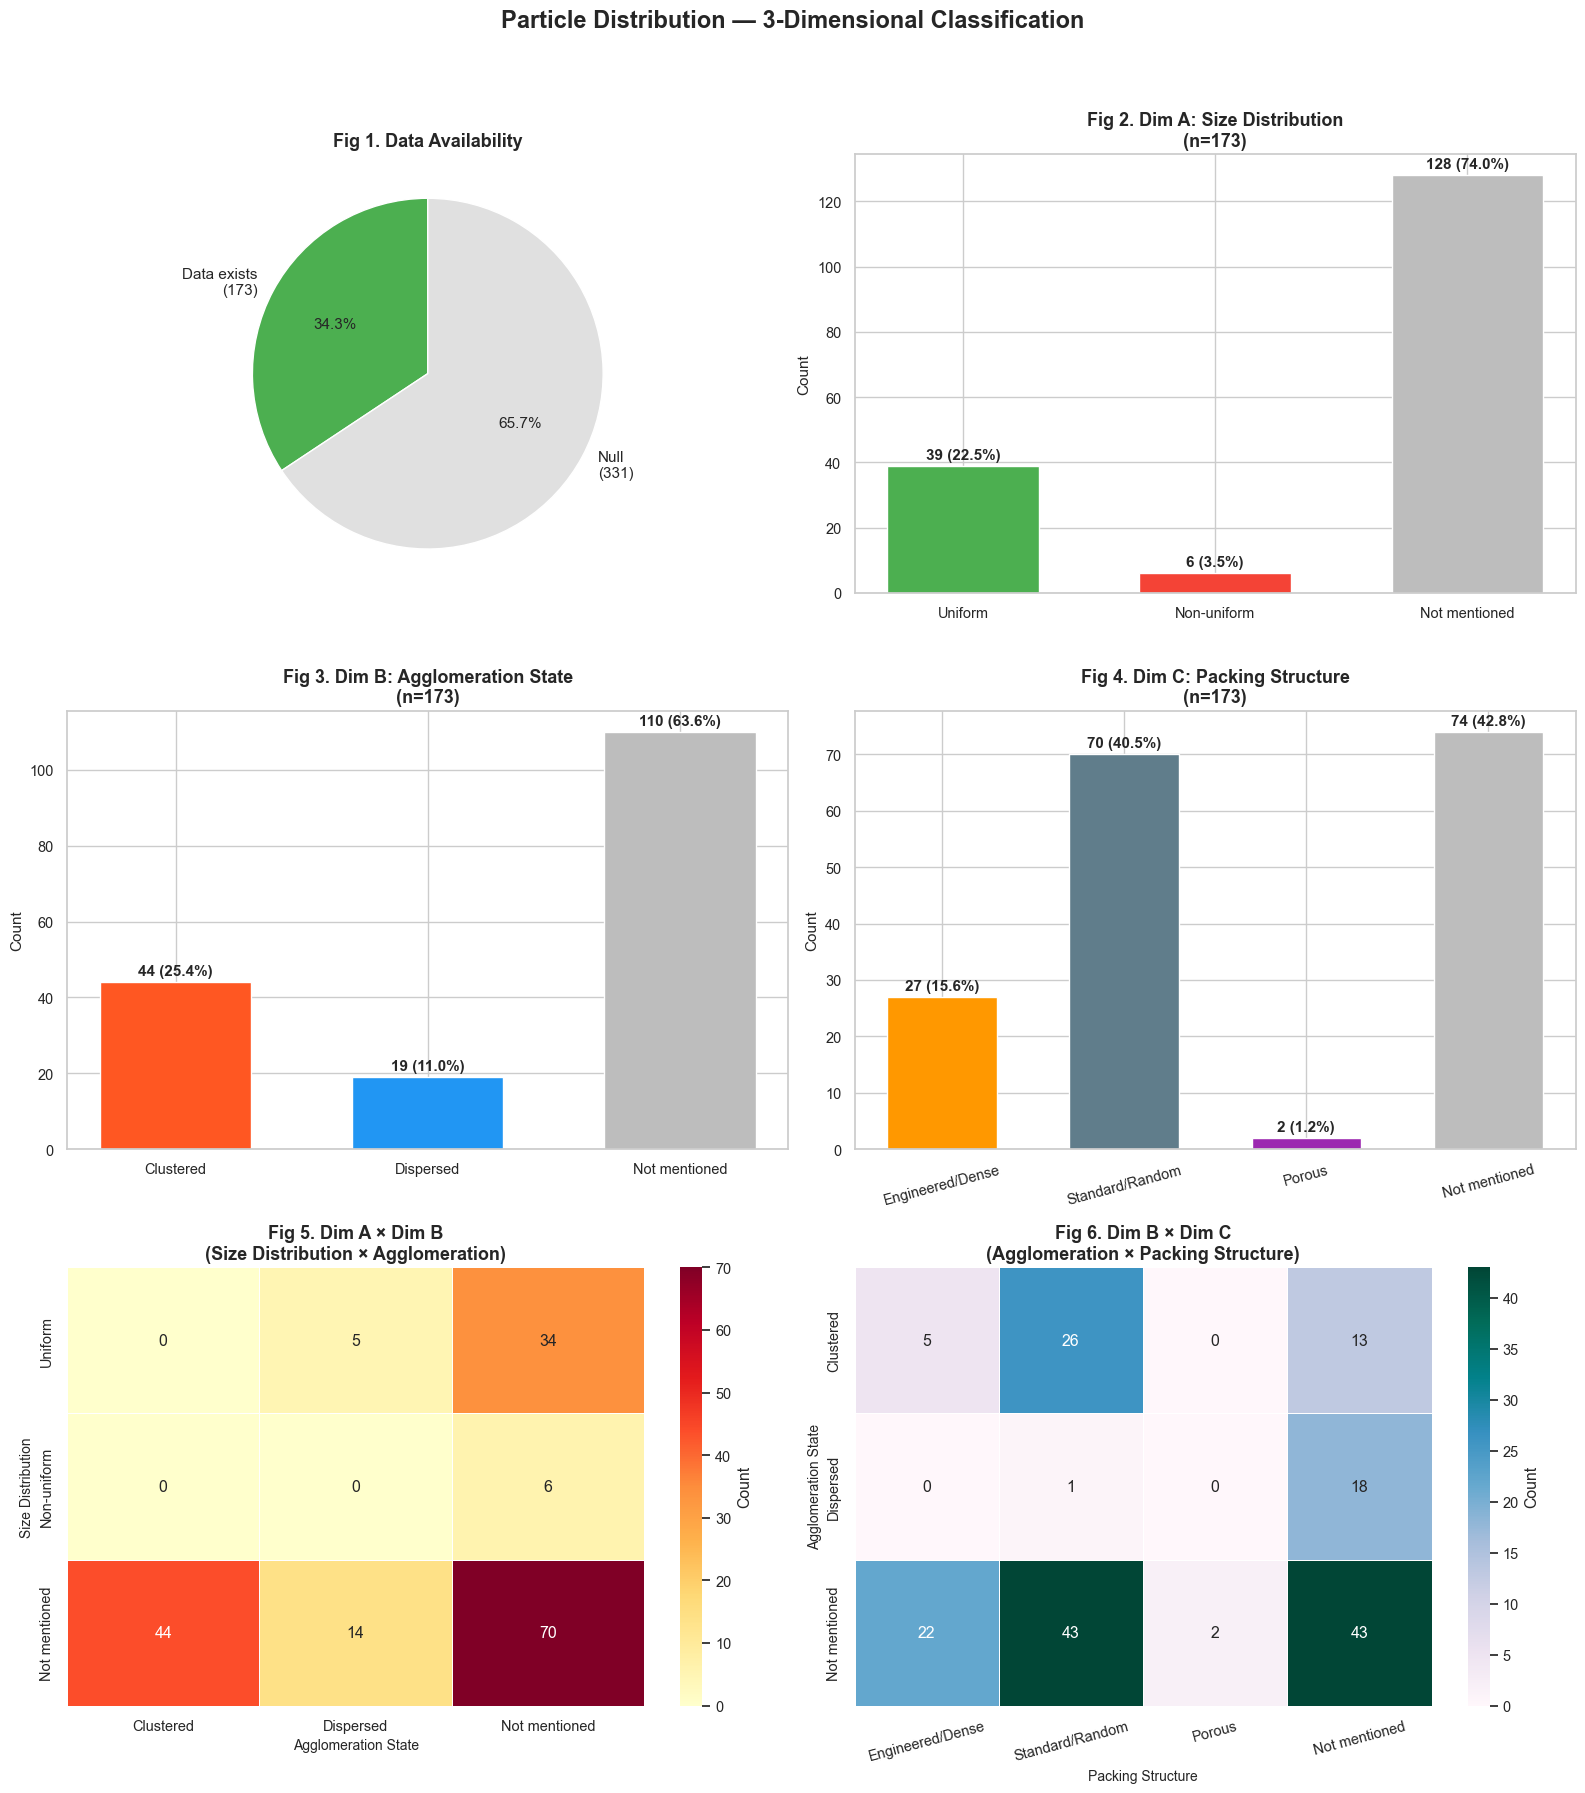

✅ 시각화 저장 완료: particle_distribution_analysis.png


In [14]:
# seaborn 테마 설정
sns.set_theme(style="whitegrid", font_scale=0.95)

# 3행 × 2열 = 6개 서브플롯 생성
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('Particle Distribution — 3-Dimensional Classification',
             fontsize=17, fontweight='bold', y=0.995)

# ── 색상 팔레트 정의 ──
color_A = {'Uniform': '#4CAF50', 'Non-uniform': '#F44336', 'Not mentioned': '#BDBDBD'}
color_B = {'Clustered': '#FF5722', 'Dispersed': '#2196F3', 'Not mentioned': '#BDBDBD'}
color_C = {'Engineered/Dense': '#FF9800', 'Standard/Random': '#607D8B', 
            'Porous': '#9C27B0', 'Not mentioned': '#BDBDBD'}


# ── Fig 1: 데이터 가용성 Pie Chart ──
ax1 = axes[0, 0]
avail_counts = [df[COL].notna().sum(), df[COL].isna().sum()]
avail_labels = [f'Data exists\n({avail_counts[0]})', f'Null\n({avail_counts[1]})']
ax1.pie(avail_counts, labels=avail_labels, autopct='%1.1f%%',
        colors=['#4CAF50', '#E0E0E0'], startangle=90, textprops={'fontsize': 11})
ax1.set_title('Fig 1. Data Availability', fontsize=13, fontweight='bold')


# ── Fig 2: 차원A 분포 ──
ax2 = axes[0, 1]
a_counts = df_valid['dist_size'].value_counts()
a_order = [x for x in ['Uniform', 'Non-uniform', 'Not mentioned'] if x in a_counts.index]
bars2 = ax2.bar(a_order, [a_counts[x] for x in a_order],
                color=[color_A[x] for x in a_order], edgecolor='white', width=0.6)
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{int(h)} ({int(h)/len(df_valid)*100:.1f}%)',
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold')
ax2.set_title('Fig 2. Dim A: Size Distribution\n(n=173)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11)


# ── Fig 3: 차원B 분포 ──
ax3 = axes[1, 0]
b_counts = df_valid['dist_agglomeration'].value_counts()
b_order = [x for x in ['Clustered', 'Dispersed', 'Not mentioned'] if x in b_counts.index]
bars3 = ax3.bar(b_order, [b_counts[x] for x in b_order],
                color=[color_B[x] for x in b_order], edgecolor='white', width=0.6)
for bar in bars3:
    h = bar.get_height()
    ax3.annotate(f'{int(h)} ({int(h)/len(df_valid)*100:.1f}%)',
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold')
ax3.set_title('Fig 3. Dim B: Agglomeration State\n(n=173)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Count', fontsize=11)


# ── Fig 4: 차원C 분포 ──
ax4 = axes[1, 1]
c_counts = df_valid['dist_packing'].value_counts()
c_order = [x for x in ['Engineered/Dense', 'Standard/Random', 'Porous', 'Not mentioned']
           if x in c_counts.index]
bars4 = ax4.bar(c_order, [c_counts[x] for x in c_order],
                color=[color_C[x] for x in c_order], edgecolor='white', width=0.6)
for bar in bars4:
    h = bar.get_height()
    ax4.annotate(f'{int(h)} ({int(h)/len(df_valid)*100:.1f}%)',
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold')
ax4.set_title('Fig 4. Dim C: Packing Structure\n(n=173)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Count', fontsize=11)
ax4.tick_params(axis='x', rotation=15)


# ── Fig 5: 차원A × 차원B 히트맵 ──
ax5 = axes[2, 0]
cross_ab_viz = pd.crosstab(df_valid['dist_size'], df_valid['dist_agglomeration'])
ab_row = [x for x in ['Uniform', 'Non-uniform', 'Not mentioned'] if x in cross_ab_viz.index]
ab_col = [x for x in ['Clustered', 'Dispersed', 'Not mentioned'] if x in cross_ab_viz.columns]
cross_ab_viz = cross_ab_viz.reindex(index=ab_row, columns=ab_col).fillna(0)
sns.heatmap(cross_ab_viz, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax5, cbar_kws={'label': 'Count'})
ax5.set_title('Fig 5. Dim A × Dim B\n(Size Distribution × Agglomeration)',
              fontsize=13, fontweight='bold')
ax5.set_xlabel('Agglomeration State', fontsize=10)
ax5.set_ylabel('Size Distribution', fontsize=10)


# ── Fig 6: 차원B × 차원C 히트맵 ──
ax6 = axes[2, 1]
cross_bc_viz = pd.crosstab(df_valid['dist_agglomeration'], df_valid['dist_packing'])
bc_row = [x for x in ['Clustered', 'Dispersed', 'Not mentioned'] if x in cross_bc_viz.index]
bc_col = [x for x in ['Engineered/Dense', 'Standard/Random', 'Porous', 'Not mentioned']
          if x in cross_bc_viz.columns]
cross_bc_viz = cross_bc_viz.reindex(index=bc_row, columns=bc_col).fillna(0)
sns.heatmap(cross_bc_viz, annot=True, fmt='.0f', cmap='PuBuGn',
            linewidths=0.5, ax=ax6, cbar_kws={'label': 'Count'})
ax6.set_title('Fig 6. Dim B × Dim C\n(Agglomeration × Packing Structure)',
              fontsize=13, fontweight='bold')
ax6.set_xlabel('Packing Structure', fontsize=10)
ax6.set_ylabel('Agglomeration State', fontsize=10)
ax6.tick_params(axis='x', rotation=15)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ 시각화 저장 완료: {OUTPUT_IMAGE}")

## 9. 💾 결과를 엑셀로 저장

| 시트 | 내용 |
|------|------|
| `preprocessed` | 원본 텍스트 + 3개 분류 결과 |
| `dimA_x_dimB` | 크기분포 × 응집상태 교차표 |
| `dimB_x_dimC` | 응집상태 × 충전구조 교차표 |
| `3d_combinations` | 3차원 조합 빈도표 |
| `classification_rules` | 분류 규칙 설명서 |

In [ ]:
with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:

    # Sheet 1: 전처리된 데이터
    cols_to_save = ['Paper ID', COL, 'dist_size', 'dist_agglomeration', 'dist_packing']
    save_cols = [c for c in cols_to_save if c in df.columns]
    df[save_cols].to_excel(writer, sheet_name='preprocessed', index=True)

    # Sheet 2: 차원A × 차원B 교차표
    cross_ab.to_excel(writer, sheet_name='dimA_x_dimB')

    # Sheet 3: 차원B × 차원C 교차표
    cross_bc.to_excel(writer, sheet_name='dimB_x_dimC')

    # Sheet 4: 3차원 조합 빈도표
    combo_counts = df_valid['combo_3d'].value_counts().reset_index()
    combo_counts.columns = ['Combination (A | B | C)', 'Count']
    combo_counts.to_excel(writer, sheet_name='3d_combinations', index=False)

    # Sheet 5: 분류 규칙 설명
    rules = pd.DataFrame([
        {'Dimension': 'A: Size Distribution', 'Category': 'Uniform',
         'Keywords': 'uniform, homogeneous, monodisperse, narrow, unimodal',
         'Description': '크기가 고르고 하나의 피크를 가지는 균일 분포'},
        {'Dimension': 'A: Size Distribution', 'Category': 'Non-uniform',
         'Keywords': 'broad, wide, polydisperse, bimodal',
         'Description': '크기가 제각각이거나 두 개 이상의 피크를 가지는 분포'},
        {'Dimension': 'B: Agglomeration', 'Category': 'Clustered',
         'Keywords': 'agglomerated, aggregated',
         'Description': '입자가 뭉쳐서 떡진 상태'},
        {'Dimension': 'B: Agglomeration', 'Category': 'Dispersed',
         'Keywords': 'well-dispersed, no agglomeration, evenly distributed',
         'Description': '입자가 고르게 잘 퍼진 상태'},
        {'Dimension': 'C: Packing Structure', 'Category': 'Engineered/Dense',
         'Keywords': 'densely packed, radially oriented, sintered, compact',
         'Description': '고밀도/배향성 구조 — 고성능 지표 ⭐'},
        {'Dimension': 'C: Packing Structure', 'Category': 'Standard/Random',
         'Keywords': 'composed of, consist of, primary particles, assembled',
         'Description': '일반적인 다결정 구조 (NCM 기본 형태)'},
        {'Dimension': 'C: Packing Structure', 'Category': 'Porous',
         'Keywords': 'porous, porosity, pore',
         'Description': '내부에 빈 공간이 많은 다공성 구조'},
    ])
    rules.to_excel(writer, sheet_name='classification_rules', index=False)

print(f"✅ 엑셀 저장 완료: {OUTPUT_EXCEL}")

## 10. 📊 핵심 인사이트 요약
[1] 데이터 가용성
    전체 504행 중 173행(34.3%)만 Particle distribution 정보가 있음.

[2] 차원A (크기 분포)
    Uniform 39건(22.5%) vs Non-uniform 6건(3.5%)
    → 74%가 미언급. 언급된 경우 Uniform이 압도적 (39 vs 6).

[3] 차원B (응집 상태)
    Clustered 44건(25.4%) vs Dispersed 19건(11.0%)
    → Clustered가 Dispersed보다 2.3배 많음.

[4] 차원C (충전 구조)
    Standard/Random 70건(40.5%) > Engineered/Dense 27건(15.6%) > Porous 2건(1.2%)
    → 약 15.6%만 고밀도/배향성 구조 (고성능 지표).

[5] 교차 패턴
    • Uniform + Clustered = 0건 → 균일한 입자는 뭉치지 않음
    • Clustered + Standard/Random = 26건 → 가장 흔한 NCM 구조 조합
    • Dispersed + Engineered/Dense = 0건 → 잘 분산된 입자와 치밀 구조는 동시에 보고되지 않음

### Coating layer characteristics

**핵심 로직:**
1. 데이터를 **인공 코팅(Artificial) / CEI / 코팅 없음 / 모호** 로 먼저 분리  
2. **Artificial 코팅(137건)** 에 대해서만 **Uniform / Non-uniform / Not mentioned** 3분류  
3. Coating Category(이전 전처리)와 교차 분석 + 4개 피겨 시각화

전체: 504행 | Coating layer characteristics non-null: 166행

--- coat_char_type 분포 ---
coat_char_type
NaN           338
artificial    137
ambiguous      14
no_coating     11
CEI             4

--- coat_uniformity 분포 (artificial만) ---
coat_uniformity
NaN              367
Not mentioned     81
Uniform           37
Non-uniform       19

Artificial 코팅 137건 중:
  Not mentioned: 81건 (59.1%)
  Uniform: 37건 (27.0%)
  Non-uniform: 19건 (13.9%)

📋 분류 결과 샘플 확인

--- [Uniform] (37건) — 처음 5건 ---
  Paper  13 | shiny and wetted, uniform and smooth coating layer of 4 nm
  Paper  16 | homogeneously coated by carbon with a thickness about 10 nm
  Paper  26 | uniform coating layer with a thickness of about 2.14 nm
  Paper  32 | homogeneous distribution of Al on the cathode surface, confirming the uniformity of the Al
  Paper  32 | homogeneous distribution of Al on the cathode surface, confirming the uniformity of the Al

--- [Non-uniform] (19건) — 처음 5건 ---
  Paper  38 | attached by PVDF loosely and partially
  P

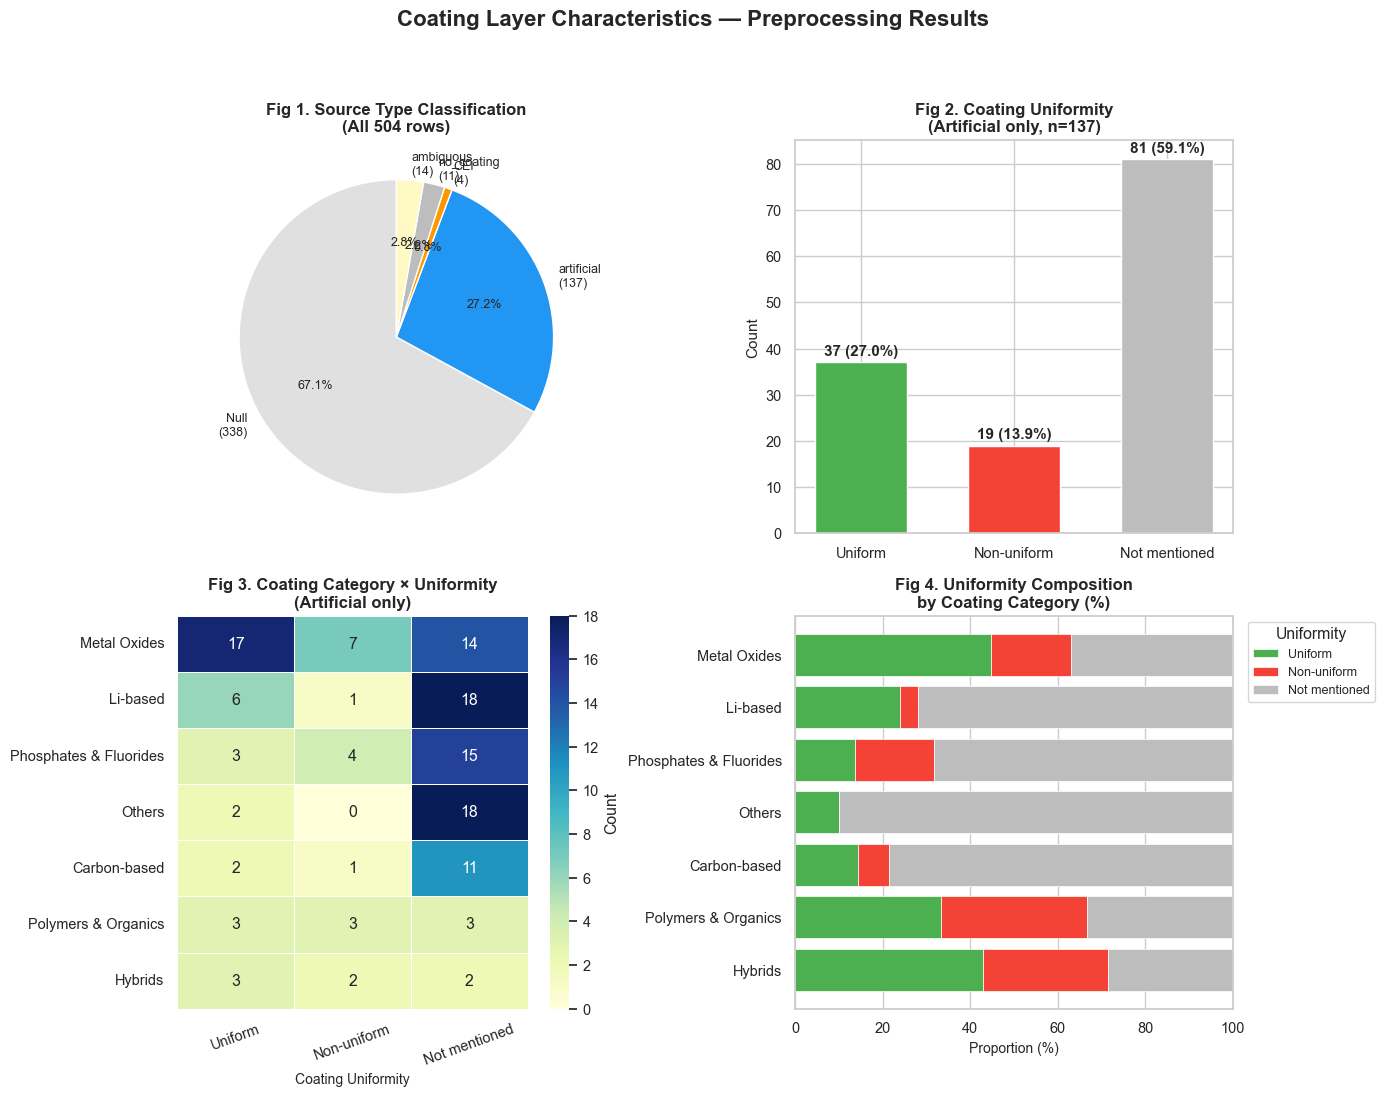


✅ 시각화 저장: coating_char_analysis.png
✅ 엑셀 저장: coating_char_preprocessed.xlsx

📊 요약
전체 504행 중 Coating layer characteristics 존재: 166행
  → Artificial coating으로 분류된 행: 137건
  → CEI: 4건
  → No coating: 11건
  → Yes only: 0건
  → Ambiguous: 14건

Artificial 137건 균일도 분류:
  Uniform: 37건 (27.0%)
  Non-uniform: 19건 (13.9%)
  Not mentioned: 81건 (59.1%)

✅ 완료!


In [1]:
# ============================================================
# 라이브러리 & 설정
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FILE_PATH = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
OUTPUT_EXCEL = "coating_char_preprocessed.xlsx"
OUTPUT_IMAGE = "coating_char_analysis.png"

# ============================================================
# 1. 데이터 로드
# ============================================================
df = pd.read_excel(FILE_PATH)
COL = 'Coating layer characteristics'
COAT_COL = 'Coating'

print(f"전체: {len(df)}행 | {COL} non-null: {df[COL].notna().sum()}행")

# ============================================================
# 2. Artificial Coating만 선별
# ============================================================
# CEI(자연 피막) 키워드 — 이것이 포함되면 인공 코팅이 아님
cei_keywords = [
    'cei', 'cathode electrolyte interphase', 'cathode-electrolyte interphase',
    'electrolyte interphase', 'sei', 'interphase', 'electrolyte film',
    'additive', 'blank electrolyte'
]

# 인공 코팅 물질명 키워드 — 이것이 포함되면 인공 코팅 확정
coating_material_keywords = [
    'al2o3', 'zro2', 'tio2', 'li3po4', 'linbo3', 'lialo2',
    'alf3', 'lif', 'sio2', 'co3o4', 'carbon', 'graphene',
    'rgo', 'pvdf', 'ppy', 'latp', 'cnt', 'mwcnt',
    'polymer', 'eps', 'li2zro3', 'li3vo4', 'lwo',
    'mn3(po4)2', 'mnpo4', 'ceo2', 'cr3o2', 'libo2',
    'ag', 'silver', 'hec', 'nanosheet'
]

# 코팅 없음 키워드
no_coating_keywords = [
    'no coating', 'no coatings', 'not present', 'without any layer',
    'no film', 'no apparent coating', 'without any extra film',
    'without any residue', 'smooth edge without', 'not observed any visible',
    'smooth edge line without', 'smooth surface without'
]

def classify_source_type(row):
    text = row[COL]
    coating_val = row[COAT_COL]

    if pd.isna(text):
        return np.nan

    t = str(text).lower().strip()

    # "Yes"만 적힌 경우 → Coating 열에 물질명이 있으면 artificial
    if t in ['yes', 'coated', 'multi-element coated']:
        return 'artificial' if pd.notna(coating_val) else 'yes_only'

    # 코팅 없음 명시
    if any(kw in t for kw in no_coating_keywords):
        return 'no_coating'

    # CEI 확정 (CEI 키워드 있고, 코팅 물질명은 없는 경우)
    is_cei = any(kw in t for kw in cei_keywords)
    is_material = any(kw in t for kw in coating_material_keywords)

    if is_cei and not is_material:
        return 'CEI'

    # 코팅 물질명이 텍스트에 있으면 → artificial
    if is_material:
        return 'artificial'

    # Coating 열에 물질명이 있으면 → artificial (텍스트에 물질명은 없지만 코팅된 샘플)
    if pd.notna(coating_val):
        return 'artificial'

    # 그 외 → ambiguous
    return 'ambiguous'

df['coat_char_type'] = df.apply(classify_source_type, axis=1)

# 분류 결과 출력
print("\n--- coat_char_type 분포 ---")
print(df['coat_char_type'].value_counts(dropna=False).to_string())

# ============================================================
# 3. Artificial 코팅만 필터 → Uniform / Non-uniform / Not mentioned
# ============================================================
# Uniform 키워드
uniform_keywords = [
    'uniform', 'homogeneous', 'homogenous', 'conformal',
    'evenly distributed', 'well dispersed', 'well coated',
    'uniformly', 'complete and uniform', 'uniform and smooth',
    'uniformly covered', 'uniformly presented'
]

# Non-uniform 키워드
non_uniform_keywords = [
    'non-uniform', 'nonuniform', 'inhomogeneous', 'inhomogeneously',
    'uneven', 'non-uniformly', 'randomly coated', 'partially',
    'loosely', 'not attached', 'island-type', 'scattered',
    'bare parts', 'could not be observed easily', 'thick and uneven',
    'thicker and unsmooth', 'rough and porous', 'fuzzy'
]

def classify_uniformity(row):
    # artificial이 아닌 행은 NaN
    if row['coat_char_type'] != 'artificial':
        return np.nan

    text = row[COL]
    if pd.isna(text):
        return np.nan

    t = str(text).lower().strip()

    # "Yes"만 적힌 경우 → 특성 기술 없음
    if t in ['yes', 'coated', 'multi-element coated']:
        return 'Not mentioned'

    is_uniform = any(kw in t for kw in uniform_keywords)
    is_non_uniform = any(kw in t for kw in non_uniform_keywords)

    # 부정형 우선 (non-uniform이 있으면 uniform 키워드가 있어도 non-uniform)
    if is_non_uniform:
        return 'Non-uniform'
    elif is_uniform:
        return 'Uniform'
    else:
        return 'Not mentioned'

df['coat_uniformity'] = df.apply(classify_uniformity, axis=1)

# 결과 출력
print("\n--- coat_uniformity 분포 (artificial만) ---")
print(df['coat_uniformity'].value_counts(dropna=False).to_string())

# artificial 행만 따로 보기
df_art = df[df['coat_char_type'] == 'artificial'].copy()
print(f"\nArtificial 코팅 {len(df_art)}건 중:")
for val, cnt in df_art['coat_uniformity'].value_counts().items():
    print(f"  {val}: {cnt}건 ({cnt/len(df_art)*100:.1f}%)")

# ============================================================
# 4. 분류 결과 샘플 확인
# ============================================================
print(f"\n{'='*60}")
print("📋 분류 결과 샘플 확인")
print(f"{'='*60}")

for label in ['Uniform', 'Non-uniform', 'Not mentioned']:
    subset = df_art[df_art['coat_uniformity'] == label]
    print(f"\n--- [{label}] ({len(subset)}건) — 처음 5건 ---")
    for _, row in subset.head(5).iterrows():
        text = str(row[COL])[:90]
        print(f"  Paper {row.get('Paper ID','?'):>3} | {text}")

# ============================================================
# 5. 시각화 (4개 피겨)
# ============================================================
sns.set_theme(style="whitegrid", font_scale=0.95)
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Coating Layer Characteristics — Preprocessing Results',
             fontsize=16, fontweight='bold', y=0.995)

color_type = {
    'artificial': '#2196F3', 'CEI': '#FF9800', 'no_coating': '#BDBDBD',
    'yes_only': '#E0E0E0', 'ambiguous': '#FFF9C4'
}
color_unif = {
    'Uniform': '#4CAF50', 'Non-uniform': '#F44336', 'Not mentioned': '#BDBDBD'
}

# ── Fig 1: 데이터 가용성 + 소스 타입 (Pie) ──
ax1 = axes[0, 0]
type_counts = df['coat_char_type'].value_counts(dropna=False)
labels_1, sizes_1, colors_1 = [], [], []
for val in [np.nan, 'artificial', 'CEI', 'no_coating', 'yes_only', 'ambiguous']:
    if val is np.nan:
        cnt = type_counts.get(np.nan, 0)
        if cnt == 0:
            cnt = df[COL].isna().sum()
        labels_1.append(f'Null\n({cnt})')
        sizes_1.append(cnt)
        colors_1.append('#E0E0E0')
    elif val in type_counts.index:
        cnt = type_counts[val]
        labels_1.append(f'{val}\n({cnt})')
        sizes_1.append(cnt)
        colors_1.append(color_type.get(val, '#888'))

ax1.pie(sizes_1, labels=labels_1, autopct='%1.1f%%', colors=colors_1,
        startangle=90, textprops={'fontsize': 9})
ax1.set_title('Fig 1. Source Type Classification\n(All 504 rows)', fontsize=12, fontweight='bold')

# ── Fig 2: Artificial 코팅 균일도 (Bar) ──
ax2 = axes[0, 1]
unif_counts = df_art['coat_uniformity'].value_counts()
u_order = ['Uniform', 'Non-uniform', 'Not mentioned']
u_order = [x for x in u_order if x in unif_counts.index]

bars2 = ax2.bar(u_order, [unif_counts[x] for x in u_order],
                color=[color_unif[x] for x in u_order], edgecolor='white', width=0.6)
for bar in bars2:
    h = bar.get_height()
    ax2.annotate(f'{int(h)} ({int(h)/len(df_art)*100:.1f}%)',
                 xy=(bar.get_x() + bar.get_width()/2, h),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', fontsize=11, fontweight='bold')
ax2.set_title(f'Fig 2. Coating Uniformity\n(Artificial only, n={len(df_art)})',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=11)

# ── Fig 3: Coating Category × Uniformity 교차 히트맵 ──
ax3 = axes[1, 0]

# 이전에 만든 coating_category가 없으면 여기서 빠르게 만듦
coating_mapping = {
    'Al2O3': 'Metal Oxides', 'ZrO2': 'Metal Oxides', 'TiO2': 'Metal Oxides',
    'Co3O4': 'Metal Oxides', 'SiO2': 'Metal Oxides', 'Co oxide': 'Metal Oxides',
    'WO3': 'Metal Oxides', 'B2O3': 'Metal Oxides', 'Cr3O2': 'Metal Oxides',
    'CeO2': 'Metal Oxides', 'ZnO': 'Metal Oxides', 'La2O3': 'Metal Oxides',
    'LiNbO3': 'Li-based', 'LiAlO2': 'Li-based', 'Li3VO4': 'Li-based',
    'Li2ZrO3': 'Li-based', 'LSTP': 'Li-based', 'Li4Ti5O12': 'Li-based',
    'Li2SO4/Li2SO3': 'Li-based', 'lithium tungsten oxide': 'Li-based',
    'Li2TiO3-Li2ZrO3': 'Li-based', 'LiAlO2, Al2O3': 'Li-based',
    'Li2TiO3': 'Li-based', 'LiNO3': 'Li-based', 'Al2O3/LiAlO2': 'Li-based',
    'Li5AlO4': 'Li-based', 'Na5AlO4': 'Li-based', 'LiBO2/LiAlO2': 'Li-based',
    'Li3BO3': 'Li-based', 'LiBO2': 'Li-based', 'NCA': 'Li-based',
    'Li3PO4': 'Phosphates & Fluorides', 'MnPO4': 'Phosphates & Fluorides',
    'LiF': 'Phosphates & Fluorides', 'AlF3': 'Phosphates & Fluorides',
    'CaF2': 'Phosphates & Fluorides', 'Mn3(PO4)2': 'Phosphates & Fluorides',
    'LATP': 'Phosphates & Fluorides',
    'carbon': 'Carbon-based', 'RGO': 'Carbon-based', 'g-C3N4': 'Carbon-based',
    'AHNS-rGO': 'Carbon-based', 'AHNS-rGO/CNT': 'Carbon-based',
    'EPS': 'Polymers & Organics', 'PPy': 'Polymers & Organics',
    'PAN': 'Polymers & Organics', 'PVDF': 'Polymers & Organics',
    'MPDMS': 'Polymers & Organics', '(H2AlOtBu)2': 'Polymers & Organics',
    '(H2AlOtBu)2, HF': 'Polymers & Organics',
    'TiO2-Ag': 'Hybrids', 'LATP, CNT': 'Hybrids',
    'Li3PO4, PPy': 'Hybrids', 'polymer/γ-Al2O3': 'Hybrids',
    'yes': 'Others', 'unspecified': 'Others', 'Al': 'Others', 'Ag': 'Others',
    'Ge-132': 'Others', 'Hec': 'Others',
    'concentration-gradient shell': 'Others', 'multi-element': 'Others',
    'boric acid': 'Others'
}
if 'coating_category' not in df.columns:
    df['coating_category'] = df[COAT_COL].replace(coating_mapping)
    valid_cats = list(set(coating_mapping.values()))
    unmapped = df[COAT_COL].notna() & ~df['coating_category'].isin(valid_cats)
    df.loc[unmapped, 'coating_category'] = 'Others'

# 교차표 (artificial + coating_category 있는 것만)
df_cross = df[(df['coat_char_type'] == 'artificial') & df['coating_category'].notna()].copy()
if len(df_cross) > 0:
    cross_hm = pd.crosstab(df_cross['coating_category'], df_cross['coat_uniformity'])
    coat_order = cross_hm.sum(axis=1).sort_values(ascending=False).index.tolist()
    u_col_order = [x for x in ['Uniform', 'Non-uniform', 'Not mentioned'] if x in cross_hm.columns]
    cross_hm = cross_hm.reindex(index=coat_order, columns=u_col_order).fillna(0)

    sns.heatmap(cross_hm, annot=True, fmt='.0f', cmap='YlGnBu',
                linewidths=0.5, ax=ax3, cbar_kws={'label': 'Count'})
    ax3.set_title('Fig 3. Coating Category × Uniformity\n(Artificial only)',
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Coating Uniformity', fontsize=10)
    ax3.set_ylabel('')
    ax3.tick_params(axis='x', rotation=20)
else:
    ax3.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
    ax3.set_title('Fig 3. Coating Category × Uniformity', fontsize=12, fontweight='bold')

# ── Fig 4: Uniform 비율 by Coating Category (%) ──
ax4 = axes[1, 1]
if len(df_cross) > 0:
    cross_pct = pd.crosstab(df_cross['coating_category'], df_cross['coat_uniformity'],
                            normalize='index').round(3) * 100
    cross_pct = cross_pct.reindex(index=coat_order, columns=u_col_order).fillna(0)

    # Stacked bar
    bottom = np.zeros(len(coat_order))
    for u_cat in u_col_order:
        if u_cat in cross_pct.columns:
            vals = cross_pct[u_cat].values
            ax4.barh(coat_order, vals, left=bottom, label=u_cat,
                     color=color_unif.get(u_cat, '#888'), edgecolor='white', linewidth=0.5)
            bottom += vals

    ax4.set_xlim(0, 100)
    ax4.set_xlabel('Proportion (%)', fontsize=10)
    ax4.set_title('Fig 4. Uniformity Composition\nby Coating Category (%)',
                  fontsize=12, fontweight='bold')
    ax4.legend(title='Uniformity', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax4.invert_yaxis()
else:
    ax4.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=14)
    ax4.set_title('Fig 4. Uniformity by Coating Category', fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✅ 시각화 저장: {OUTPUT_IMAGE}")

# ============================================================
# 6. 엑셀 저장
# ============================================================
with pd.ExcelWriter(OUTPUT_EXCEL, engine='openpyxl') as writer:
    cols_save = ['Paper ID', COAT_COL, 'coating_category', COL,
                 'coat_char_type', 'coat_uniformity']
    save_cols = [c for c in cols_save if c in df.columns]
    df[save_cols].to_excel(writer, sheet_name='preprocessed', index=True)

    if len(df_cross) > 0:
        cross_hm.to_excel(writer, sheet_name='category_x_uniformity')

print(f"✅ 엑셀 저장: {OUTPUT_EXCEL}")

# ============================================================
# 7. 요약
# ============================================================
print(f"\n{'='*60}")
print("📊 요약")
print(f"{'='*60}")
print(f"전체 504행 중 Coating layer characteristics 존재: {df[COL].notna().sum()}행")
print(f"  → Artificial coating으로 분류된 행: {len(df_art)}건")
print(f"  → CEI: {(df['coat_char_type']=='CEI').sum()}건")
print(f"  → No coating: {(df['coat_char_type']=='no_coating').sum()}건")
print(f"  → Yes only: {(df['coat_char_type']=='yes_only').sum()}건")
print(f"  → Ambiguous: {(df['coat_char_type']=='ambiguous').sum()}건")
print(f"\nArtificial {len(df_art)}건 균일도 분류:")
for val in ['Uniform', 'Non-uniform', 'Not mentioned']:
    cnt = (df_art['coat_uniformity'] == val).sum()
    print(f"  {val}: {cnt}건 ({cnt/len(df_art)*100:.1f}%)")
print("\n✅ 완료!")

### Crystal structure and lattice characteristics

생성 피처 예시:
- `Struct_Type`: `Normal layered / Degraded phase / Other explicit structure / Missing`
- `Ordered_Flag`, `Disordered_Flag`
- `Crystal_Form`: `single / poly / highly_crystalline / amorphous / none`
- `Degradation_Phase`
- `Secondary_Phase_Present`
- `Plane_003`, `Plane_104`, `Plane_101`
- `d003_nm`, `d104_nm`, `d101_nm`

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid", font="DejaVu Sans")

# ===== 파일 자동 탐색 =====
# 우선순위: 직접 지정 > 현재 폴더의 xlsx 탐색
FILE_PATH = "multiagent-rag_142편 추출(34제외)-전처리본.xlsx"
TARGET_COL = "Crystal structure and lattice characteristics"

if FILE_PATH is None:
    xlsx_candidates = sorted(Path.cwd().glob("*.xlsx"))
    if not xlsx_candidates:
        raise FileNotFoundError("현재 폴더에 xlsx 파일이 없습니다. FILE_PATH를 직접 지정해주세요.")
    FILE_PATH = str(xlsx_candidates[0])

excel_file = pd.ExcelFile(FILE_PATH)
sheet_name = excel_file.sheet_names[0]
df = pd.read_excel(FILE_PATH, sheet_name=sheet_name)

print(f"파일: {FILE_PATH}")
print(f"시트: {sheet_name}")
print(f"shape: {df.shape}")
print(f"대상 열 존재 여부: {TARGET_COL in df.columns}")

if TARGET_COL not in df.columns:
    raise KeyError(f"'{TARGET_COL}' 열이 없습니다. 실제 열 이름을 확인해주세요.")

raw = df[TARGET_COL].copy()
nonempty = raw.dropna().astype(str)
nonempty = nonempty[nonempty.str.strip() != ""]

summary = pd.DataFrame({
    "metric": ["전체 행 수", "비어있지 않은 행 수", "빈 행 수", "고유 비어있지 않은 값 수"],
    "value": [len(df), len(nonempty), len(df) - len(nonempty), nonempty.nunique()]
})

display(summary)
print("\n상위 빈도 값 TOP 15")
display(nonempty.value_counts().head(15).rename_axis("text").reset_index(name="count"))

print("\n샘플 10개")
display(df[[TARGET_COL]].dropna().head(10))


파일: multiagent-rag_142편 추출(34제외)-전처리본.xlsx
시트: multiagent-rag_143편 추출(34,75,11
shape: (504, 75)
대상 열 존재 여부: True


,metric,value
0,전체 행 수,504
1,비어있지 않은 행 수,140
2,빈 행 수,364
3,고유 비어있지 않은 값 수,111



상위 빈도 값 TOP 15


,text,count
0,"well-developed layered crystalline structure of α-NaFeO2-type (space group R3m̅, Z = 3)",6
1,"lattice spacing of 0.352 nm, corresponding to the (-111) crystal plane of the Li2MnO3 phase",4
2,layered hexagonal α-NaFeO2 structure with the space group R-3m,4
3,"ordered layer structures, in which the lattice spaces of 0.20 nm is the [104] planes of layer structure",3
4,hexagonal lattice having R ̄3m space group,3
5,inter-planar distances of 0.47 nm and 0.24 nm which are assigned to the (003) and (101) crystal planes,3
6,highly disordered indicating for a polycrystalline structure,2
7,transformation of the original R3m layered structure into a NiO-type Fm3m rock-salt phase,2
8,"α-NaFeO2 structure (space group: R-3m, JCPDS 89-3601), typical layered structure",2
9,"well-ordered atomic columns and the atomic columns are separated by a distance of 0.47, which is well indexed to the (003)Hex plane of LiMnO2 and/or the (001)Mon plane of Li2MnO3",2



샘플 10개


,Crystal structure and lattice characteristics
1,lattice spacing of 0.483 nm corresponds to the (003) crystal plane
4,similar lattice fringe displayed on the HR-TEM image is consistent with the XRD data related to the (003) plane of the layered structure having an interplanar distance of 0.45
9,a-NaFeO2 structure with space group R-3m
10,a-NaFeO2 structure with space group R-3m
13,thick rock-salt phase over 20 nm
16,2 nm thick rock-salt phase
17,transformation of the R3̅m layered to the Fm3̅m rock-salt (NiO) structure at the surface of the NCM-811 primary particles
18,rhombohedral layered structure with space group R3m
19,"clear and uniform interplanar distances, and the magnified interplanar distance is measured to be 0.47 nm, corresponding to the (003) crystal planes of the layered structure"
56,crystal structure with the lattice fringes extended to the edges


In [3]:
# ===== 전처리 함수 =====
def clean_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if not x:
        return ""
    x = x.replace("−", "-").replace("–", "-").replace("—", "-")
    x = x.replace("Å", " A").replace("Å", " A")
    x = x.replace("α", "alpha").replace("β", "beta")
    x = re.sub(r"\s+", " ", x)
    return x.lower()


def has_any(text, keywords):
    return any(k in text for k in keywords)


def parse_struct_type(text):
    if text == "":
        return "Missing"

    # 열화 및 상전이 (스피넬, 암염, 양이온 혼합 관련 모든 표현)
    degraded_keywords = [
        "rock-salt", "rock salt", "rocksalt", "nio-type", "nio-like", "nio phase", 
        "fm-3m", "fm3m", "fm 3 m", "fcc", "cubic phase",
        "spinel", "fd-3m", "fd3m", "fd 3 m", 
        "transformation", "turned into rock-salt", "phase transition", "structural degradation",
        "cation mixing", "li/ni mixing", "ni migration"
    ]
    
    # 2차상 및 특수 구조 (단사정계, 불순물, 코팅상 등)
    other_keywords = [
        "monoclinic", "c2/m", "p21/c", "olivine", "amorphous",
        "li2mno3", "li2so4", "lino3 phase", "li5alo4", "na5alo4", "al2o3",
        "secondary phase", "impurity", "impurities", "residual lithium"
    ]
    
    # 정상 NCM 층상 구조 (띄어쓰기 변형 및 O3-type 등 추가)
    layered_keywords = [
        "layered", "alpha-nafeo2", "a-nafeo2", "rhombohedral",
        "hexagonal", "r-3m", "r3m", "r-3 m", "r 3 m", "ncm-layered", 
        "o3-type", "o3 type", "layered oxide"
    ]

    if has_any(text, degraded_keywords):
        return "Degraded phase"
    if has_any(text, other_keywords):
        return "Other explicit structure"
    if has_any(text, layered_keywords):
        return "Normal layered"
        
    return "Other explicit structure"


def parse_order_status(text):
    if text == "" or pd.isna(text):
        return "Not mentioned"
    
    # 1. 긍정적 키워드 (질서 있음)
    ordered_patterns = [
        r"well-ordered", r"well ordered", r"highly ordered", r"high degree of ordering",
        r"well-developed", r"well developed", r"ordered lattice", r"ordered layer", 
        r"well-maintained", r"neatly arranged", r"clear lattice", r"distinct lattice",
        r"low cation mixing"
    ]
    is_ordered = any(re.search(p, text) for p in ordered_patterns)
    
    # 2. 부정적 키워드 (무질서/결함 있음)
    disordered_patterns = [
        r"disordered", r"highly disordered", r"severe disorder", r"suffered severe disorder",
        r"confused and have different orientations", r"outer layers are confused",
        r"defect", r"stacking fault", r"lattice distortion", r"structural defect",
        r"cation mixing", r"li/ni mixing"
    ]
    is_disordered = any(re.search(p, text) for p in disordered_patterns)
    
    # 3. 카테고리 분류 로직 (Mixed -> Disordered 병합)
    if is_disordered:
        return "Disordered"    # 부정적 키워드가 하나라도 있으면 무조건 Disordered!
    elif is_ordered:
        return "Ordered"       # 부정적 키워드 없이 긍정적 키워드만 있을 때
    else:
        return "Not mentioned" # 아무 언급 없음



def parse_crystal_form(text):
    if text == "":
        return "none"
        
    if has_any(text, ["single crystalline", "single-crystalline", "single crystals", "single crystal", "single-crystalline feature", "monocrystal"]):
        return "single"
        
    if has_any(text, ["polycrystalline", "poly crystalline", "poly-crystalline"]):
        return "poly"
        
    if has_any(text, ["amorphous", "non-crystalline"]):
        return "amorphous"
        
    # 결정성이 훌륭하다는 일반적인 묘사들
    if has_any(text, ["highly crystalline", "good crystallinity", "crystalline nature", "excellent crystallinity", "high crystallinity"]):
        return "highly_crystalline"
        
    return "none"


def parse_degradation(text):
    # 상전이/열화를 1(Yes)로 잡기 위한 훨씬 더 촘촘한 그물망
    degraded_keywords = [
        "rock-salt", "rock salt", "rocksalt", "spinel", "cation mixing", "li/ni mixing", "ni migration",
        "turned into rock-salt", "transformation of the original r3m layered structure into",
        "transformation of the r3m layered to", "thickness of the rock salt phase",
        "thick rock-salt phase", "thin rock-salt phase layer", "rock salt layer",
        "structural degradation", "phase transition", "structural collapse", "lattice distortion"
    ]
    return int(has_any(text, degraded_keywords))


def parse_secondary_phase(text):
    secondary_keywords = [
        "li2mno3", "li2so4", "lino3 phase", "wo3", "al2o3", "li5alo4", "na5alo4", "li3po4",
        "coating layer", "surface layer", "surface film", "secondary phase", "secondary phases", 
        "impurities", "impurity", "residual", "unreacted", "parasitic phase"
    ]
    return int(has_any(text, secondary_keywords))


def plane_flag(text, plane):
    plane_patterns = {
        "003": [r"\(003\)", r"\(0 0 3\)", r"d003", r"001 and 003 lattice fringes"],
        "104": [r"\(104\)", r"\(1 0 4\)", r"\[104\]", r"104 planes"],
        "101": [r"\(101\)", r"\(1 0 1\)", r"101 planes", r"active facet", r"facets"]
    }
    return int(any(re.search(p, text) for p in plane_patterns[plane]))


def normalize_nm(value):
    if value is None or pd.isna(value):
        return np.nan
    value = float(value)
    if value > 1.2:   # Å로 추정되면 nm로 환산
        value = value / 10.0
    return round(value, 4)


def extract_d_spacing(text, plane):
    if text == "":
        return np.nan

    plane_patterns = {
        "003": r"(?:\(003\)|\(0 0 3\)|d003)",
        "104": r"(?:\(104\)|\(1 0 4\))",
        "101": r"(?:\(101\)|\(1 0 1\))"
    }
    p = plane_patterns[plane]
    num = r"(\d+(?:\.\d+)?)"

    patterns = [
        rf"{num}\s*(?:nm|a)?[^.;\n]{{0,60}}{p}",
        rf"{p}[^.;\n]{{0,60}}{num}\s*(?:nm|a)?",
    ]

    candidates = []
    for pat in patterns:
        for m in re.finditer(pat, text):
            for g in m.groups():
                try:
                    candidates.append(normalize_nm(float(g)))
                except Exception:
                    pass

    # plane별 대략적인 허용 범위
    ranges = {
        "003": (0.35, 0.60),
        "104": (0.15, 0.30),
        "101": (0.18, 0.35),
    }
    lo, hi = ranges[plane]
    candidates = [c for c in candidates if pd.notna(c) and lo <= c <= hi]

    if not candidates:
        return np.nan
    return candidates[0]


work = df.copy()
work["_text_clean"] = work[TARGET_COL].apply(clean_text)

work["Struct_Type"] = work["_text_clean"].apply(parse_struct_type)
work["Order_Status"] = work["_text_clean"].apply(parse_order_status)
work["Crystal_Form"] = work["_text_clean"].apply(parse_crystal_form)
work["Degradation_Phase"] = work["_text_clean"].apply(parse_degradation)
work["Secondary_Phase_Present"] = work["_text_clean"].apply(parse_secondary_phase)

for plane in ["003", "104", "101"]:
    work[f"Plane_{plane}"] = work["_text_clean"].apply(lambda x: plane_flag(x, plane))
    work[f"d{plane}_nm"] = work["_text_clean"].apply(lambda x: extract_d_spacing(x, plane))

preview_cols = [
    TARGET_COL, "Struct_Type", "Order_Status", "Crystal_Form",
    "Degradation_Phase", "Secondary_Phase_Present", "Plane_003", "Plane_104",
    "Plane_101", "d003_nm", "d104_nm", "d101_nm"
]

print("전처리 결과 샘플")
display(work[preview_cols].head(20))

print("\n카테고리 분포")
display(work["Struct_Type"].value_counts(dropna=False).rename_axis("Struct_Type").reset_index(name="count"))
display(work["Crystal_Form"].value_counts(dropna=False).rename_axis("Crystal_Form").reset_index(name="count"))


전처리 결과 샘플


,Crystal structure and lattice characteristics,Struct_Type,Order_Status,Crystal_Form,Degradation_Phase,Secondary_Phase_Present,Plane_003,Plane_104,Plane_101,d003_nm,d104_nm,d101_nm
0,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
1,lattice spacing of 0.483 nm corresponds to the (003) crystal plane,Other explicit structure,Not mentioned,none,0,0,1,0,0,0.483,NaN,NaN
2,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
3,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
4,similar lattice fringe displayed on the HR-TEM image is consistent with the XRD data related to the (003) plane of the layered structure having an interplanar distance of 0.45,Normal layered,Not mentioned,none,0,0,1,0,0,NaN,NaN,NaN
5,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
6,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
7,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
8,NaN,Missing,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN
9,a-NaFeO2 structure with space group R-3m,Normal layered,Not mentioned,none,0,0,0,0,0,NaN,NaN,NaN



카테고리 분포


,Struct_Type,count
0,Missing,364
1,Other explicit structure,68
2,Normal layered,52
3,Degraded phase,20


,Crystal_Form,count
0,none,489
1,single,6
2,highly_crystalline,4
3,poly,3
4,amorphous,2


C:\Users\LECS\AppData\Local\Temp\ipykernel_2916\3966377303.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=work, y="Struct_Type", order=struct_order,
C:\Users\LECS\AppData\Local\Temp\ipykernel_2916\3966377303.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=work, x="Order_Status", order=order_cats,
C:\Users\LECS\AppData\Local\Temp\ipykernel_2916\3966377303.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=work, y="Crystal_Form", order=crystal_order,
C:\Users\LECS\AppData\Local\Temp\ipykernel_2916\3966377303.p

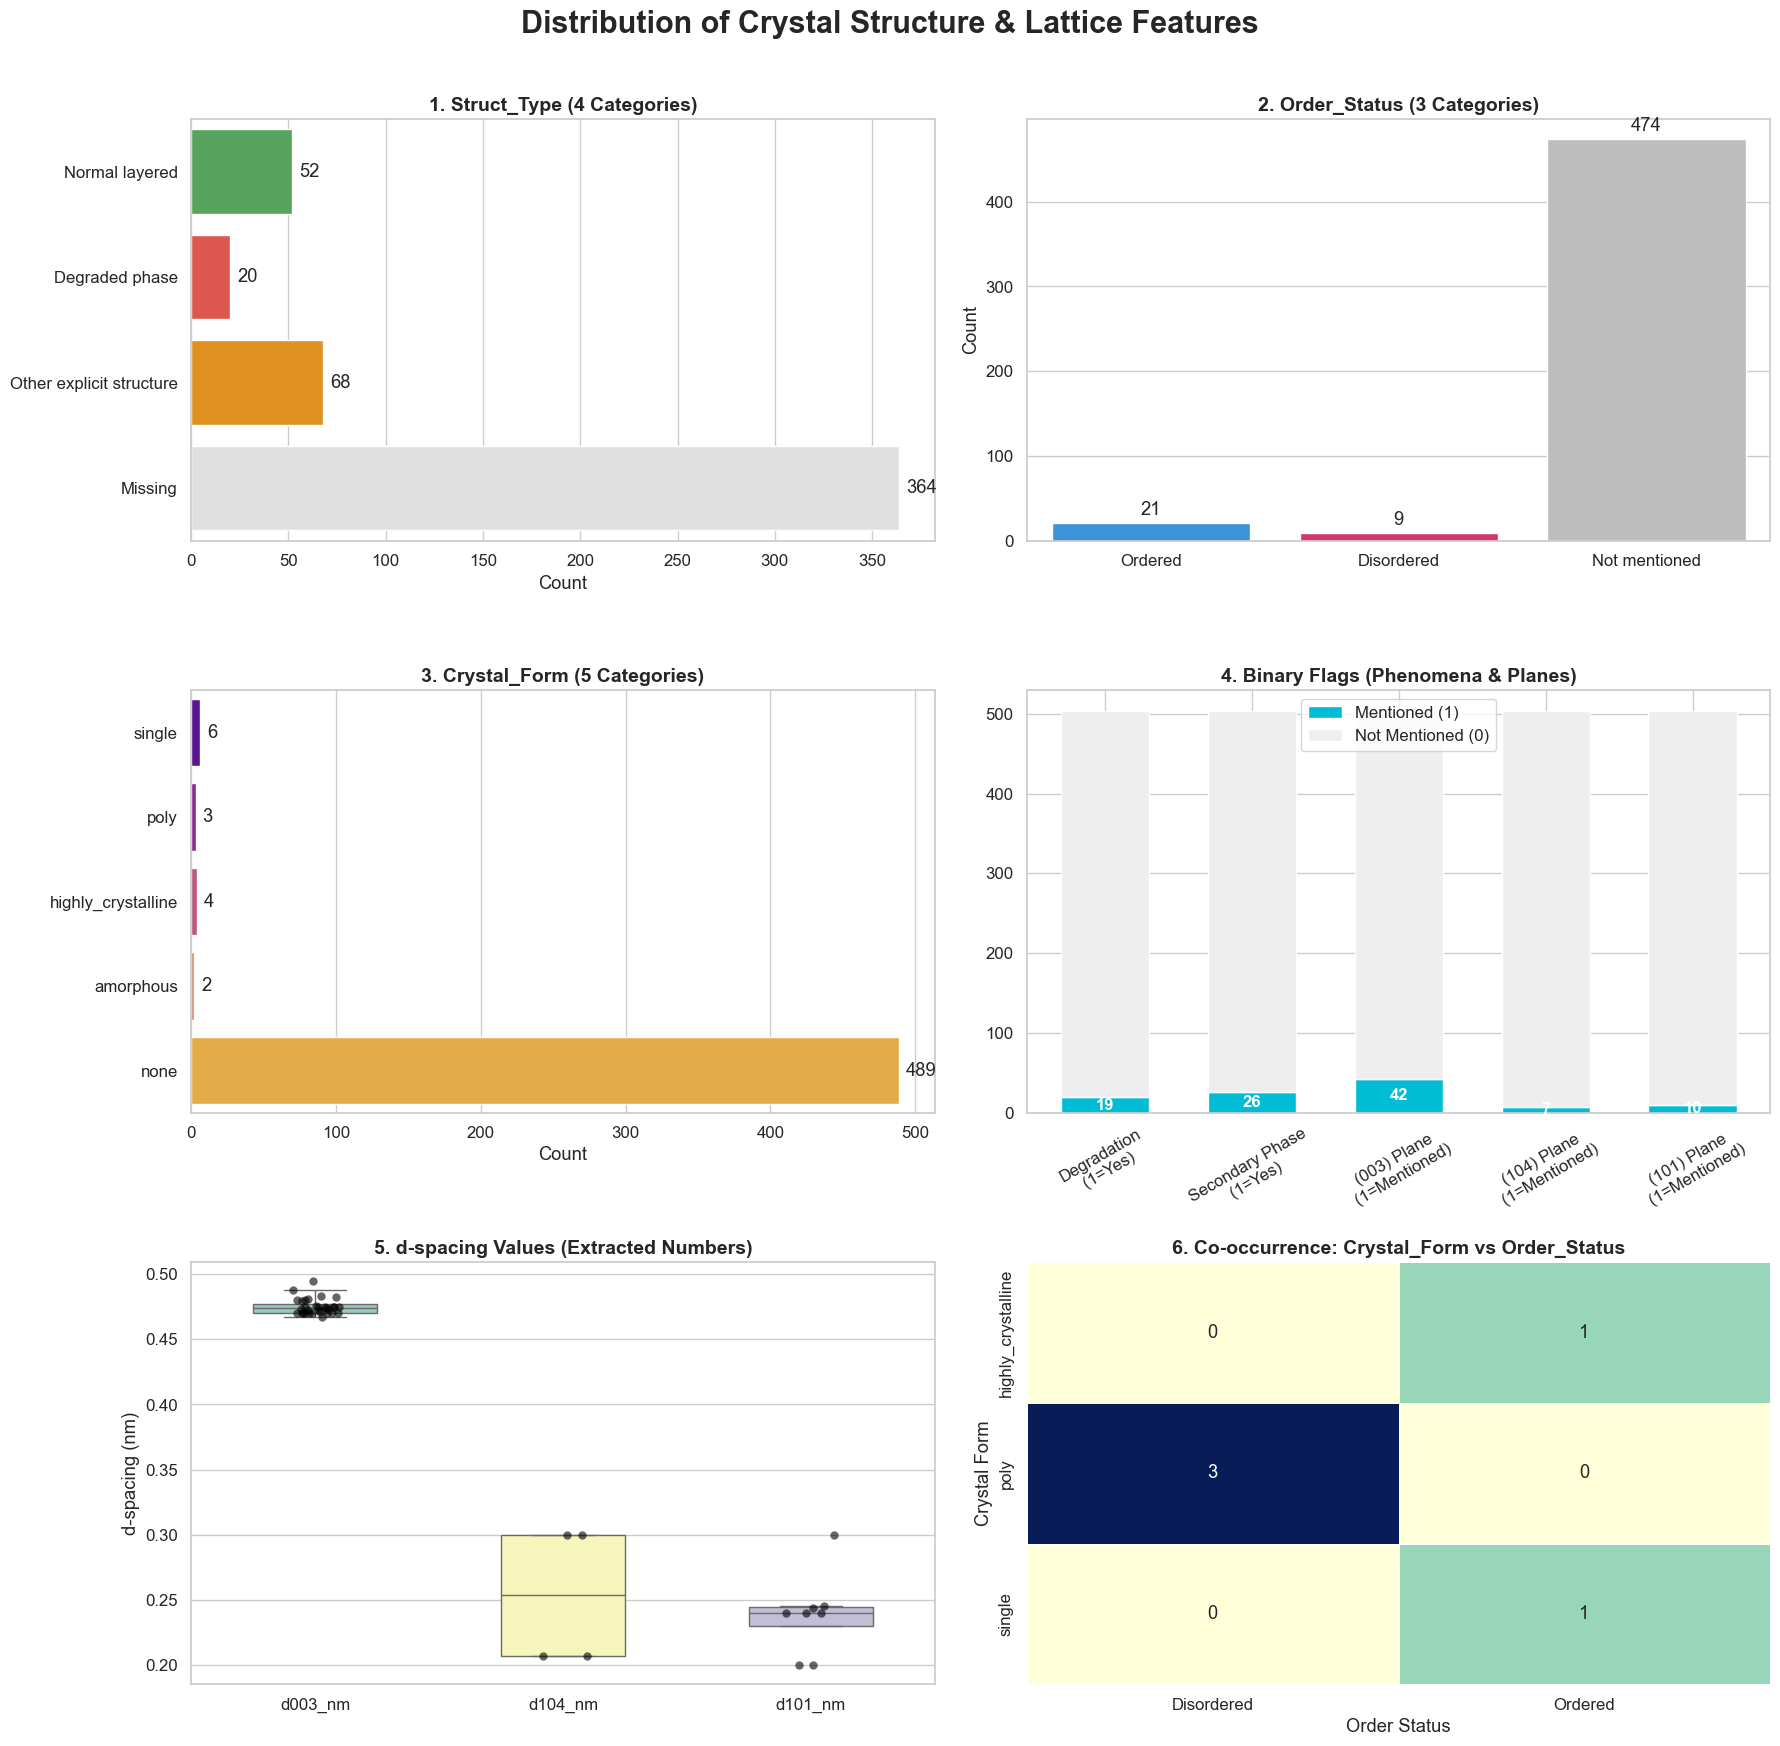

In [4]:
# ============================================================
# 📊 [최종] Crystal Structure & Lattice 모든 피처 분포 시각화
# ============================================================
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re

# ------------------------------------------------------------
# 1. 시각화용 데이터 최종 업데이트 (앞서 수정한 함수들 적용)
# ------------------------------------------------------------
# (주의: 이미 work 데이터프레임과 _text_clean 열이 있다고 가정합니다)

def parse_order_status(text):
    if text == "" or pd.isna(text): return "Not mentioned"
    
    ordered_patterns = [r"well-ordered", r"well ordered", r"highly ordered", r"high degree of ordering",
                        r"well-developed", r"well developed", r"ordered lattice", r"ordered layer", 
                        r"well-maintained", r"neatly arranged", r"clear lattice", r"distinct lattice",
                        r"low cation mixing"]
    is_ordered = any(re.search(p, text) for p in ordered_patterns)
    
    disordered_patterns = [r"disordered", r"highly disordered", r"severe disorder", r"suffered severe disorder",
                           r"confused and have different orientations", r"outer layers are confused",
                           r"defect", r"stacking fault", r"lattice distortion", r"structural defect",
                           r"cation mixing", r"li/ni mixing"]
    is_disordered = any(re.search(p, text) for p in disordered_patterns)
    
    # Mixed는 Disordered로 흡수
    if is_disordered: return "Disordered"
    elif is_ordered: return "Ordered"
    else: return "Not mentioned"

# 새로 정의한 3분할 Order_Status 적용
work["Order_Status"] = work["_text_clean"].apply(parse_order_status)


# ------------------------------------------------------------
# 2. 대시보드 시각화 세팅 (3행 2열 레이아웃)
# ------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Distribution of Crystal Structure & Lattice Features', fontsize=22, fontweight='bold', y=0.97)

# ─── 1. Struct_Type (4분할) ───
ax1 = axes[0, 0]
struct_order = ["Normal layered", "Degraded phase", "Other explicit structure", "Missing"]
sns.countplot(data=work, y="Struct_Type", order=struct_order, 
              palette=['#4CAF50', '#F44336', '#FF9800', '#E0E0E0'], ax=ax1)
ax1.set_title("1. Struct_Type (4 Categories)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Count"); ax1.set_ylabel("")
for container in ax1.containers: ax1.bar_label(container, padding=5)

# ─── 2. Order_Status (3분할) ───
ax2 = axes[0, 1]
order_cats = ["Ordered", "Disordered", "Not mentioned"]
sns.countplot(data=work, x="Order_Status", order=order_cats, 
              palette=['#2196F3', '#E91E63', '#BDBDBD'], ax=ax2)
ax2.set_title("2. Order_Status (3 Categories)", fontsize=14, fontweight='bold')
ax2.set_xlabel(""); ax2.set_ylabel("Count")
for container in ax2.containers: ax2.bar_label(container, padding=3)

# ─── 3. Crystal_Form (5분할) ───
ax3 = axes[1, 0]
crystal_order = ["single", "poly", "highly_crystalline", "amorphous", "none"]
sns.countplot(data=work, y="Crystal_Form", order=crystal_order, 
              palette='plasma', ax=ax3)
ax3.set_title("3. Crystal_Form (5 Categories)", fontsize=14, fontweight='bold')
ax3.set_xlabel("Count"); ax3.set_ylabel("")
for container in ax3.containers: ax3.bar_label(container, padding=5)

# ─── 4. Binary Flags (현상 & 결정면 언급 여부) ───
ax4 = axes[1, 1]
binary_flags = ['Degradation_Phase', 'Secondary_Phase_Present', 'Plane_003', 'Plane_104', 'Plane_101']
flag_labels = ['Degradation\n(1=Yes)', 'Secondary Phase\n(1=Yes)', '(003) Plane\n(1=Mentioned)', 
               '(104) Plane\n(1=Mentioned)', '(101) Plane\n(1=Mentioned)']

# 언급됨(1)과 안됨(0) 개수 계산
mentions = [work[flag].sum() for flag in binary_flags]
non_mentions = [len(work) - m for m in mentions]

ax4.bar(flag_labels, mentions, label='Mentioned (1)', color='#00BCD4', edgecolor='white', width=0.6)
ax4.bar(flag_labels, non_mentions, bottom=mentions, label='Not Mentioned (0)', color='#EEEEEE', edgecolor='white', width=0.6)
ax4.set_title("4. Binary Flags (Phenomena & Planes)", fontsize=14, fontweight='bold')
ax4.tick_params(axis='x', rotation=30)
ax4.legend()

for i, m in enumerate(mentions):
    if m > 0: ax4.text(i, m/2, str(int(m)), ha='center', va='center', fontweight='bold', color='white', fontsize=12)

# ─── 5. d-spacing 수치형 분포 (Box + Strip) ───
ax5 = axes[2, 0]
melted_d = work[['d003_nm', 'd104_nm', 'd101_nm']].melt(var_name='Plane', value_name='d-spacing (nm)').dropna()

sns.boxplot(data=melted_d, x='Plane', y='d-spacing (nm)', palette='Set3', ax=ax5, showfliers=False, width=0.5)
sns.stripplot(data=melted_d, x='Plane', y='d-spacing (nm)', color='black', alpha=0.6, jitter=True, size=6, ax=ax5)
ax5.set_title("5. d-spacing Values (Extracted Numbers)", fontsize=14, fontweight='bold')
ax5.set_xlabel(""); ax5.set_ylabel("d-spacing (nm)")

# ─── 6. 상관관계 히트맵 (Ordered/Disordered vs Crystal_Form) ───
ax6 = axes[2, 1]
# 결측치를 제외한 유의미한 데이터 간의 패턴 확인
cross_tab = pd.crosstab(work[work['Crystal_Form'] != 'none']['Crystal_Form'], 
                        work[work['Order_Status'] != 'Not mentioned']['Order_Status'])

if not cross_tab.empty:
    sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', cbar=False, linewidths=0.5, ax=ax6)
    ax6.set_title("6. Co-occurrence: Crystal_Form vs Order_Status", fontsize=14, fontweight='bold')
    ax6.set_xlabel("Order Status"); ax6.set_ylabel("Crystal Form")
else:
    ax6.text(0.5, 0.5, "Not enough overlapping data", ha='center', va='center', fontsize=12)
    ax6.set_title("6. Co-occurrence: Crystal_Form vs Order_Status", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()